# 라이브러리 및 데이터 불러오기

In [72]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

from statsmodels.stats.proportion import proportions_ztest

In [73]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [74]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.mart_user_activation`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

df.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,signup_at,group_id,school_id,questionset_count,first_questionset_at,last_questionset_at,vote_count,first_vote_at,last_vote_at,selected_count,read_selected_count,first_selected_at,payment_count,first_payment_at,last_payment_at
0,846094,2023-04-25 14:42:40.623375+00:00,2975,4293,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,2,2023-05-27 13:46:54+00:00,2023-05-27 13:47:12+00:00
1,846284,2023-04-25 16:15:28.800483+00:00,3041,5214,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT
2,853037,2023-04-29 12:28:57.391907+00:00,4966,5603,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT
3,880440,2023-05-04 11:06:40.404252+00:00,3365,5300,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT
4,880789,2023-05-04 12:24:33.963954+00:00,11289,5285,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT


## 데이터 확인

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   user_id               677080 non-null  Int64              
 1   signup_at             677080 non-null  datetime64[us, UTC]
 2   group_id              677080 non-null  Int64              
 3   school_id             677080 non-null  Int64              
 4   questionset_count     4972 non-null    Int64              
 5   first_questionset_at  4972 non-null    datetime64[us, UTC]
 6   last_questionset_at   4972 non-null    datetime64[us, UTC]
 7   vote_count            4849 non-null    Int64              
 8   first_vote_at         4849 non-null    datetime64[us, UTC]
 9   last_vote_at          4849 non-null    datetime64[us, UTC]
 10  selected_count        15426 non-null   Int64              
 11  read_selected_count   15426 non-null   Int64              
 12 

## 결측 처리
- 날짜 데이터를 제외한 결측은 0으로 대체

In [76]:
count_cols = [
    'questionset_count',
    'vote_count',
    'selected_count',
    'read_selected_count',
    'payment_count'
]

df[count_cols] = df[count_cols].fillna(0)

In [77]:
# 결측 대체 적용 체크

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   user_id               677080 non-null  Int64              
 1   signup_at             677080 non-null  datetime64[us, UTC]
 2   group_id              677080 non-null  Int64              
 3   school_id             677080 non-null  Int64              
 4   questionset_count     677080 non-null  Int64              
 5   first_questionset_at  4972 non-null    datetime64[us, UTC]
 6   last_questionset_at   4972 non-null    datetime64[us, UTC]
 7   vote_count            677080 non-null  Int64              
 8   first_vote_at         4849 non-null    datetime64[us, UTC]
 9   last_vote_at          4849 non-null    datetime64[us, UTC]
 10  selected_count        677080 non-null  Int64              
 11  read_selected_count   677080 non-null  Int64              
 12 

# 질문 완료행동을 유지 행동으로 정의 하는 과정

## 질문 세트 데이터 불러오기

In [78]:
query = """
SELECT
    id AS questionset_id,
    user_id,
    question_piece_id_list,
    opening_time,
    status
FROM `sns-analysis-prj.sns_analysis.polls_questionset`
WHERE status = 'F'
"""

qs = client.query(query).to_dataframe()

print(qs.shape)
print(qs.head())

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(153411, 5)
   questionset_id  user_id                             question_piece_id_list  \
0          116704   838023  [1167328, 1167329, 1167330, 1167331, 1167332, ...   
1          132741   838023  [1327698, 1327699, 1327700, 1327701, 1327702, ...   
2          145316   838023  [1453448, 1453449, 1453450, 1453451, 1453452, ...   
3          257385   838023  [2574132, 2574133, 2574135, 2574137, 2574138, ...   
4          333471   838023  [3334998, 3334999, 3335000, 3335001, 3335002, ...   

               opening_time status  
0 2023-04-29 10:02:26+00:00      F  
1 2023-04-29 17:13:06+00:00      F  
2 2023-04-30 05:09:03+00:00      F  
3 2023-05-02 06:39:51+00:00      F  
4 2023-05-03 09:26:09+00:00      F  


## 투표 기록 불러오기

In [79]:
query = """
SELECT
    user_id,
    question_piece_id,
    created_at
FROM `sns-analysis-prj.sns_analysis.accounts_userquestionrecord`
"""

records = client.query(query).to_dataframe()

print(records.shape)
print(records.head())

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(1217558, 3)
   user_id  question_piece_id                created_at
0   851717            1213085 2023-04-29 13:22:05+00:00
1   849450            1235436 2023-04-29 14:49:06+00:00
2   850229            1395859 2023-04-30 03:29:48+00:00
3   857422            1509130 2023-04-30 07:43:10+00:00
4   855117            1511169 2023-04-30 07:58:36+00:00


In [80]:
# 원본 qs를 유지하기 위해 필요한 컬럼만 복사한다.
qs_pieces = qs[
    ["questionset_id", "user_id", "question_piece_id_list"]
].copy()

# 질문 조각 ID 목록을 실제 파이썬 리스트로 통일한다.
# 이미 리스트인 값은 그대로 사용하고, 문자열인 경우에만 변환한다.
def parse_piece_list(value):
    if isinstance(value, (list, tuple)):
        return list(value)
    if isinstance(value, str):
        return ast.literal_eval(value)
    return []

qs_pieces["question_piece_id"] = (
    qs_pieces["question_piece_id_list"].apply(parse_piece_list)
)

# 질문세트 한 행에 들어 있던 여러 질문 조각을 각각 한 행으로 펼친다.
qs_pieces = qs_pieces.explode("question_piece_id")

# 병합에 사용할 ID 컬럼의 자료형을 통일한다.
qs_pieces["question_piece_id"] = qs_pieces["question_piece_id"].astype("Int64")

# 펼친 뒤 질문세트 수와 질문 조각 수를 확인한다.
print("질문세트 수:", qs_pieces["questionset_id"].nunique())
print("질문 조각 행 수:", len(qs_pieces))
print(qs_pieces.head())

질문세트 수: 153411
질문 조각 행 수: 1534110
   questionset_id  user_id                             question_piece_id_list  \
0          116704   838023  [1167328, 1167329, 1167330, 1167331, 1167332, ...   
0          116704   838023  [1167328, 1167329, 1167330, 1167331, 1167332, ...   
0          116704   838023  [1167328, 1167329, 1167330, 1167331, 1167332, ...   
0          116704   838023  [1167328, 1167329, 1167330, 1167331, 1167332, ...   
0          116704   838023  [1167328, 1167329, 1167330, 1167331, 1167332, ...   

   question_piece_id  
0            1167328  
0            1167329  
0            1167330  
0            1167331  
0            1167332  


In [81]:
# 1. 질문세트에 속한 질문 조각과 실제 투표 기록을 연결한다.
# 스킵한 질문은 투표 기록이 없을 수 있으므로 left join을 사용한다.
qs_votes = qs_pieces[
    ["questionset_id", "user_id", "question_piece_id"]
].merge(
    records[["user_id", "question_piece_id", "created_at"]],
    on=["user_id", "question_piece_id"],
    how="left",
    validate="many_to_one"  # 유저+질문 조각별 투표 기록이 최대 1건인지 검증
)

# 2. 질문세트별로 첫 투표 시각과 마지막 투표 시각을 집계한다.
# 마지막 투표 시각을 '추정 완료 시각 후보'로 사용한다.
qs_times = (
    qs_votes
    .groupby("questionset_id", as_index=False)
    .agg(
        first_vote_at=("created_at", "min"),
        estimated_finished_at=("created_at", "max"),
        matched_vote_count=("created_at", "count")
    )
)

# 3. 투표 기록이 전혀 없는 완료 질문세트가 얼마나 되는지 확인한다.
print("완료 질문세트 수:", len(qs_times))
print("투표 기록이 없는 완료 세트:", (qs_times["matched_vote_count"] == 0).sum())
print("추정 완료 시각이 있는 세트:", qs_times["estimated_finished_at"].notna().sum())

# 4. 집계 결과 일부를 확인한다.
print(qs_times.head())

완료 질문세트 수: 153411
투표 기록이 없는 완료 세트: 1845
추정 완료 시각이 있는 세트: 151566
   questionset_id             first_vote_at     estimated_finished_at  \
0           99817 2023-04-28 12:27:49+00:00 2023-04-28 12:29:33+00:00   
1           99830 2023-04-28 12:29:29+00:00 2023-04-28 12:31:18+00:00   
2           99840 2023-04-28 12:28:46+00:00 2023-04-28 12:30:34+00:00   
3           99841 2023-04-28 12:35:18+00:00 2023-04-28 12:37:09+00:00   
4           99848 2023-04-28 12:32:13+00:00 2023-04-28 12:34:44+00:00   

   matched_vote_count  
0                  10  
1                   9  
2                  10  
3                   5  
4                   9  


In [82]:
# 기존 데이터마트 df는 수정하지 않고, 유저 ID 목록만 가져온다.
cohort_users = df[["user_id"]].drop_duplicates()

# 완료 질문세트에 추정 완료 시각을 연결한다.
# 투표 기록이 없는 세트도 남기기 위해 left join을 사용한다.
qs_finished = qs.merge(
    qs_times,
    on="questionset_id",
    how="left",
    validate="one_to_one"
)

# 분석 대상 5,090명에 해당하는 완료 질문세트만 남긴다.
qs_finished = qs_finished[
    qs_finished["user_id"].isin(cohort_users["user_id"])
].copy()

# 추정 완료 시각이 없는 세트의 규모와 해당 유저 수를 확인한다.
missing_time = qs_finished["estimated_finished_at"].isna()

print("데이터마트 유저 수:", cohort_users["user_id"].nunique())
print("대상 유저의 완료 질문세트 수:", len(qs_finished))
print("완료 경험 유저 수:", qs_finished["user_id"].nunique())
print("추정 완료 시각이 없는 세트 수:", missing_time.sum())
print(
    "추정 완료 시각이 없는 세트를 보유한 유저 수:",
    qs_finished.loc[missing_time, "user_id"].nunique()
)
print(
    "추정 완료 시각이 있는 유저 수:",
    qs_finished.loc[~missing_time, "user_id"].nunique()
)

데이터마트 유저 수: 677080
대상 유저의 완료 질문세트 수: 153411
완료 경험 유저 수: 4846
추정 완료 시각이 없는 세트 수: 1845
추정 완료 시각이 없는 세트를 보유한 유저 수: 728
추정 완료 시각이 있는 유저 수: 4812


### 질문세트 완료 시각 추정 — 데이터 준비 및 검증

**분석 목적**
- 10개 학교 유저 5,090명의 질문세트 완료 행동을 기준으로 일·주·월별 유지 패턴을 탐색한다.
- 유지 그룹의 구분 기준은 유지 패턴을 확인한 뒤 결정한다.
- 기존 데이터마트 `df`는 수정하지 않고 별도의 분석용 데이터프레임을 만든다.

**완료 행동 및 시각 정의**
- 완료 행동: `polls_questionset.status = 'F'`
- 추정 완료 시각(`estimated_finished_at`): 질문세트의 `question_piece_id_list`를 펼쳐 `user_id + question_piece_id`로 투표 기록과 연결한 뒤, 해당 세트의 마지막 `accounts_userquestionrecord.created_at`을 사용한다.
- `opening_time`은 완료 시각으로 사용하지 않는다.

**현재까지 확인한 결과**
- 완료 질문세트: **153,411건 / 완료 경험 유저: 4,846명**
- 질문 조각 전개: **1,534,110행** (세트당 10개)
- 추정 완료 시각이 있는 세트: **151,566건 (98.80%)**
- 추정 완료 시각이 없는 세트: **1,845건 (1.20%)**, 해당 유저 **728명**
- 추정 완료 시각이 있는 세트를 하나 이상 보유한 유저: **4,812명**
- 기존 데이터마트 `df`: **677,080명**. 분석 대상 5,090명과의 일치 여부는 추가 확인 필요.

**해석상 유의사항**
- 투표 기록이 없는 세트는 추정 완료 시각을 계산할 수 없다. 다만 모두 스킵 때문인지는 확인되지 않았다.
- 마지막 질문을 스킵했다면 마지막 투표 시각이 실제 완료 시각보다 이를 수 있다.
- 따라서 `estimated_finished_at`은 실제 시스템 완료 시각이 아닌 **마지막 투표 기록 기반 추정치**다.

**다음 단계**
1. 분석 대상 5,090명을 정확히 식별한다.
2. 추정 완료 시각을 기준으로 일·주·월별 유지 패턴과 이용 지속 기간을 탐색한다.
3. 탐색 결과를 바탕으로 유지 그룹의 구분 기준을 도출한다.

In [83]:
# 질문세트 유저와 데이터마트의 학교 정보를 연결한다.
# 질문세트가 여러 개인 유저는 중복되지 않도록 user_id만 추출한다.
qs_user_ids = qs[["user_id"]].drop_duplicates()

qs_user_schools = qs_user_ids.merge(
    df[["user_id", "school_id"]],
    on="user_id",
    how="left",
    validate="one_to_one"
)

# 학교 정보 연결 여부와 학교별 질문세트 유저 수를 확인한다.
print("질문세트 유저 수:", len(qs_user_ids))
print("학교 정보가 없는 유저 수:", qs_user_schools["school_id"].isna().sum())
print("확인된 학교 수:", qs_user_schools["school_id"].nunique())

print(
    qs_user_schools
    .groupby("school_id", dropna=False)["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

질문세트 유저 수: 4846
학교 정보가 없는 유저 수: 0
확인된 학교 수: 10
school_id
369     540
1719    539
5372    481
5520    479
4516    478
4426    469
271     468
352     465
5491    465
1478    462
Name: user_id, dtype: int64


In [84]:
# 1. 완료 질문세트 이용자가 속한 10개 학교 ID를 추출한다.
target_school_ids = qs_user_schools["school_id"].dropna().unique()

# 2. 기존 데이터마트 df는 수정하지 않고,
#    해당 10개 학교의 전체 유저를 새 데이터프레임으로 만든다.
cohort_df = df.loc[
    df["school_id"].isin(target_school_ids)
].copy()

# 3. 학교 수와 전체 유저 수를 확인한다.
print("대상 학교 수:", cohort_df["school_id"].nunique())
print("대상 유저 수:", cohort_df["user_id"].nunique())
print("데이터프레임 행 수:", len(cohort_df))

# 4. 완료 질문세트 이용자 4,846명이 모두 포함됐는지도 확인한다.
print(
    "코호트에서 누락된 완료 이용자 수:",
    (~qs_user_ids["user_id"].isin(cohort_df["user_id"])).sum()
)

대상 학교 수: 10
대상 유저 수: 5090
데이터프레임 행 수: 5090
코호트에서 누락된 완료 이용자 수: 0


In [85]:
# 1. 분석 대상 5,090명의 완료 질문세트만 가져온다.
#    기존 df, cohort_df, qs_finished는 변경하지 않는다.
retention_sets = qs_finished.loc[
    qs_finished["user_id"].isin(cohort_df["user_id"]),
    ["questionset_id", "user_id", "opening_time",
     "estimated_finished_at", "matched_vote_count"]
].copy()

# 2. 가입 시각을 연결한다.
retention_sets = retention_sets.merge(
    cohort_df[["user_id", "signup_at"]],
    on="user_id",
    how="left",
    validate="many_to_one"
)

# 3. 시간대가 달라서 잘못 비교되는 일이 없도록 UTC로 통일한다.
for col in ["opening_time", "estimated_finished_at", "signup_at"]:
    retention_sets[col] = pd.to_datetime(
        retention_sets[col], utc=True, errors="coerce"
    )

# 4. 추정 완료 시각이 있는 기록만 대상으로 시간 순서를 검사한다.
has_time = retention_sets["estimated_finished_at"].notna()

print("분석 대상 유저 수:", cohort_df["user_id"].nunique())
print("완료 질문세트 수:", len(retention_sets))
print("추정 완료 시각 없는 세트:", (~has_time).sum())
print(
    "오픈 시각보다 추정 완료 시각이 빠른 세트:",
    (
        has_time
        & retention_sets["opening_time"].notna()
        & (retention_sets["estimated_finished_at"] < retention_sets["opening_time"])
    ).sum()
)
print(
    "가입 시각보다 추정 완료 시각이 빠른 세트:",
    (
        has_time
        & retention_sets["signup_at"].notna()
        & (retention_sets["estimated_finished_at"] < retention_sets["signup_at"])
    ).sum()
)
print("오픈 시각 결측:", retention_sets["opening_time"].isna().sum())
print("가입 시각 결측:", retention_sets["signup_at"].isna().sum())

분석 대상 유저 수: 5090
완료 질문세트 수: 153411
추정 완료 시각 없는 세트: 1845
오픈 시각보다 추정 완료 시각이 빠른 세트: 0
가입 시각보다 추정 완료 시각이 빠른 세트: 0
오픈 시각 결측: 0
가입 시각 결측: 0


In [86]:
# 1. 추정 완료 시각이 있는 질문세트만 집계에 사용한다.
#    원본 retention_sets와 cohort_df는 변경하지 않는다.
valid_sets = retention_sets.loc[
    retention_sets["estimated_finished_at"].notna()
].copy()

# 2. 유저별 첫 완료 시각, 마지막 완료 시각, 완료 횟수를 계산한다.
user_completion = (
    valid_sets
    .groupby("user_id", as_index=False)
    .agg(
        first_finished_at=("estimated_finished_at", "min"),
        last_finished_at=("estimated_finished_at", "max"),
        timed_finished_count=("questionset_id", "nunique")
    )
)

# 3. 5,090명 전체를 기준으로 연결한다.
#    추정 완료 시각이 없는 유저도 분석 대상에서 빠지지 않도록 left join한다.
retention_users = cohort_df[["user_id", "signup_at", "school_id"]].merge(
    user_completion,
    on="user_id",
    how="left",
    validate="one_to_one"
)

# 4. 시각을 추정할 수 있는 완료 기록이 없는 유저는 횟수만 0으로 표시한다.
retention_users["timed_finished_count"] = (
    retention_users["timed_finished_count"].fillna(0).astype(int)
)

# 5. 유저별 최초~마지막 추정 완료 시각의 간격을 계산한다.
#    이 값은 활동 기간의 한 지표이지, 유지율 자체는 아니다.
retention_users["completion_span_days"] = (
    retention_users["last_finished_at"]
    - retention_users["first_finished_at"]
).dt.total_seconds() / 86400

# 6. 전체 인원과 집계 결과를 확인한다.
print("전체 분석 대상:", len(retention_users))
print("추정 완료 시각이 있는 유저:", retention_users["first_finished_at"].notna().sum())
print("추정 완료 시각이 없는 유저:", retention_users["first_finished_at"].isna().sum())

print(
    retention_users[
        ["timed_finished_count", "completion_span_days"]
    ].describe()
)

전체 분석 대상: 5090
추정 완료 시각이 있는 유저: 4812
추정 완료 시각이 없는 유저: 278
       timed_finished_count  completion_span_days
count           5090.000000           4812.000000
mean              29.777210             26.190780
std               26.971727             38.733835
min                0.000000              0.000000
25%               11.000000              7.055188
50%               23.000000             14.856279
75%               40.000000             27.111837
max              363.000000            368.951759


In [87]:
# 1. 추정 완료 시각이 있는 질문세트의 관측 시작·마지막 시각을 확인한다.
#    이 마지막 시각은 '데이터 수집 종료일'이 아니라
#    현재 확보한 완료 기록에서 관측된 마지막 시각이다.
print("최초 추정 완료 시각:", valid_sets["estimated_finished_at"].min())
print("마지막 추정 완료 시각:", valid_sets["estimated_finished_at"].max())

# 2. 유저별 첫 추정 완료일이 어느 달에 분포하는지 확인한다.
#    월별 인원이 매우 적은 구간은 이후 유지율 해석에 주의해야 한다.
first_finish_month = (
    retention_users.loc[
        retention_users["first_finished_at"].notna(),
        ["user_id", "first_finished_at"]
    ]
    .assign(
        first_month=lambda x: x["first_finished_at"]
        .dt.tz_convert("Asia/Seoul")
        .dt.to_period("M")
    )
    .groupby("first_month")["user_id"]
    .nunique()
)

print("\n첫 추정 완료 월별 유저 수:")
print(first_finish_month)

최초 추정 완료 시각: 2023-04-28 12:29:33+00:00
마지막 추정 완료 시각: 2024-05-07 11:29:07+00:00

첫 추정 완료 월별 유저 수:
first_month
2023-04     326
2023-05    4447
2023-06      32
2023-07       4
2023-09       1
2023-11       1
2024-03       1
Freq: M, Name: user_id, dtype: int64


C:\Users\kkw53\AppData\Local\Temp\ipykernel_2156\364641498.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


In [88]:
# 원본에 표시된 시계 숫자를 유지한 채 날짜만 추출한다.
# tz_convert를 하지 않으므로 9시간을 더하지 않는다.
daily_sets = valid_sets[
    ["user_id", "estimated_finished_at"]
].copy()

daily_sets["finish_date"] = (
    daily_sets["estimated_finished_at"]
    .dt.date
)

print(daily_sets.head())

# 2. 유저별 첫 완료일을 구한다.
first_dates = (
    daily_sets.groupby("user_id")["finish_date"]
    .min()
    .rename("first_finish_date")
)

daily_sets = daily_sets.join(first_dates, on="user_id")

# 3. 첫 완료일부터 며칠이 지났는지 계산한다.
#    첫 완료일 = D+0, 다음 달력 날짜 = D+1
daily_sets["day_offset"] = (
    pd.to_datetime(daily_sets["finish_date"])
    - pd.to_datetime(daily_sets["first_finish_date"])
).dt.days

# 4. 같은 날 여러 세트를 완료해도 유지 유저는 한 명으로 집계한다.
daily_active = daily_sets[
    ["user_id", "day_offset"]
].drop_duplicates()

# 5. D+0~D+30의 일별 재완료 유저 수를 집계한다.
daily_counts = (
    daily_active[
        daily_active["day_offset"].between(0, 30)
    ]
    .groupby("day_offset")["user_id"]
    .nunique()
    .reindex(range(31), fill_value=0)
)

# 6. 우선 첫 완료 경험 유저 4,812명을 공통 분모로 사용한다.
#    관측 종료일이 확정되면 기간별 관측 가능 유저 기준으로 보정할 예정이다.
base_users = first_dates.index.nunique()

daily_retention = pd.DataFrame({
    "day": range(31),
    "retained_users": daily_counts.values
})

daily_retention["base_users"] = base_users
daily_retention["retention_rate"] = (
    daily_retention["retained_users"]
    / daily_retention["base_users"] * 100
).round(2)

print("첫 완료 경험 유저 수:", base_users)
display(daily_retention)

   user_id     estimated_finished_at finish_date
0   838023 2023-04-29 16:22:56+00:00  2023-04-29
1   838023 2023-04-30 04:18:56+00:00  2023-04-30
2   838023 2023-05-02 05:49:35+00:00  2023-05-02
3   838023 2023-05-03 08:36:09+00:00  2023-05-03
4   838023 2023-05-03 12:23:17+00:00  2023-05-03
첫 완료 경험 유저 수: 4812


,day,retained_users,base_users,retention_rate
0,0,4812,4812,100.00
1,1,4355,4812,90.50
2,2,4092,4812,85.04
3,3,3795,4812,78.87
4,4,3366,4812,69.95
5,5,3041,4812,63.20
6,6,2699,4812,56.09
7,7,2369,4812,49.23
8,8,2060,4812,42.81
9,9,1765,4812,36.68


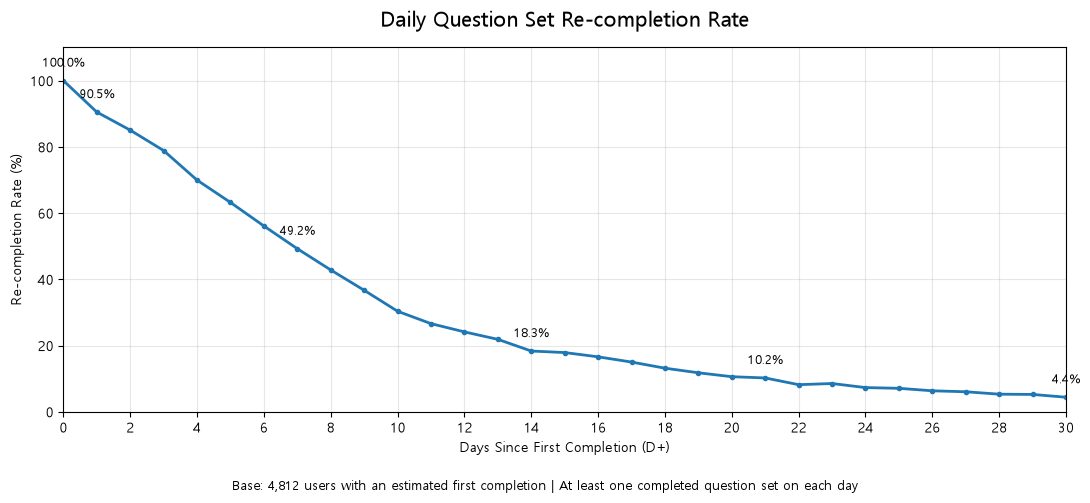

In [89]:
# 발표용 일별 재완료율 라인차트
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    daily_retention["day"],
    daily_retention["retention_rate"],
    marker="o",
    markersize=3,
    linewidth=2
)

# 주요 날짜에 수치 표시
highlight_days = [0, 1, 7, 14, 21, 30]

for day in highlight_days:
    rate = daily_retention.loc[
        daily_retention["day"] == day, "retention_rate"
    ].iloc[0]

    ax.annotate(
        f"{rate:.1f}%",
        xy=(day, rate),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# 차트 제목 및 축 설정
ax.set_title("Daily Question Set Re-completion Rate", fontsize=15, pad=15)
ax.set_xlabel("Days Since First Completion (D+)")
ax.set_ylabel("Re-completion Rate (%)")

ax.set_xlim(0, 30)
ax.set_ylim(0, 110)
ax.set_xticks(range(0, 31, 2))
ax.grid(alpha=0.3)

# 발표 시 지표 정의를 알 수 있도록 하단에 설명 추가
fig.text(
    0.5, 0.01,
    "Base: 4,812 users with an estimated first completion | "
    "At least one completed question set on each day",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

“첫 질문세트 완료일을 D+0으로 설정하고, 이후 각 날짜에 질문세트를 다시 완료한 유저의 비율을 확인했습니다. D+1은 90.5%, D+7은 49.2%, D+14는 18.3%로 나타나 첫 2주 동안 일별 재완료율이 크게 낮아지는 패턴을 관찰했습니다.”

In [90]:
# 첫 완료일 기준 7일씩 묶는다.
# 같은 주에 여러 번 완료해도 유저는 한 번만 센다.
weekly_active = daily_active.copy()
weekly_active["week_offset"] = weekly_active["day_offset"] // 7

weekly_counts = (
    weekly_active[weekly_active["week_offset"].between(0, 4)]
    .groupby("week_offset")["user_id"]
    .nunique()
    .reindex(range(5), fill_value=0)
)

weekly_retention = pd.DataFrame({
    "week": range(5),
    "retained_users": weekly_counts.values,
    "base_users": base_users
})

weekly_retention["retention_rate"] = (
    weekly_retention["retained_users"]
    / weekly_retention["base_users"] * 100
).round(2)

display(weekly_retention)

,week,retained_users,base_users,retention_rate
0,0,4812,4812,100.00
1,1,3447,4812,71.63
2,2,2052,4812,42.64
3,3,1242,4812,25.81
4,4,704,4812,14.63


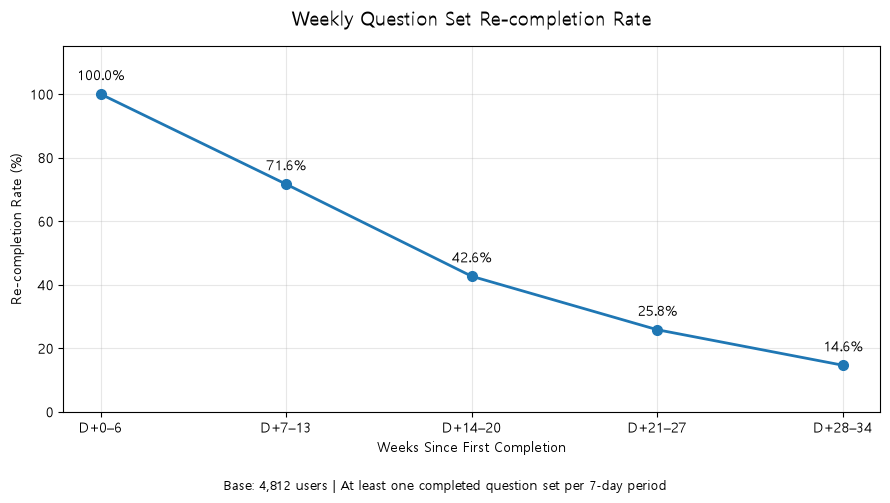

In [91]:
# 주차별 재완료율 라인차트
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    weekly_retention["week"],
    weekly_retention["retention_rate"],
    marker="o",
    markersize=7,
    linewidth=2
)

# 각 주차의 재완료율 표시
for _, row in weekly_retention.iterrows():
    ax.annotate(
        f'{row["retention_rate"]:.1f}%',
        xy=(row["week"], row["retention_rate"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

ax.set_title("Weekly Question Set Re-completion Rate", fontsize=14, pad=15)
ax.set_xlabel("Weeks Since First Completion")
ax.set_ylabel("Re-completion Rate (%)")

ax.set_xticks(range(5))
ax.set_xticklabels(["D+0–6", "D+7–13", "D+14–20", "D+21–27", "D+28–34"])
ax.set_ylim(0, 115)
ax.grid(alpha=0.3)

fig.text(
    0.5, 0.01,
    "Base: 4,812 users | At least one completed question set per 7-day period",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("weekly_retention.png", dpi=300, bbox_inches="tight")
plt.show()

첫 질문세트 완료 경험이 있는 4,812명을 대상으로 분석한 결과, 해당 주에 질문세트를 한 번 이상 다시 완료한 비율은 1주 차(D+7~13) 71.63%, 2주 차(D+14~20) 42.64%, 3주 차(D+21~27) 25.81%로 낮아졌다. 이는 첫 완료 이후 초기 몇 주 동안 재완료 활동이 감소하는 패턴을 보여준다.

In [92]:
# 1. 첫 완료일로부터 30일 단위로 구간을 나눈다.
monthly_active = daily_active.copy()
monthly_active["month_offset"] = monthly_active["day_offset"] // 30

# 2. 같은 30일 구간에 여러 번 완료해도 유저는 한 명으로 집계한다.
monthly_counts = (
    monthly_active[monthly_active["month_offset"].between(0, 3)]
    .groupby("month_offset")["user_id"]
    .nunique()
    .reindex(range(4), fill_value=0)
)

# 3. 첫 완료 경험이 있는 4,812명을 분모로 재완료율을 계산한다.
monthly_retention = pd.DataFrame({
    "month": range(4),
    "retained_users": monthly_counts.values,
    "base_users": base_users
})

monthly_retention["retention_rate"] = (
    monthly_retention["retained_users"]
    / monthly_retention["base_users"] * 100
).round(2)

# 4. 발표 자료에서 구간을 바로 알아볼 수 있도록 이름을 붙인다.
monthly_retention["period"] = [
    "D+0~29",
    "D+30~59",
    "D+60~89",
    "D+90~119"
]

display(
    monthly_retention[
        ["period", "retained_users", "base_users", "retention_rate"]
    ]
)

,period,retained_users,base_users,retention_rate
0,D+0~29,4812,4812,100.00
1,D+30~59,771,4812,16.02
2,D+60~89,316,4812,6.57
3,D+90~119,98,4812,2.04


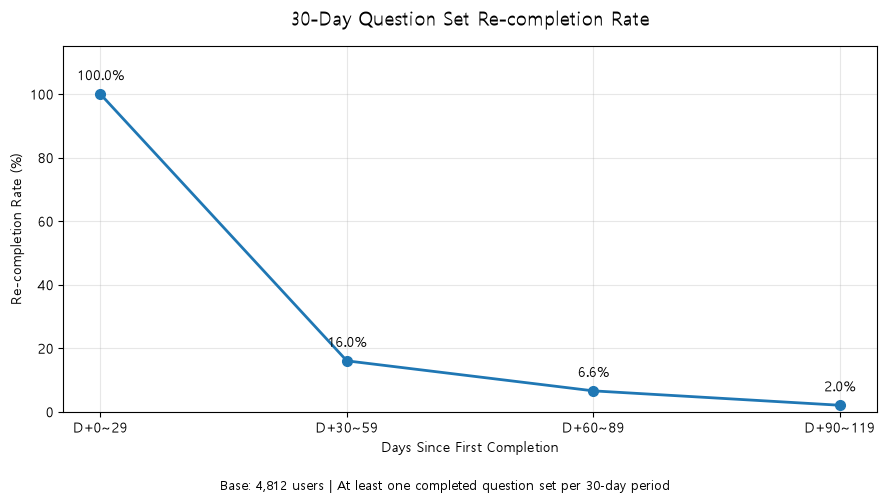

In [93]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    monthly_retention["period"],
    monthly_retention["retention_rate"],
    marker="o",
    markersize=7,
    linewidth=2
)

# 각 구간의 재완료율 표시
for _, row in monthly_retention.iterrows():
    ax.annotate(
        f'{row["retention_rate"]:.1f}%',
        xy=(row["period"], row["retention_rate"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

ax.set_title("30-Day Question Set Re-completion Rate", fontsize=14, pad=15)
ax.set_xlabel("Days Since First Completion")
ax.set_ylabel("Re-completion Rate (%)")
ax.set_ylim(0, 115)
ax.grid(alpha=0.3)

fig.text(
    0.5, 0.01,
    "Base: 4,812 users | At least one completed question set per 30-day period",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("monthly_retention.png", dpi=300, bbox_inches="tight")
plt.show()


# 질문세트 완료 기반 유지 패턴 탐색

## 1. 분석 목적

첫 질문세트 완료 이후 유저가 얼마나 자주 다시 질문세트를 완료하는지 일별·주차별·30일 단위로 확인한다. 재완료 활동이 감소하는 구간을 파악한 뒤, 후속 분석에서 유저의 이용 패턴에 따른 그룹 구분 기준을 검토한다.

## 2. 분석 대상 및 지표 정의

- **전체 분석 대상:** 10개 학교 소속 유저 5,090명
- **질문세트 완료 기준:** `polls_questionset.status = 'F'`
- **완료 시각:** 질문세트에 포함된 질문 조각과 연결되는 투표 기록 중 **마지막으로 관측된 `created_at`**으로 추정
- **분석 기준일(D+0):** 유저별 첫 *추정 완료일*
- **날짜 기준:** 원본에 표시된 시계 숫자를 유지한 달력 날짜 기준. 별도의 한국 시간 변환은 하지 않음.
- **재완료율:** 첫 완료 경험이 있는 유저 중 해당 날짜 또는 기간에 질문세트를 **1개 이상 다시 완료한 유저의 비율**. 동일 기간에 여러 번 완료해도 유저는 한 명으로 집계.

> **지표 해석:** 특정 날짜나 기간에 완료 기록이 없다는 사실은 영구 이탈을 의미하지 않는다. 이후 다시 완료한 유저가 있을 수 있다.

## 3. 데이터 준비 및 검증

| 검증 항목 | 결과 |
|---|---:|
| 전체 분석 대상 유저 | 5,090명 |
| 완료 상태(`F`) 질문세트 | 153,411건 |
| 추정 완료 시각이 있는 질문세트 | 151,566건 |
| 추정 완료 시각이 없는 질문세트 | 1,845건 |
| 추정 완료 시각이 있는 유저 | 4,812명 |
| 추정 완료 시각이 없는 유저 | 278명 |
| 추정 완료 시각이 오픈 시각보다 빠른 사례 | 0건 |
| 추정 완료 시각이 가입 시각보다 빠른 사례 | 0건 |
| 오픈 시각·가입 시각 결측 | 각 0건 |

**분석 분모는 추정 완료 시각이 있는 4,812명**으로 설정했다. 나머지 278명에는 완료 상태 기록 자체가 없는 유저뿐 아니라, 완료 상태 기록은 있어도 투표 기록을 연결하지 못해 완료 시각을 추정할 수 없는 유저가 포함될 수 있다.

마지막 관측 투표 시각은 실제 질문세트 완료 시각과 다를 수 있다. 예를 들어 마지막 질문을 스킵했고 해당 스킵의 시각 기록이 없다면, 실제 완료보다 앞선 시각으로 추정될 수 있다. 시간 순서 검증을 통과했더라도 추정 시각의 정확성이 입증된 것은 아니다.

## 4. 유저별 완료 활동 분포

추정 완료 시각이 있는 **4,812명**의 첫 완료~마지막 완료 시각 간격은 다음과 같다.

| 지표 | 기간 |
|---|---:|
| 25% 지점 | 약 7.1일 |
| 중앙값 | 약 14.9일 |
| 75% 지점 | 약 27.1일 |
| 평균 | 약 26.2일 |

이 값은 **첫 완료와 마지막 완료 사이의 간격**이다. 그사이 얼마나 자주 이용했는지 또는 정확히 언제 이탈했는지를 나타내지는 않는다. 따라서 중앙값인 약 15일을 곧바로 유지·이탈 그룹의 경계로 사용하지 않는다.

## 5. 일별 재완료율

첫 완료일을 D+0으로 설정하고, 이후 **각 달력 날짜에 질문세트를 1개 이상 완료한 유저 비율**을 계산했다.

| 경과일 | 재완료 유저 | 재완료율 |
|---|---:|---:|
| D+0 | 4,812명 | 100.00% |
| D+1 | 4,355명 | 90.50% |
| D+7 | 2,369명 | 49.23% |
| D+14 | 882명 | 18.33% |
| D+21 | 491명 | 10.20% |
| D+30 | 211명 | 4.38% |

**관찰 결과:** D+1에서 D+7까지 41.27%p, D+7에서 D+14까지 30.90%p 낮아졌다. 첫 완료 이후 초기 2주 동안 일별 재완료 활동이 빠르게 감소하는 패턴이 나타났다.

※ D+30의 4.38%는 **30일째 당일**에 다시 완료한 비율이며, 첫 30일 동안 한 번이라도 돌아온 유저의 비율이 아니다.

## 6. 주차별 재완료율

첫 완료일을 기준으로 7일씩 묶고, **해당 주차에 하루라도 질문세트를 완료한 유저 비율**을 계산했다.

| 주차 | 기간 | 재완료 유저 | 재완료율 |
|---|---|---:|---:|
| 0주 차 | D+0~6 | 4,812명 | 100.00% |
| 1주 차 | D+7~13 | 3,447명 | 71.63% |
| 2주 차 | D+14~20 | 2,052명 | 42.64% |
| 3주 차 | D+21~27 | 1,242명 | 25.81% |
| 4주 차 | D+28~34 | 704명 | 14.63% |

**관찰 결과:** 1주 차에서 2주 차로 넘어가며 재완료율이 **28.99%p** 낮아졌다. 일별 지표보다 주차별 지표가 높은 것은 하루를 놓쳤더라도 같은 주의 다른 날에 완료한 유저를 포함하기 때문이다.

0주 차는 첫 완료가 포함되어 정의상 100%이다.

## 7. 30일 단위 재완료율

달력상 월이 아니라, **유저별 첫 완료일로부터 30일씩 구분**했다.

| 기간 | 재완료 유저 | 재완료율 |
|---|---:|---:|
| D+0~29 | 4,812명 | 100.00% |
| D+30~59 | 771명 | 16.02% |
| D+60~89 | 316명 | 6.57% |
| D+90~119 | 98명 | 2.04% |

**관찰 결과:** 첫 완료 후 30~59일 구간에 다시 질문세트를 완료한 유저는 **16.02%**, 60~89일 구간에는 **6.57%**였다. 장기 구간에서도 재완료 활동이 감소하는 패턴을 확인했다.

※ 30~59일 구간에 완료하지 않았더라도 이후 기간에 돌아온 유저가 있을 수 있으므로, **‘첫 달에 84%가 이탈했다’고 해석하지 않는다.**

## 8. 종합 해석 및 다음 분석

**현재 확인한 사실**

- 일별·주차별·30일 단위 지표 모두 첫 완료 이후 재완료 활동이 감소하는 패턴을 보였다.
- 특히 **첫 완료 이후 초기 몇 주**에서 감소 폭이 크게 관찰됐다.
- 첫 완료~마지막 완료 간격만으로는 꾸준히 이용한 유저와 간헐적으로 돌아온 유저를 구분하기 어렵다.

**아직 결론 내리지 않은 사항**

- 특정 시점을 ‘이탈 확정일’로 규정하지 않는다.
- 7일 또는 14일을 고·저유지 그룹의 경계로 미리 확정하지 않는다.
- 초기 질문 경험이나 친구 관계가 재완료율 감소의 **원인**이라고 단정하지 않는다.

**다음 분석:** 유저별 **첫 14일 동안 질문세트를 완료한 서로 다른 날짜 수**를 확인한다. 이후 완료 빈도와 재완료 기간을 함께 살펴보고, 관측된 분포에 근거해 그룹 구분 기준을 검토한다.

---

### 분석 범위 및 한계

- **대상:** 10개 학교의 5,090명으로, 전체 서비스 유저를 대표하는 무작위 표본은 아니다.
- **완료 시각:** 실제 완료 이벤트 시각이 아닌 마지막 관측 투표 시각을 사용한 추정치다.
- **시간대:** 원본에 표시된 시계 숫자를 유지했으며, 원본 시간대의 정확한 의미는 확정하지 않았다.
- **관측 기간:** 전체 데이터는 대략 2023년 4월~2024년 5월에 걸쳐 있다. 위 비율은 첫 완료 시각을 추정할 수 있는 4,812명을 공통 분모로 계산했다. 기간별 관측 가능 여부는 전체 데이터의 종료 시점과 유저별 첫 완료일을 기준으로 최종 확인하는 것이 정확하다.


# 14일간 얼마나 꾸준히 질문세트를 완료 했는가?

In [94]:
# 1. 첫 완료일을 포함한 14일(D+0~13)의 기록만 선택한다.
first_14_days = daily_sets.loc[
    daily_sets["day_offset"].between(0, 13),
    ["user_id", "finish_date", "day_offset"]
].copy()

# 2. 유저별로 질문세트를 완료한 '서로 다른 날짜 수'를 계산한다.
#    같은 날짜에 여러 세트를 완료해도 활동일은 1일로 센다.
active_days_14 = (
    first_14_days
    .groupby("user_id")["finish_date"]
    .nunique()
    .rename("active_days_14")
    .reset_index()
)

# 3. 첫 완료 시각이 있는 유저 4,812명을 기준으로 연결한다.
#    첫 완료일(D+0)이 포함되므로 활동일 수의 최솟값은 1일이다.
user_activity_14 = (
    retention_users.loc[
        retention_users["first_finished_at"].notna(),
        ["user_id"]
    ]
    .merge(active_days_14, on="user_id", how="left", validate="one_to_one")
)

# 4. 활동일 수의 요약 통계와 상세 분포를 확인한다.
print("분석 유저 수:", len(user_activity_14))
print("\n첫 14일 활동일 수 요약:")
print(user_activity_14["active_days_14"].describe())

print("\n활동일 수별 유저 수:")
display(
    user_activity_14["active_days_14"]
    .value_counts()
    .sort_index()
    .rename_axis("active_days_14")
    .reset_index(name="users")
)

분석 유저 수: 4812

첫 14일 활동일 수 요약:
count    4812.000000
mean        7.752702
std         3.431781
min         1.000000
25%         5.000000
50%         8.000000
75%        10.000000
max        14.000000
Name: active_days_14, dtype: float64

활동일 수별 유저 수:


,active_days_14,users
0,1,151
1,2,193
2,3,243
3,4,342
4,5,416
5,6,468
6,7,485
7,8,471
8,9,452
9,10,455


- active_days_14 = 1, users = 151 → 첫 완료일(D+0)부터 D+13까지 단 하루에만 질문세트를 완료한 유저가 151명



- active_days_14 = 7, users = 485 → 그 14일 중 서로 다른 7일에 질문세트를 완료한 유저가 485명



- active_days_14 = 14, users = 232 → 14일 모두 질문세트를 완료한 유저가 232명

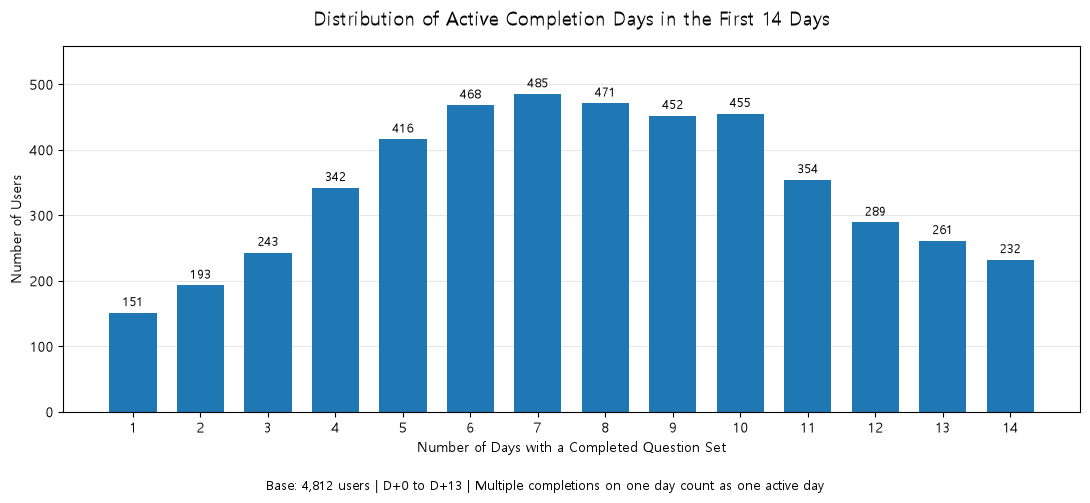

In [95]:
# 1. 첫 14일 중 활동일 수별 고유 유저 수 집계
activity_dist = (
    user_activity_14["active_days_14"]
    .value_counts()
    .sort_index()
    .reindex(range(1, 15), fill_value=0)
)

# 2. 막대그래프 생성
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(
    activity_dist.index,
    activity_dist.values,
    width=0.7
)

# 3. 각 막대 위에 유저 수 표시
ax.bar_label(bars, padding=3, fontsize=9)

# 4. 제목 및 축 설정
ax.set_title(
    "Distribution of Active Completion Days in the First 14 Days",
    fontsize=14,
    pad=15
)
ax.set_xlabel("Number of Days with a Completed Question Set")
ax.set_ylabel("Number of Users")

ax.set_xticks(range(1, 15))
ax.set_ylim(0, activity_dist.max() * 1.15)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# 5. 분석 대상 및 지표 정의 표시
fig.text(
    0.5, 0.01,
    "Base: 4,812 users | D+0 to D+13 | Multiple completions on one day count as one active day",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("active_days_14_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

“첫 14일 동안 질문세트를 완료한 날짜 수는 1~14일에 걸쳐 분포했으며, 6~10일 구간에 상대적으로 많은 유저가 관찰됐습니다. 14일 모두 완료한 유저는 232명(약 4.8%)이었습니다.”

In [96]:
# 1. D+14~27에 질문세트를 한 번 이상 완료한 유저를 찾는다.
#    같은 기간에 여러 번 완료해도 유저는 한 명으로 집계한다.
returned_14_27 = (
    daily_active.loc[
        daily_active["day_offset"].between(14, 27),
        ["user_id"]
    ]
    .drop_duplicates()
    .assign(returned_14_27=1)
)

# 2. 기존 첫 14일 활동일 수 데이터에 이후 재완료 여부를 연결한다.
#    연결되지 않은 유저는 해당 기간에 완료 기록이 없는 것으로 표시한다.
activity_vs_return = user_activity_14.merge(
    returned_14_27,
    on="user_id",
    how="left",
    validate="one_to_one"
)

activity_vs_return["returned_14_27"] = (
    activity_vs_return["returned_14_27"]
    .fillna(0)
    .astype(int)
)

# 3. 첫 14일 활동일 수별로 이후 재완료율을 계산한다.
activity_return_summary = (
    activity_vs_return
    .groupby("active_days_14", as_index=False)
    .agg(
        users=("user_id", "nunique"),
        returned_users=("returned_14_27", "sum")
    )
)

activity_return_summary["return_rate"] = (
    activity_return_summary["returned_users"]
    / activity_return_summary["users"] * 100
).round(2)

# 4. 결과 확인
print("전체 분석 유저:", len(activity_vs_return))
print("D+14~27 재완료 유저:", activity_vs_return["returned_14_27"].sum())

display(activity_return_summary)

전체 분석 유저: 4812
D+14~27 재완료 유저: 2315


,active_days_14,users,returned_users,return_rate
0,1,151,5,3.31
1,2,193,24,12.44
2,3,243,34,13.99
3,4,342,63,18.42
4,5,416,99,23.80
5,6,468,157,33.55
6,7,485,202,41.65
7,8,471,219,46.50
8,9,452,247,54.65
9,10,455,302,66.37


첫 14일 동안 질문세트를 완료한 날짜 수가 많은 유저일수록, 이후 14일(D+14~27)에 다시 질문세트를 완료한 비율이 높게 관찰되었다.

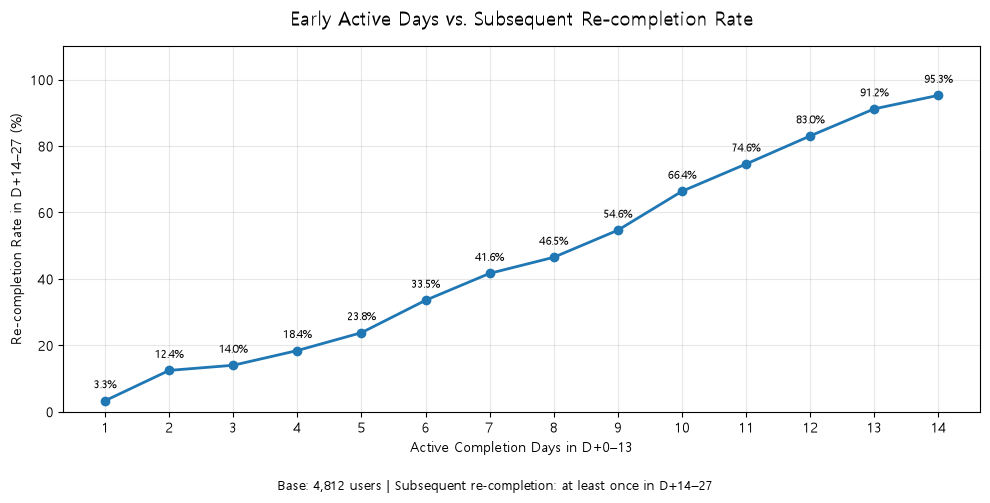

In [97]:
# 첫 14일 활동일 수별 이후 14일 재완료율
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    activity_return_summary["active_days_14"],
    activity_return_summary["return_rate"],
    marker="o",
    markersize=6,
    linewidth=2
)

# 각 지점에 재완료율 표시
for _, row in activity_return_summary.iterrows():
    ax.annotate(
        f'{row["return_rate"]:.1f}%',
        xy=(row["active_days_14"], row["return_rate"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

ax.set_title(
    "Early Active Days vs. Subsequent Re-completion Rate",
    fontsize=14,
    pad=15
)
ax.set_xlabel("Active Completion Days in D+0–13")
ax.set_ylabel("Re-completion Rate in D+14–27 (%)")

ax.set_xticks(range(1, 15))
ax.set_ylim(0, 110)
ax.grid(alpha=0.3)

fig.text(
    0.5, 0.01,
    "Base: 4,812 users | Subsequent re-completion: at least once in D+14–27",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("early_activity_vs_return.png", dpi=300, bbox_inches="tight")
plt.show()

“초기 활동일 수가 많을수록 이후 재완료율도 높게 관찰됐다”

# 초기 2주 활동이후 2주 활동여부에 따른 그룹 분리

# 초기 2주간 질문 완료 행동 일 수 비교

In [98]:
# 1. 이후 14일 재완료 여부에 따라 그룹 이름을 붙인다.
group_comparison = activity_vs_return.copy()

group_comparison["return_group"] = group_comparison[
    "returned_14_27"
].map({
    1: "재완료",
    0: "미재완료"
})

# 2. 그룹별 유저 수와 첫 14일 활동일 수를 비교한다.
group_summary = (
    group_comparison
    .groupby("return_group", as_index=False)
    .agg(
        users=("user_id", "nunique"),
        mean_active_days_14=("active_days_14", "mean"),
        median_active_days_14=("active_days_14", "median")
    )
)

# 3. 전체 4,812명 중 각 그룹의 비중을 계산한다.
group_summary["user_share_pct"] = (
    group_summary["users"] / len(group_comparison) * 100
).round(2)

group_summary["mean_active_days_14"] = (
    group_summary["mean_active_days_14"].round(2)
)

print("분석 대상 유저:", len(group_comparison))
print("그룹별 유저 수 합계:", group_summary["users"].sum())

display(
    group_summary[
        [
            "return_group",
            "users",
            "user_share_pct",
            "mean_active_days_14",
            "median_active_days_14"
        ]
    ]
)

분석 대상 유저: 4812
그룹별 유저 수 합계: 4812


,return_group,users,user_share_pct,mean_active_days_14,median_active_days_14
0,미재완료,2497,51.89,6.04,6.0
1,재완료,2315,48.11,9.60,10.0


## 확인 결과.

- 초기 2주 활동 이후 추가 2주 활동여부에 따른 그룹 분리 결과.
- 비교적 균등한 비율로 그룹이 나뉨.
- 3~4주차 활동이 없던 유저 그룹의 경우 초기 14일간 6일정도 질문 완료 행동을 함.
- 활동이 있는 유저 그룹의 경우 초기 14일간 10일정도 질문 완료 행동을 함.

# 초기 2주간 질문 완료수 비교

In [99]:
# 1. 질문세트별 추정 완료 시각이 있는 데이터에서
#    첫 완료일 기준 D+0~13에 해당하는 세트만 선택한다.
#    daily_sets에는 질문세트 1개당 1행이 들어 있다.
first_14_sets = daily_sets.loc[
    daily_sets["day_offset"].between(0, 13),
    ["user_id", "day_offset"]
].copy()

# 2. 유저별 첫 14일 질문세트 완료 횟수를 계산한다.
#    같은 날 여러 세트를 완료했다면 모두 횟수에 포함한다.
completion_count_14 = (
    first_14_sets
    .groupby("user_id")
    .size()
    .rename("completed_sets_14")
    .reset_index()
)

# 3. 기존 재완료·미재완료 그룹에 완료 횟수를 연결한다.
#    원본 group_comparison은 수정하지 않는다.
group_completion = group_comparison.merge(
    completion_count_14,
    on="user_id",
    how="left",
    validate="one_to_one"
)

# 4. 그룹별 평균·중앙값과 유저 수를 비교한다.
completion_summary = (
    group_completion
    .groupby("return_group", as_index=False)
    .agg(
        users=("user_id", "nunique"),
        mean_completed_sets_14=("completed_sets_14", "mean"),
        median_completed_sets_14=("completed_sets_14", "median")
    )
)

completion_summary["mean_completed_sets_14"] = (
    completion_summary["mean_completed_sets_14"].round(2)
)

print("분석 대상 유저:", len(group_completion))
print("완료 횟수 결측:", group_completion["completed_sets_14"].isna().sum())

display(completion_summary)

분석 대상 유저: 4812
완료 횟수 결측: 0


,return_group,users,mean_completed_sets_14,median_completed_sets_14
0,미재완료,2497,20.39,16.0
1,재완료,2315,36.17,31.0


## 확인 결과.
초기 2주간 질문 세트 완료 수를 비교한 결과.
> 미재완료 그룹보다 재완료 그룹이 평균 완료 수와 중앙값 완료 수가 더 높은 것을 확인할 수 있으며, 해당 결과가 일어나는 원인은 아직까지 알 수 없다. 따라서, 어떤 사유로 재완료 그룹의 초기 2주간의 질문 완료 수가 높은 것인지 추가 분석이 필요하다.

# 이용 가능 시점 기준 설정 분석

### 친구요청 테이블 준비

In [100]:
# BigQuery에 친구 요청 테이블이 적재되어 있는지 확인한다.
# 아직 전체 데이터를 조회하지 않으므로 처리량을 줄일 수 있다.

table_id = "sns-analysis-prj.sns_analysis.accounts_friendrequest"

try:
    friend_table = client.get_table(table_id)

    print("테이블 확인 완료:", friend_table.full_table_id)
    print("전체 행 수:", f"{friend_table.num_rows:,}")

    print("\n컬럼 구조")
    for field in friend_table.schema:
        print(f"- {field.name}: {field.field_type}")

except Exception as e:
    print("테이블 확인 실패:", e)

테이블 확인 완료: sns-analysis-prj:sns_analysis.accounts_friendrequest
전체 행 수: 17,147,175

컬럼 구조
- id: INTEGER
- status: STRING
- created_at: TIMESTAMP
- updated_at: TIMESTAMP
- receive_user_id: INTEGER
- send_user_id: INTEGER


In [101]:
# 친구 요청 상태별 건수와 생성·업데이트 시각의 관계를 점검한다.
# 전체 1,714만 행을 pandas로 가져오지 않고 BigQuery에서 집계한다.

query = """
SELECT
    status,
    COUNT(*) AS request_count,

    -- 요청 생성 시각과 마지막 업데이트 시각이 같은 건수
    COUNTIF(created_at = updated_at) AS same_timestamp_count,

    -- 마지막 업데이트가 요청 생성보다 늦은 건수
    COUNTIF(updated_at > created_at) AS updated_later_count,

    -- 마지막 업데이트가 요청 생성보다 빠른 이상 기록 건수
    COUNTIF(updated_at < created_at) AS updated_earlier_count,

    -- 시각 정보가 없는 건수
    COUNTIF(created_at IS NULL) AS missing_created_at,
    COUNTIF(updated_at IS NULL) AS missing_updated_at

FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
GROUP BY status
ORDER BY request_count DESC
"""

friend_status_check = client.query(query).to_dataframe()

display(friend_status_check)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,status,request_count,same_timestamp_count,updated_later_count,updated_earlier_count,missing_created_at,missing_updated_at
0,A,12878407,0,12878407,0,0,0
1,P,3938608,3938451,157,0,0,0
2,R,330160,0,330160,0,0,0


- 수락(A) 12,878,407건: 전부 updated_at > created_at


- 대기(P) 3,938,608건: 대부분 두 시각이 같지만, 157건은 업데이트 이력이 있음



- 거절(R) 330,160건: 전부 updated_at > created_at



- 전체 상태: 시각 역전과 결측은 0건

In [102]:
# 수락된 친구 요청에서 동일한 두 유저 사이의 중복 관계를 점검한다.
# A → B와 B → A는 같은 친구 쌍으로 취급한다.
# 전체 원본을 내려받지 않고 BigQuery에서 집계한다.

query = """
WITH accepted AS (
    SELECT
        id,
        send_user_id,
        receive_user_id,
        created_at,
        updated_at,

        -- 요청 방향과 관계없이 동일한 친구 쌍을 식별한다.
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
),

pair_counts AS (
    SELECT
        user_a,
        user_b,
        COUNT(*) AS accepted_request_count
    FROM accepted
    GROUP BY user_a, user_b
)

SELECT
    (SELECT COUNT(*) FROM accepted) AS accepted_requests,
    COUNT(*) AS unique_friend_pairs,
    COUNTIF(accepted_request_count > 1) AS duplicated_friend_pairs,
    COALESCE(
        SUM(IF(accepted_request_count > 1, accepted_request_count - 1, 0)),
        0
    ) AS extra_accepted_requests,
    MAX(accepted_request_count) AS max_requests_per_pair,
    (SELECT COUNTIF(send_user_id = receive_user_id) FROM accepted)
        AS self_friend_requests
FROM pair_counts
"""

friend_pair_check = client.query(query).to_dataframe()
display(friend_pair_check)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,accepted_requests,unique_friend_pairs,duplicated_friend_pairs,extra_accepted_requests,max_requests_per_pair,self_friend_requests
0,12878407,12875445,2960,2962,3,0


In [103]:
# 동일한 두 유저 사이에 수락 요청이 여러 번 있는 경우,
# 최초·최후 업데이트 시각의 간격을 확인한다.
# 요청 방향(A→B / B→A)은 구분하지 않는다.

query = """
WITH accepted_pairs AS (
    SELECT
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b,
        updated_at
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
),

duplicate_pairs AS (
    SELECT
        user_a,
        user_b,
        COUNT(*) AS request_count,
        MIN(updated_at) AS first_accepted_at,
        MAX(updated_at) AS last_accepted_at
    FROM accepted_pairs
    GROUP BY user_a, user_b
    HAVING COUNT(*) > 1
)

SELECT
    COUNT(*) AS duplicate_pairs,

    COUNTIF(first_accepted_at = last_accepted_at)
        AS same_acceptance_time_pairs,

    COUNTIF(
        TIMESTAMP_DIFF(last_accepted_at, first_accepted_at, DAY) >= 1
    ) AS gap_at_least_1_day,

    COUNTIF(
        TIMESTAMP_DIFF(last_accepted_at, first_accepted_at, DAY) >= 30
    ) AS gap_at_least_30_days,

    ROUND(
        AVG(
            TIMESTAMP_DIFF(
                last_accepted_at, first_accepted_at, HOUR
            )
        ),
        2
    ) AS mean_gap_hours,

    MAX(
        TIMESTAMP_DIFF(
            last_accepted_at, first_accepted_at, DAY
        )
    ) AS max_gap_days

FROM duplicate_pairs
"""

friend_duplicate_gap = client.query(query).to_dataframe()
display(friend_duplicate_gap)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,duplicate_pairs,same_acceptance_time_pairs,gap_at_least_1_day,gap_at_least_30_days,mean_gap_hours,max_gap_days
0,2960,0,1867,50,106.19,193


In [104]:
# [검증 1] 중복된 수락 친구 쌍의 기록 형태 분류
# - A→B와 B→A를 동일한 친구 쌍으로 묶는다.
# - 양방향 기록이 같은 updated_at을 공유하는지도 별도로 확인한다.
# - 전체 데이터를 pandas로 가져오지 않고 BigQuery에서 집계한다.

query = """
WITH accepted AS (
    SELECT
        id,
        send_user_id,
        receive_user_id,
        updated_at,
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
      AND send_user_id IS NOT NULL
      AND receive_user_id IS NOT NULL
      AND send_user_id != receive_user_id
),

-- 같은 친구 쌍 + 같은 업데이트 시각에
-- 양방향 기록이 함께 존재하는지 확인한다.
same_time AS (
    SELECT
        user_a,
        user_b,
        updated_at,
        COUNT(DISTINCT send_user_id) AS sender_count
    FROM accepted
    GROUP BY user_a, user_b, updated_at
),

pair_summary AS (
    SELECT
        a.user_a,
        a.user_b,
        COUNT(*) AS request_count,
        COUNT(DISTINCT a.send_user_id) AS direction_count,
        COUNT(DISTINCT a.updated_at) AS timestamp_count,
        MAX(
            IF(s.sender_count = 2, 1, 0)
        ) AS has_same_time_bidirectional
    FROM accepted AS a
    JOIN same_time AS s
      ON a.user_a = s.user_a
     AND a.user_b = s.user_b
     AND a.updated_at = s.updated_at
    GROUP BY a.user_a, a.user_b
    HAVING COUNT(*) > 1
)

SELECT
    CASE
        WHEN direction_count = 2
             AND has_same_time_bidirectional = 1
            THEN '양방향·동일 시각 기록 존재'
        WHEN direction_count = 2
            THEN '양방향·동일 시각 기록 없음'
        WHEN timestamp_count = 1
            THEN '단방향·동일 시각'
        ELSE '단방향·서로 다른 시각'
    END AS duplicate_type,
    COUNT(*) AS friend_pairs,
    SUM(request_count) AS accepted_requests,
    MAX(request_count) AS max_requests_per_pair
FROM pair_summary
GROUP BY duplicate_type
ORDER BY friend_pairs DESC
"""

friend_duplicate_types = client.query(query).to_dataframe()

display(friend_duplicate_types)

print(
    "중복 친구 쌍 합계:",
    f"{friend_duplicate_types['friend_pairs'].sum():,}"
)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,duplicate_type,friend_pairs,accepted_requests,max_requests_per_pair
0,단방향·서로 다른 시각,1955,3911,3
1,양방향·동일 시각 기록 없음,1005,2011,3


중복 친구 쌍 합계: 2,960


In [105]:
# [검증 2] 중복된 친구 쌍의 실제 요청 기록을 유형별 5쌍씩 확인한다.
# 동일 친구 쌍은 요청 방향과 관계없이 하나로 묶는다.
# 코호트 전체나 원본 테이블 전체를 pandas로 가져오지 않는다.

query = """
WITH accepted AS (
    SELECT
        id,
        send_user_id,
        receive_user_id,
        created_at,
        updated_at,
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
      AND send_user_id IS NOT NULL
      AND receive_user_id IS NOT NULL
      AND send_user_id != receive_user_id
),

pair_summary AS (
    SELECT
        user_a,
        user_b,
        COUNT(*) AS request_count,
        COUNT(DISTINCT send_user_id) AS direction_count
    FROM accepted
    GROUP BY user_a, user_b
    HAVING COUNT(*) > 1
),

-- 유형별로 중복 친구 쌍 5개씩 선택한다.
sample_pairs AS (
    SELECT
        user_a,
        user_b,
        CASE
            WHEN direction_count = 1 THEN '단방향 중복'
            ELSE '양방향 중복'
        END AS duplicate_type
    FROM pair_summary
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY direction_count
        ORDER BY user_a, user_b
    ) <= 5
)

SELECT
    s.duplicate_type,
    a.user_a,
    a.user_b,
    a.id AS request_id,
    a.send_user_id,
    a.receive_user_id,
    a.created_at,
    a.updated_at,
    TIMESTAMP_DIFF(
        a.updated_at, a.created_at, HOUR
    ) AS request_to_update_hours
FROM sample_pairs AS s
JOIN accepted AS a
  ON s.user_a = a.user_a
 AND s.user_b = a.user_b
ORDER BY
    s.duplicate_type,
    a.user_a,
    a.user_b,
    a.created_at,
    a.id
"""

friend_duplicate_examples = client.query(query).to_dataframe()
display(friend_duplicate_examples)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,duplicate_type,user_a,user_b,request_id,send_user_id,receive_user_id,created_at,updated_at,request_to_update_hours
0,단방향 중복,839017,884858,12326797,884858,839017,2023-05-18 15:44:52+00:00,2023-05-27 04:09:49+00:00,204
1,단방향 중복,839017,884858,18680405,884858,839017,2023-05-31 14:45:27+00:00,2023-06-01 14:42:20+00:00,23
2,단방향 중복,840841,1208686,12239391,840841,1208686,2023-05-18 13:33:58+00:00,2023-05-18 13:50:42+00:00,0
3,단방향 중복,840841,1208686,12673094,840841,1208686,2023-05-19 12:57:54+00:00,2023-05-19 13:05:12+00:00,0
4,단방향 중복,840841,1231749,12239093,840841,1231749,2023-05-18 13:33:41+00:00,2023-05-18 13:38:44+00:00,0
5,단방향 중복,840841,1231749,12673933,840841,1231749,2023-05-19 12:58:48+00:00,2023-05-19 14:22:00+00:00,1
6,단방향 중복,841892,1006634,12213470,1006634,841892,2023-05-18 13:00:53+00:00,2023-05-21 06:35:38+00:00,65
7,단방향 중복,841892,1006634,14033494,1006634,841892,2023-05-21 14:54:47+00:00,2023-05-24 00:41:30+00:00,57
8,단방향 중복,842072,947485,12289092,947485,842072,2023-05-18 14:38:03+00:00,2023-05-20 01:59:59+00:00,35
9,단방향 중복,842072,947485,18289144,947485,842072,2023-05-29 17:18:19+00:00,2023-05-30 11:23:40+00:00,18


In [106]:
# [검증 3] 코호트 유저 중 '수락 기록이 중복된 친구 관계'가 있는 유저 수 확인
# 같은 친구 쌍의 요청이 2건 이상이면 중복 관계로 분류한다.
# 코호트 밖 친구와의 관계도 포함한다.

cohort_ids = cohort_df["user_id"].dropna().astype(int).unique().tolist()

query = """
WITH accepted_pairs AS (
    SELECT
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b,
        COUNT(*) AS accepted_request_count
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
      AND send_user_id IS NOT NULL
      AND receive_user_id IS NOT NULL
      AND send_user_id != receive_user_id
    GROUP BY user_a, user_b
),

duplicate_pairs AS (
    SELECT user_a, user_b
    FROM accepted_pairs
    WHERE accepted_request_count > 1
),

-- 친구 관계의 양쪽 유저에게 중복 관계 여부를 반영한다.
cohort_duplicate_users AS (
    SELECT user_a AS user_id
    FROM duplicate_pairs
    WHERE user_a IN UNNEST(@cohort_ids)

    UNION ALL

    SELECT user_b AS user_id
    FROM duplicate_pairs
    WHERE user_b IN UNNEST(@cohort_ids)
)

SELECT
    COUNT(DISTINCT user_id) AS users_with_duplicate_friend_pairs,
    COUNT(*) AS duplicate_pair_participations
FROM cohort_duplicate_users
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("cohort_ids", "INT64", cohort_ids)
    ]
)

cohort_duplicate_check = client.query(
    query,
    job_config=job_config
).to_dataframe()

display(cohort_duplicate_check)

print("전체 코호트 유저:", len(cohort_ids))

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,users_with_duplicate_friend_pairs,duplicate_pair_participations
0,30,37


전체 코호트 유저: 5090


### 서비스 이용 가능 시점 기준 설정을 위한 분석

In [107]:
cohort_ids = cohort_df["user_id"].dropna().astype(int).unique().tolist()

query = """
WITH cohort_questionsets AS (
    SELECT
        q.user_id,
        q.status,
        q.opening_time
    FROM `sns-analysis-prj.sns_analysis.polls_questionset` AS q
    WHERE q.user_id IN UNNEST(@cohort_ids)
),

user_first_open AS (
    SELECT
        user_id,
        MIN(opening_time) AS first_open_at
    FROM cohort_questionsets
    WHERE opening_time IS NOT NULL
    GROUP BY user_id
)

SELECT
    '전체 코호트' AS metric,
    COUNT(*) AS users,
    CAST(NULL AS INT64) AS questionsets
FROM UNNEST(@cohort_ids)

UNION ALL

SELECT
    '질문세트 기록 보유',
    COUNT(DISTINCT user_id),
    COUNT(*)
FROM cohort_questionsets

UNION ALL

SELECT
    '첫 오픈 시각 확인 가능',
    COUNT(*),
    CAST(NULL AS INT64)
FROM user_first_open

UNION ALL

SELECT
    CONCAT('상태: ', COALESCE(status, 'NULL')),
    COUNT(DISTINCT user_id),
    COUNT(*)
FROM cohort_questionsets
GROUP BY status

UNION ALL

SELECT
    'opening_time 결측',
    COUNT(DISTINCT user_id),
    COUNT(*)
FROM cohort_questionsets
WHERE opening_time IS NULL
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("cohort_ids", "INT64", cohort_ids)
    ]
)

open_baseline_check = client.query(
    query,
    job_config=job_config
).to_dataframe()

display(open_baseline_check)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,metric,users,questionsets
0,전체 코호트,5090,<NA>
1,질문세트 기록 보유,4972,158384
2,첫 오픈 시각 확인 가능,4972,<NA>
3,상태: C,566,566
4,상태: F,4846,153411
5,상태: O,4407,4407
6,opening_time 결측,0,0


In [108]:
# [2단계] 코호트 전체에 첫 질문세트 오픈 시각 연결
# - F뿐 아니라 C·O를 포함한 모든 질문세트에서 최초 opening_time을 사용한다.
# - 원본 cohort_df와 df는 수정하지 않는다.
# - BigQuery에서는 유저별 최초 시각만 집계해서 가져온다.


cohort_ids = cohort_df["user_id"].dropna().astype(int).unique().tolist()

query = """
SELECT
    user_id,
    MIN(opening_time) AS first_open_at
FROM `sns-analysis-prj.sns_analysis.polls_questionset`
WHERE user_id IN UNNEST(@cohort_ids)
GROUP BY user_id
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("cohort_ids", "INT64", cohort_ids)
    ]
)

first_open_df = client.query(
    query,
    job_config=job_config
).to_dataframe()

# 코호트 5,090명을 모두 유지한다.
availability_base = (
    cohort_df[["user_id", "school_id", "signup_at"]]
    .drop_duplicates(subset="user_id")
    .merge(first_open_df, on="user_id", how="left", validate="one_to_one")
)

print("전체 코호트:", len(availability_base))
print("첫 오픈 확인 가능:", availability_base["first_open_at"].notna().sum())
print("첫 오픈 확인 불가:", availability_base["first_open_at"].isna().sum())
print(
    "가입보다 첫 오픈이 빠른 유저:",
    (
        pd.to_datetime(availability_base["first_open_at"], utc=True)
        < pd.to_datetime(availability_base["signup_at"], utc=True)
    ).sum()
)

display(availability_base.head())

전체 코호트: 5090
첫 오픈 확인 가능: 4972
첫 오픈 확인 불가: 118
가입보다 첫 오픈이 빠른 유저: 0


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,school_id,signup_at,first_open_at
0,1177676,5491,2023-05-12 13:14:53.952100+00:00,2023-05-12 13:20:18+00:00
1,1550300,4516,2023-05-30 05:42:04.859648+00:00,2023-05-30 05:42:45+00:00
2,895699,352,2023-05-06 06:44:55.258862+00:00,2023-05-06 06:45:34+00:00
3,994302,4516,2023-05-08 07:04:02.846792+00:00,2023-05-08 07:13:55+00:00
4,1365450,5372,2023-05-18 05:03:41.260113+00:00,2023-05-18 05:05:04+00:00


In [109]:
# [오류 수정] accounts_user의 실제 컬럼명 확인
# 데이터 전체를 조회하지 않고 테이블 구조만 확인하므로 가볍게 실행할 수 있어.

schema_df = client.query("""
SELECT
    column_name,
    data_type
FROM `sns-analysis-prj.sns_analysis.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'accounts_user'
ORDER BY ordinal_position
""").to_dataframe()

display(schema_df)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,column_name,data_type
0,id,INT64
1,is_superuser,INT64
2,is_staff,INT64
3,gender,STRING
4,point,INT64
5,friend_id_list,STRING
6,is_push_on,INT64
7,created_at,TIMESTAMP
8,block_user_id_list,STRING
9,hide_user_id_list,STRING


In [110]:
# [3단계] 학교별 40번째 가입 시각과 첫 질문세트 오픈 시각 비교
# 연결: accounts_user.group_id → accounts_group.id → accounts_group.school_id
# 기존 df, cohort_df, availability_base는 수정하지 않음

school_ids = (
    availability_base["school_id"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

query = """
WITH school_users AS (
    SELECT
        g.school_id,
        u.id AS user_id,
        u.created_at AS signup_at
    FROM `sns-analysis-prj.sns_analysis.accounts_user` AS u
    JOIN `sns-analysis-prj.sns_analysis.accounts_group` AS g
        ON u.group_id = g.id
    WHERE g.school_id IN UNNEST(@school_ids)
      AND u.created_at IS NOT NULL
),

ranked_users AS (
    SELECT
        school_id,
        signup_at,
        ROW_NUMBER() OVER (
            PARTITION BY school_id
            ORDER BY signup_at, user_id
        ) AS signup_order
    FROM school_users
)

SELECT
    school_id,
    signup_at AS school_40_at
FROM ranked_users
WHERE signup_order = 40
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("school_ids", "INT64", school_ids)
    ]
)

school_40_df = client.query(
    query,
    job_config=job_config
).to_dataframe()

# 첫 오픈 유저 4,972명을 기준으로 비교
school_check = availability_base.merge(
    school_40_df,
    on="school_id",
    how="left",
    validate="many_to_one"
)

opened_school_check = school_check.loc[
    school_check["first_open_at"].notna()
].copy()

opened_school_check["school_40_met_at_open"] = (
    opened_school_check["school_40_at"].notna()
    & (
        pd.to_datetime(opened_school_check["school_40_at"], utc=True)
        <= pd.to_datetime(opened_school_check["first_open_at"], utc=True)
    )
)

print("학교 수:", len(school_ids))
print("학교 40명 도달 시각 확인 가능:", school_40_df["school_id"].nunique())
print("첫 오픈 유저:", len(opened_school_check))
print("첫 오픈 당시 학교 40명 충족:", opened_school_check["school_40_met_at_open"].sum())
print("첫 오픈 당시 학교 40명 미충족:", (~opened_school_check["school_40_met_at_open"]).sum())
print("학교 40명 도달 시각 확인 불가:", opened_school_check["school_40_at"].isna().sum())

display(
    opened_school_check.loc[
        ~opened_school_check["school_40_met_at_open"],
        ["user_id", "school_id", "signup_at", "first_open_at", "school_40_at"]
    ].head(20)
)

학교 수: 10
학교 40명 도달 시각 확인 가능: 10
첫 오픈 유저: 4972
첫 오픈 당시 학교 40명 충족: 4950
첫 오픈 당시 학교 40명 미충족: 22
학교 40명 도달 시각 확인 불가: 0


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,school_id,signup_at,first_open_at,school_40_at
263,871458,369,2023-05-02 13:08:56.928952+00:00,2023-05-02 22:24:48+00:00,2023-05-02 22:44:27.267798+00:00
494,871913,369,2023-05-02 13:54:15.783202+00:00,2023-05-02 22:25:25+00:00,2023-05-02 22:44:27.267798+00:00
625,868425,369,2023-05-02 01:31:06.332433+00:00,2023-05-02 22:27:19+00:00,2023-05-02 22:44:27.267798+00:00
684,859087,369,2023-04-30 12:02:28.365035+00:00,2023-05-02 22:26:35+00:00,2023-05-02 22:44:27.267798+00:00
852,870224,369,2023-05-02 09:34:43.446143+00:00,2023-05-02 22:41:53+00:00,2023-05-02 22:44:27.267798+00:00
1166,868277,369,2023-05-02 00:33:04.700031+00:00,2023-05-02 22:25:07+00:00,2023-05-02 22:44:27.267798+00:00
1204,840685,369,2023-04-21 15:23:53.149852+00:00,2023-05-02 22:21:43+00:00,2023-05-02 22:44:27.267798+00:00
1211,840902,369,2023-04-22 00:10:16.615160+00:00,2023-05-02 22:32:47+00:00,2023-05-02 22:44:27.267798+00:00
1431,870326,369,2023-05-02 10:00:03.346775+00:00,2023-05-02 22:11:11+00:00,2023-05-02 22:44:27.267798+00:00
1708,869250,369,2023-05-02 05:45:29.471631+00:00,2023-05-02 21:37:17+00:00,2023-05-02 22:44:27.267798+00:00


In [111]:
# [4단계] 첫 오픈 당시 학교 40명 × 친구 4명 조건 비교
# 기존 df, cohort_df, availability_base, opened_school_check는 수정하지 않음

opened_ids = opened_school_check["user_id"].astype(int).unique().tolist()

query = """
WITH accepted_pairs AS (
    SELECT
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b,
        MIN(updated_at) AS estimated_accepted_at
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
      AND send_user_id IS NOT NULL
      AND receive_user_id IS NOT NULL
      AND send_user_id != receive_user_id
      AND updated_at IS NOT NULL
      AND (
          send_user_id IN UNNEST(@opened_ids)
          OR receive_user_id IN UNNEST(@opened_ids)
      )
    GROUP BY user_a, user_b
),

friend_events AS (
    SELECT user_a AS user_id, user_b AS friend_id, estimated_accepted_at
    FROM accepted_pairs

    UNION ALL

    SELECT user_b AS user_id, user_a AS friend_id, estimated_accepted_at
    FROM accepted_pairs
),

ranked_friends AS (
    SELECT
        user_id,
        friend_id,
        estimated_accepted_at,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY estimated_accepted_at, friend_id
        ) AS friend_order
    FROM friend_events
)

SELECT
    user_id,
    MAX(IF(friend_order = 4, estimated_accepted_at, NULL)) AS estimated_friend_4_at
FROM ranked_friends
GROUP BY user_id
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("opened_ids", "INT64", opened_ids)
    ]
)

friend_4_df = client.query(
    query,
    job_config=job_config
).to_dataframe()

# 학교 조건을 확인한 동일한 4,972명에 친구 조건 연결
condition_check = opened_school_check.merge(
    friend_4_df,
    on="user_id",
    how="left",
    validate="one_to_one"
)

condition_check["friend_4_met_at_open"] = (
    condition_check["estimated_friend_4_at"].notna()
    & (
        pd.to_datetime(condition_check["estimated_friend_4_at"], utc=True)
        <= pd.to_datetime(condition_check["first_open_at"], utc=True)
    )
)

# 첫 오픈 당시 학교/친구 조건의 네 가지 조합
condition_check["condition_group"] = (
    condition_check["school_40_met_at_open"].map({True: "학교 충족", False: "학교 미충족"})
    + " / "
    + condition_check["friend_4_met_at_open"].map({True: "친구 충족", False: "친구 미충족"})
)

condition_summary = (
    condition_check.groupby("condition_group")
    .agg(users=("user_id", "nunique"))
    .reset_index()
)

condition_summary["share_pct"] = (
    condition_summary["users"] / len(condition_check) * 100
).round(2)

display(condition_summary.sort_values("condition_group"))

print("\n조건별 첫 오픈 당시 충족 유저 수")
print("학교 40명:", int(condition_check["school_40_met_at_open"].sum()))
print("친구 4명(추정):", int(condition_check["friend_4_met_at_open"].sum()))
print(
    "학교 AND 친구:",
    int((condition_check["school_40_met_at_open"] & condition_check["friend_4_met_at_open"]).sum())
)
print(
    "학교 OR 친구:",
    int((condition_check["school_40_met_at_open"] | condition_check["friend_4_met_at_open"]).sum())
)
print("친구 4명 도달 추정 시각 없음:", int(condition_check["estimated_friend_4_at"].isna().sum()))

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,condition_group,users,share_pct
0,학교 미충족 / 친구 미충족,13,0.26
1,학교 미충족 / 친구 충족,9,0.18
2,학교 충족 / 친구 미충족,4598,92.48
3,학교 충족 / 친구 충족,352,7.08



조건별 첫 오픈 당시 충족 유저 수
학교 40명: 4950
친구 4명(추정): 361
학교 AND 친구: 352
학교 OR 친구: 4959
친구 4명 도달 추정 시각 없음: 105


In [112]:
# [5단계] 학교 40명 미충족 22명의 예외 양상 확인
# 이미 만든 condition_check만 사용하므로 BigQuery 추가 조회 없음

school_exceptions = condition_check.loc[
    ~condition_check["school_40_met_at_open"],
    [
        "user_id",
        "school_id",
        "signup_at",
        "first_open_at",
        "school_40_at",
        "estimated_friend_4_at",
        "friend_4_met_at_open",
    ],
].copy()

# 학교 40명 도달보다 몇 시간 먼저 질문세트를 열었는지
school_exceptions["hours_before_school_40"] = (
    pd.to_datetime(school_exceptions["school_40_at"], utc=True)
    - pd.to_datetime(school_exceptions["first_open_at"], utc=True)
).dt.total_seconds() / 3600

school_exceptions["hours_before_school_40"] = (
    school_exceptions["hours_before_school_40"].round(2)
)

print("학교 40명 미충족:", len(school_exceptions))
print(
    "그중 친구 4명 충족(추정):",
    int(school_exceptions["friend_4_met_at_open"].sum())
)
print(
    "그중 친구 4명 미충족(추정):",
    int((~school_exceptions["friend_4_met_at_open"]).sum())
)

display(
    school_exceptions.sort_values(
        "hours_before_school_40", ascending=False
    )
)

학교 40명 미충족: 22
그중 친구 4명 충족(추정): 9
그중 친구 4명 미충족(추정): 13


,user_id,school_id,signup_at,first_open_at,school_40_at,estimated_friend_4_at,friend_4_met_at_open,hours_before_school_40
1655,869250,369,2023-05-02 05:45:29.471631+00:00,2023-05-02 21:37:17+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-02 15:05:01+00:00,True,1.12
1875,872980,369,2023-05-02 21:55:12.427337+00:00,2023-05-02 21:55:57+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-03 00:17:57+00:00,False,0.81
3983,872991,369,2023-05-02 22:05:03.470967+00:00,2023-05-02 22:05:57+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-02 22:33:04+00:00,False,0.64
2975,871136,369,2023-05-02 12:30:14.659418+00:00,2023-05-02 22:06:24+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-03 02:14:37+00:00,False,0.63
1390,870326,369,2023-05-02 10:00:03.346775+00:00,2023-05-02 22:11:11+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-03 00:26:42+00:00,False,0.55
4534,865697,369,2023-05-01 12:27:45.206107+00:00,2023-05-02 22:21:15+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-02 22:25:41+00:00,False,0.39
1168,840685,369,2023-04-21 15:23:53.149852+00:00,2023-05-02 22:21:43+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-02 12:57:04+00:00,True,0.38
260,871458,369,2023-05-02 13:08:56.928952+00:00,2023-05-02 22:24:48+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-03 01:22:12+00:00,False,0.33
2008,869746,369,2023-05-02 07:52:04.809347+00:00,2023-05-02 22:24:55+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-02 15:04:58+00:00,True,0.33
2162,841809,369,2023-04-22 15:12:53.128168+00:00,2023-05-02 22:24:53+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-03 13:59:32+00:00,False,0.33


In [113]:
# [6단계] 학교 369의 예외 22명: 첫 오픈 시간 분포 확인
# 기존 데이터프레임은 수정하지 않음 / BigQuery 조회 없음

school_369_exceptions = (
    condition_check.loc[
        (~condition_check["school_40_met_at_open"])
        & (condition_check["school_id"] == 369),
        ["user_id", "first_open_at", "school_40_at", "friend_4_met_at_open"]
    ]
    .copy()
)

school_369_exceptions["minutes_before_school_40"] = (
    pd.to_datetime(school_369_exceptions["school_40_at"], utc=True)
    - pd.to_datetime(school_369_exceptions["first_open_at"], utc=True)
).dt.total_seconds() / 60

print("예외 유저 수:", len(school_369_exceptions))
print(
    "학교 40명 도달 추정 시각:",
    school_369_exceptions["school_40_at"].iloc[0]
)
print("\n학교 40명 도달 몇 분 전 첫 오픈했는지:")
display(
    school_369_exceptions["minutes_before_school_40"]
    .describe()
    .round(1)
)

print("\n첫 오픈 시간대별 유저 수:")
display(
    school_369_exceptions.assign(
        open_10min=pd.to_datetime(
            school_369_exceptions["first_open_at"], utc=True
        ).dt.floor("10min")
    )
    .groupby("open_10min")
    .size()
    .rename("users")
    .reset_index()
)

예외 유저 수: 22
학교 40명 도달 추정 시각: 2023-05-02 22:44:27.267798+00:00

학교 40명 도달 몇 분 전 첫 오픈했는지:


count    22.0
mean     22.7
std      14.7
min       2.5
25%      16.0
50%      19.3
75%      23.1
max      67.2
Name: minutes_before_school_40, dtype: float64


첫 오픈 시간대별 유저 수:


,open_10min,users
0,2023-05-02 21:30:00+00:00,1
1,2023-05-02 21:50:00+00:00,1
2,2023-05-02 22:00:00+00:00,2
3,2023-05-02 22:10:00+00:00,1
4,2023-05-02 22:20:00+00:00,13
5,2023-05-02 22:30:00+00:00,2
6,2023-05-02 22:40:00+00:00,2


In [114]:
# [7단계] 학급별 4번째 가입 시각 계산 및 기존 학교·친구 조건과 비교
# 전체 가입자 기준 / 기존 데이터프레임은 수정하지 않음

query = """
WITH ranked_group_users AS (
    SELECT
        group_id,
        created_at AS signup_at,
        ROW_NUMBER() OVER (
            PARTITION BY group_id
            ORDER BY created_at, id
        ) AS signup_order
    FROM `sns-analysis-prj.sns_analysis.accounts_user`
    WHERE group_id IS NOT NULL
      AND created_at IS NOT NULL
)

SELECT
    group_id,
    signup_at AS group_4_at
FROM ranked_group_users
WHERE signup_order = 4
"""

group_4_df = client.query(query).to_dataframe()

# 코호트의 group_id를 실제 사용자 테이블에서 연결
cohort_ids = condition_check["user_id"].astype(int).unique().tolist()

user_group_query = """
SELECT
    id AS user_id,
    group_id
FROM `sns-analysis-prj.sns_analysis.accounts_user`
WHERE id IN UNNEST(@cohort_ids)
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("cohort_ids", "INT64", cohort_ids)
    ]
)

user_group_df = client.query(
    user_group_query,
    job_config=job_config
).to_dataframe()

group_check = (
    condition_check
    .merge(user_group_df, on="user_id", how="left", validate="one_to_one")
    .merge(group_4_df, on="group_id", how="left", validate="many_to_one")
)

group_check["group_4_met_at_open"] = (
    group_check["group_4_at"].notna()
    & (
        pd.to_datetime(group_check["group_4_at"], utc=True)
        <= pd.to_datetime(group_check["first_open_at"], utc=True)
    )
)

s = group_check["school_40_met_at_open"]
g = group_check["group_4_met_at_open"]
f = group_check["friend_4_met_at_open"]

condition_results = pd.DataFrame({
    "조건": [
        "학교 40명",
        "학급 4명",
        "친구 4명(추정)",
        "학교 AND 학급",
        "학교 AND 친구",
        "학교 OR 친구",
        "학교 AND (학급 OR 친구)",
        "학교 OR 학급 OR 친구",
    ],
    "첫 오픈 당시 충족": [
        s.sum(),
        g.sum(),
        f.sum(),
        (s & g).sum(),
        (s & f).sum(),
        (s | f).sum(),
        (s & (g | f)).sum(),
        (s | g | f).sum(),
    ],
})

condition_results["미충족"] = (
    len(group_check) - condition_results["첫 오픈 당시 충족"]
)
condition_results["충족률(%)"] = (
    condition_results["첫 오픈 당시 충족"] / len(group_check) * 100
).round(2)

print("첫 오픈 유저:", len(group_check))
print("학급 4명 도달 시각 확인 불가:", group_check["group_4_at"].isna().sum())
display(condition_results)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


첫 오픈 유저: 4972
학급 4명 도달 시각 확인 불가: 45


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,조건,첫 오픈 당시 충족,미충족,충족률(%)
0,학교 40명,4950,22,99.56
1,학급 4명,4316,656,86.81
2,친구 4명(추정),361,4611,7.26
3,학교 AND 학급,4316,656,86.81
4,학교 AND 친구,352,4620,7.08
5,학교 OR 친구,4959,13,99.74
6,학교 AND (학급 OR 친구),4380,592,88.09
7,학교 OR 학급 OR 친구,4959,13,99.74


In [115]:
# [8단계] 학교 40명 기준의 개인별 이용 가능 '추정' 시각 계산
# 개인 가입 이전으로 시작 시각이 잡히지 않도록 보정
# 기존 데이터프레임은 수정하지 않음

import pandas as pd

school_baseline = condition_check[
    ["user_id", "signup_at", "school_40_at", "first_open_at"]
].copy()

# 시각 비교를 위한 형식 통일 (표시 시간대를 변환하려는 목적은 아님)
for col in ["signup_at", "school_40_at", "first_open_at"]:
    school_baseline[col] = pd.to_datetime(
        school_baseline[col], utc=True
    )

# 본인 가입 시각과 학교 40명 도달 시각 중 늦은 시각
school_baseline["estimated_available_at"] = school_baseline[
    ["signup_at", "school_40_at"]
].max(axis=1)

# 추정 이용 가능 시각부터 첫 오픈까지의 간격
school_baseline["hours_to_first_open"] = (
    school_baseline["first_open_at"]
    - school_baseline["estimated_available_at"]
).dt.total_seconds() / 3600

print("분석 유저:", len(school_baseline))
print(
    "추정 이용 가능 시각보다 먼저 오픈:",
    int((school_baseline["hours_to_first_open"] < 0).sum())
)
print(
    "추정 이용 가능 시각 이후 오픈:",
    int((school_baseline["hours_to_first_open"] >= 0).sum())
)

print("\n이용 가능 추정 시각 → 첫 오픈 간격 (시간):")
display(
    school_baseline.loc[
        school_baseline["hours_to_first_open"] >= 0,
        "hours_to_first_open"
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(2)
)

분석 유저: 4972
추정 이용 가능 시각보다 먼저 오픈: 22
추정 이용 가능 시각 이후 오픈: 4950

이용 가능 추정 시각 → 첫 오픈 간격 (시간):


count    4950.00
mean        7.08
std        32.81
min         0.00
25%         0.01
50%         0.02
75%         0.12
90%        13.61
95%        39.23
max       655.33
Name: hours_to_first_open, dtype: float64

In [116]:
# [9단계] 학교 40명 기준이 가입 시각과 실제로 얼마나 다른지 확인
# 기존 school_baseline을 읽기만 하며 BigQuery 추가 조회 없음

baseline_gap = school_baseline.copy()

# 학교가 40명에 도달하기 전에 가입한 유저에게만 대기 시간이 발생
baseline_gap["wait_hours_after_signup"] = (
    baseline_gap["estimated_available_at"] - baseline_gap["signup_at"]
).dt.total_seconds() / 3600

waited = baseline_gap["wait_hours_after_signup"] > 0

print("첫 오픈 유저:", len(baseline_gap))
print("가입 시각 = 이용 가능 추정 시각:", int((~waited).sum()))
print("가입 후 학교 40명 도달까지 대기:", int(waited.sum()))

print("\n대기한 유저의 대기 시간(시간):")
display(
    baseline_gap.loc[waited, "wait_hours_after_signup"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .round(2)
)

print("\n학교별 대기 유저 수:")
display(
    condition_check[["user_id", "school_id"]]
    .merge(
        baseline_gap[["user_id", "wait_hours_after_signup"]],
        on="user_id",
        validate="one_to_one"
    )
    .assign(waited=lambda x: x["wait_hours_after_signup"] > 0)
    .groupby("school_id")
    .agg(
        users=("user_id", "size"),
        waited_users=("waited", "sum")
    )
    .reset_index()
    .sort_values("waited_users", ascending=False)
)

첫 오픈 유저: 4972
가입 시각 = 이용 가능 추정 시각: 4584
가입 후 학교 40명 도달까지 대기: 388

대기한 유저의 대기 시간(시간):


count    388.00
mean      42.00
std       69.60
min        0.03
25%        1.15
50%       12.31
75%       44.54
90%      132.86
95%      238.24
max      392.21
Name: wait_hours_after_signup, dtype: float64


학교별 대기 유저 수:


,school_id,users,waited_users
1,352,477,39
2,369,557,39
6,4516,489,39
3,1478,477,39
4,1719,546,39
5,4426,481,39
9,5520,493,39
8,5491,474,39
0,271,478,38
7,5372,500,38


In [117]:
# [10단계] 가입 후 24시간 vs 학교 40명 기준 24시간
# 시작 시각이 실제로 달라지는 388명만 비교
# 기존 데이터프레임은 수정하지 않음

from google.cloud import bigquery
import pandas as pd

# 1. 학교 40명 도달 전 가입한 유저만 선택
compare_users = school_baseline.loc[
    school_baseline["estimated_available_at"] > school_baseline["signup_at"],
    ["user_id", "signup_at", "estimated_available_at", "first_open_at"]
].copy()

compare_ids = compare_users["user_id"].astype(int).tolist()

# 2. 해당 유저의 질문세트 오픈 기록만 BigQuery에서 가져오기
query = """
SELECT
    user_id,
    opening_time,
    status
FROM `sns-analysis-prj.sns_analysis.polls_questionset`
WHERE user_id IN UNNEST(@user_ids)
  AND opening_time IS NOT NULL
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("user_ids", "INT64", compare_ids)
    ]
)

compare_sets = client.query(
    query, job_config=job_config
).to_dataframe()

# 3. 유저별 두 기준 시각 연결
compare_sets = compare_sets.merge(
    compare_users,
    on="user_id",
    how="left",
    validate="many_to_one"
)

compare_sets["opening_time"] = pd.to_datetime(
    compare_sets["opening_time"], utc=True
)

# 4. 두 24시간 구간에 포함되는 오픈 기록 구분
# 시작 시각 이상, 종료 시각 미만: [시작, 시작 + 24시간)
compare_sets["in_signup_24h"] = (
    (compare_sets["opening_time"] >= compare_sets["signup_at"])
    & (compare_sets["opening_time"] < compare_sets["signup_at"] + pd.Timedelta(hours=24))
)

compare_sets["in_school_24h"] = (
    (compare_sets["opening_time"] >= compare_sets["estimated_available_at"])
    & (compare_sets["opening_time"] < compare_sets["estimated_available_at"] + pd.Timedelta(hours=24))
)

# 5. 예외 22명 여부 표시: 학교 기준 추정 시각보다 첫 오픈이 빠른 유저
compare_users["is_exception"] = (
    compare_users["first_open_at"] < compare_users["estimated_available_at"]
)

# 6. 유저별·기준별 질문세트 상태 건수 집계
summaries = []

for window_col, window_name in [
    ("in_signup_24h", "가입 후 24시간"),
    ("in_school_24h", "학교 기준 24시간"),
]:
    counts = (
        compare_sets.loc[compare_sets[window_col]]
        .groupby(["user_id", "status"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=compare_users["user_id"], fill_value=0)
        .reindex(columns=["F", "C", "O"], fill_value=0)
    )

    summaries.append({
        "기준": window_name,
        "분석 유저": len(compare_users),
        "오픈 기록 보유 유저": int((counts.sum(axis=1) > 0).sum()),
        "F 상태 기록 보유 유저": int((counts["F"] > 0).sum()),
        "F 상태 질문세트 건수": int(counts["F"].sum()),
        "C 상태 질문세트 건수": int(counts["C"].sum()),
        "O 상태 질문세트 건수": int(counts["O"].sum()),
    })

comparison_summary = pd.DataFrame(summaries)

print("시작 시각이 달라지는 유저:", len(compare_users))
print("그중 학교 기준 시각 이전에 첫 오픈한 예외:", int(compare_users["is_exception"].sum()))

display(comparison_summary)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


시작 시각이 달라지는 유저: 388
그중 학교 기준 시각 이전에 첫 오픈한 예외: 22


,기준,분석 유저,오픈 기록 보유 유저,F 상태 기록 보유 유저,F 상태 질문세트 건수,C 상태 질문세트 건수,O 상태 질문세트 건수
0,가입 후 24시간,388,142,142,712,0,0
1,학교 기준 24시간,388,256,256,1771,0,1


In [118]:
# [11단계] 일반 유저 366명 vs 예외 22명: 24시간 기준별 결과 비교
# 기존 compare_users, compare_sets는 수정하지 않음 / BigQuery 추가 조회 없음

import pandas as pd

# 유저별로 각 24시간 구간에 포함된 질문세트 수 집계
user_window_counts = compare_users[
    ["user_id", "is_exception"]
].copy()

for window_col, prefix in [
    ("in_signup_24h", "signup"),
    ("in_school_24h", "school"),
]:
    # 해당 구간에 오픈한 전체 질문세트 수
    all_counts = (
        compare_sets.loc[compare_sets[window_col]]
        .groupby("user_id")
        .size()
    )

    # 해당 구간에 오픈했고 현재 F 상태인 질문세트 수
    f_counts = (
        compare_sets.loc[
            compare_sets[window_col] & compare_sets["status"].eq("F")
        ]
        .groupby("user_id")
        .size()
    )

    user_window_counts[f"{prefix}_open_sets"] = (
        user_window_counts["user_id"].map(all_counts).fillna(0).astype(int)
    )
    user_window_counts[f"{prefix}_f_sets"] = (
        user_window_counts["user_id"].map(f_counts).fillna(0).astype(int)
    )

# 유저별로 학교 기준을 적용했을 때 F 상태 질문세트가 얼마나 달라지는지
user_window_counts["f_sets_diff"] = (
    user_window_counts["school_f_sets"]
    - user_window_counts["signup_f_sets"]
)

# 예외 여부에 따라 집계 비교
exception_comparison = (
    user_window_counts
    .assign(
        group=lambda x: x["is_exception"].map({
            False: "일반 유저",
            True: "예외 유저",
        })
    )
    .groupby("group")
    .agg(
        users=("user_id", "size"),
        signup_open_users=("signup_open_sets", lambda x: (x > 0).sum()),
        school_open_users=("school_open_sets", lambda x: (x > 0).sum()),
        signup_f_sets=("signup_f_sets", "sum"),
        school_f_sets=("school_f_sets", "sum"),
        f_increased_users=("f_sets_diff", lambda x: (x > 0).sum()),
        f_decreased_users=("f_sets_diff", lambda x: (x < 0).sum()),
    )
    .reset_index()
)

display(exception_comparison)

,group,users,signup_open_users,school_open_users,signup_f_sets,school_f_sets,f_increased_users,f_decreased_users
0,예외 유저,22,13,22,82,217,17,2
1,일반 유저,366,129,234,630,1554,181,0


In [119]:
# [12단계] 학교 40명 이전에 오픈한 예외 22명의 공통점 확인
# 기존 school_exceptions를 사용하므로 BigQuery 조회 없음

import pandas as pd

exceptions_profile = school_exceptions.copy()

# 기록된 시각을 그대로 사용해 날짜와 시간대를 구분
# 별도로 한국 시간으로 변환하지 않음
exceptions_profile["signup_date"] = pd.to_datetime(
    exceptions_profile["signup_at"], utc=True
).dt.date

exceptions_profile["first_open_10min"] = pd.to_datetime(
    exceptions_profile["first_open_at"], utc=True
).dt.floor("10min")

print("① 가입일별 유저 수")
display(
    exceptions_profile
    .groupby("signup_date")
    .size()
    .rename("users")
    .reset_index()
    .sort_values("signup_date")
)

print("\n② 첫 오픈 시간대별 유저 수")
display(
    exceptions_profile
    .groupby("first_open_10min")
    .size()
    .rename("users")
    .reset_index()
    .sort_values("first_open_10min")
)

print("\n③ 가입일 × 친구 4명 충족 여부")
display(
    pd.crosstab(
        exceptions_profile["signup_date"],
        exceptions_profile["friend_4_met_at_open"],
        margins=True
    )
)

print("\n④ 가입 → 첫 오픈까지 걸린 시간(시간)")
signup_to_open_hours = (
    pd.to_datetime(exceptions_profile["first_open_at"], utc=True)
    - pd.to_datetime(exceptions_profile["signup_at"], utc=True)
).dt.total_seconds() / 3600

display(signup_to_open_hours.describe().round(2))

① 가입일별 유저 수


,signup_date,users
0,2023-04-19,1
1,2023-04-21,2
2,2023-04-22,2
3,2023-04-29,1
4,2023-04-30,2
5,2023-05-01,1
6,2023-05-02,13



② 첫 오픈 시간대별 유저 수


,first_open_10min,users
0,2023-05-02 21:30:00+00:00,1
1,2023-05-02 21:50:00+00:00,1
2,2023-05-02 22:00:00+00:00,2
3,2023-05-02 22:10:00+00:00,1
4,2023-05-02 22:20:00+00:00,13
5,2023-05-02 22:30:00+00:00,2
6,2023-05-02 22:40:00+00:00,2



③ 가입일 × 친구 4명 충족 여부


friend_4_met_at_open,False,True,All
signup_date,,,
2023-04-19,0,1,1
2023-04-21,1,1,2
2023-04-22,2,0,2
2023-04-29,1,0,1
2023-04-30,0,2,2
2023-05-01,1,0,1
2023-05-02,8,5,13
All,13,9,22



④ 가입 → 첫 오픈까지 걸린 시간(시간)


count     22.00
mean      80.15
std      110.39
min        0.01
25%       10.25
50%       21.40
75%       77.64
max      319.52
dtype: float64

In [120]:
# [13단계] 예외 22명의 학교 40명 도달 이전 질문세트 기록 확인
# 기존 데이터프레임 수정 없음 / BigQuery 추가 조회 없음

# 1. 예외 22명의 ID 확보
exception_ids = compare_users.loc[
    compare_users["is_exception"], "user_id"
]

# 2. 예외 유저가 학교 기준 추정 시작 시각보다 먼저 오픈한 기록 추출
pre_school_sets = compare_sets.loc[
    compare_sets["user_id"].isin(exception_ids)
    & (compare_sets["opening_time"] < compare_sets["estimated_available_at"])
].copy()

# 3. 전체 규모 확인
print("예외 유저 전체:", exception_ids.nunique(), "명")
print(
    "학교 40명 도달 이전 질문세트 오픈 유저:",
    pre_school_sets["user_id"].nunique(), "명"
)
print(
    "학교 40명 도달 이전 질문세트 오픈 건수:",
    len(pre_school_sets), "건"
)

# 4. 현재 저장된 질문세트 상태별 건수
print("\n① 학교 40명 도달 이전에 오픈한 질문세트의 현재 상태")
display(
    pre_school_sets["status"]
    .fillna("NULL")
    .value_counts()
    .rename_axis("status")
    .reset_index(name="questionsets")
)

# 5. 유저별 오픈 건수 분포
print("\n② 예외 유저별 학교 40명 도달 이전 오픈 건수")
pre_school_user_counts = (
    pre_school_sets.groupby("user_id")
    .size()
    .reindex(exception_ids, fill_value=0)
)

display(pre_school_user_counts.describe().round(2))

예외 유저 전체: 22 명
학교 40명 도달 이전 질문세트 오픈 유저: 22 명
학교 40명 도달 이전 질문세트 오픈 건수: 22 건

① 학교 40명 도달 이전에 오픈한 질문세트의 현재 상태


,status,questionsets
0,F,22



② 예외 유저별 학교 40명 도달 이전 오픈 건수


count    22.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
dtype: float64

## 초기 행동 분석 | 기준 시점 및 향후 계획

### 1. 분석 목적

첫 질문세트 완료 이후 **D+14~27 재완료 여부**에 따라 구분한 두 그룹의 초기 행동을 비교한다.

- **재완료 그룹:** 첫 완료일 기준 D+14~27에 질문세트를 한 번 이상 다시 완료한 유저
- **미재완료 그룹:** 같은 기간에 질문세트를 다시 완료하지 않은 유저

기존 리텐션 그룹 정의는 유지하며, 이번 분석에서는 **초기 24시간을 언제부터 측정할지** 기준 시점을 정한다.

### 2. 현재 적용할 기준 시점

**학교 40명 기준 이용 가능 추정 시각**

`MAX(본인 가입 시각, 학교의 40번째 가입 시각)`

첫 질문세트 오픈 유저 4,972명 중 **4,950명(99.56%)**이 학교 40명 도달 이후 오픈했다. 학급 4명이나 친구 4명을 공통 필수 조건으로 추가하면 관측된 첫 오픈과 충돌하는 사례가 많았다.

따라서 **현재 분석에는 학교 40명 기준을 적용**한다. 단, 실제 서비스 개방 로직이 확인된 것은 아니므로 *이용 가능 추정 시각*으로 명명한다.

### 3. 예외 22명 처리: 잠정안

학교 40명 도달 전에 질문세트를 연 유저는 **22명**이며, 모두 학교 ID 369 소속이다.

- 22명 모두 학교 40명 도달 전에 질문세트를 **1건씩 오픈**
- 해당 22건은 현재 모두 `F` 상태
- **유저를 삭제하거나 첫 오픈 시각을 임의로 변경하지 않음**
- 우선 예외 여부를 별도 변수로 표시하여 관리
- 학교 기준 이전 오픈 기록은 학교 기준 24시간 집계에 섞지 않고 별도 확인

**예외 처리 방식만 잠정안이다.** 이후 분석에서 별도 관리가 불필요하다고 판단되면 단순화할 수 있다. 학교 40명 기준 자체는 현재 분석에 그대로 사용한다.

### 4. 분석 코드 설계 원칙

내일 팀원들과 논의한 뒤 기준이 변경되더라도 **기준 선택 부분만 수정하면 후속 분석을 다시 실행할 수 있도록 구성**한다.

- 조건별 추정 시각을 각각 보관: `school_40_at`, `group_4_at`, `estimated_friend_4_at`
- 분석에 적용할 조건을 별도 설정값으로 관리: 예) `baseline_type = "school_40"`
- 선택한 조건으로 공통 시작 시각 `analysis_start_at` 생성
- 초기 24시간 행동 집계 코드는 `analysis_start_at`만 참조
- 예외 여부와 예외 처리 방식은 시작 시각 선택과 분리하여 관리
- 기존 `df`, `cohort_df` 및 재완료/미재완료 그룹 데이터는 수정하지 않음

> 기준 변경 시에는 **개인 가입 이전 시각이 시작점이 되지 않도록 보정**하고, 새 조건에서도 첫 오픈 이전에 충족되지 않은 사례를 다시 확인한다.

### 5. 향후 분석 순서

#### STEP 1. 전체 코호트의 분석 시작 시각 구성

전체 코호트 **5,090명**에게 학교 40명 기준 추정 시작 시각을 연결한다.

- 첫 오픈 유저: 4,972명
- 첫 오픈 기록이 없는 유저: 118명
- 추정 시작 시각 계산 가능 여부 및 결측 확인
- 예외 22명 여부 표시

첫 오픈 기록이 없는 유저도 초기 행동 **이용률의 분모**에서 임의로 제외하지 않도록 확인한다.

#### STEP 2. 초기 24시간 행동 지표 생성

`analysis_start_at`부터 24시간 동안의 질문세트 행동을 유저 단위로 집계한다.

- 질문세트 오픈 여부 및 건수
- 질문세트 상태별 `F`·`C`·`O` 건수
- 초기 24시간에 오픈했고 현재 `F` 상태인 질문세트 건수

**주의:** `opening_time`과 현재 `status='F'`만으로는 *24시간 이내에 완료했다*고 판단할 수 없다. 24시간 내 실제 완료 여부가 필요하면 완료 추정 시각을 별도로 사용해야 한다.

#### STEP 3. 재완료 / 미재완료 그룹 비교

두 그룹에서 초기 24시간 행동 지표의 차이를 확인한다.

- 초기 오픈 유저 비율
- 초기 질문세트 이용 건수
- 상태별 질문세트 분포
- 예외 22명 포함 여부에 따른 결과 차이

관찰된 차이를 **연관성**으로 해석하며, 초기 행동이 재완료를 유발했다고 단정하지 않는다.

#### STEP 4. 이후 세부 분석으로 확장

초기 행동 비교 이후 기존 분석 질문으로 확장한다.

- 받은 Ping 수 및 발신자 다양성
- 힌트 확인 여부
- 질문 신고 경험
- 친구 수 및 친구 관계
- 차단 경험
- 학급·학교 환경

각 지표는 **초기 관측 기간과 이후 재완료 판정 기간이 겹치지 않도록** 설계한다.

### 6. 현재 작업 상태

- [x] 첫 오픈 유저 4,972명 확보
- [x] 학교·학급·친구 조건별 첫 오픈 시점 충족 여부 비교
- [x] 학교 40명 기준 적용 결정
- [x] 학교 40명 도달 전 선행 오픈 22명 확인
- [x] 가입 시각과 학교 기준 시작 시각이 다른 388명 확인
- [ ] 전체 5,090명의 `analysis_start_at` 생성 및 검증
- [ ] 초기 24시간 유저 단위 행동 지표 생성
- [ ] 재완료 / 미재완료 그룹 비교

**다음 작업:** 전체 5,090명의 `analysis_start_at` 생성부터 진행한다.

In [121]:
# [15단계] 전체 코호트의 분석 시작 시각 생성
# 현재 기준: MAX(본인 가입 시각, 학교 40번째 가입 시각)
# 향후 다른 기준으로 바꾸기 쉽도록 '기준 선택'과 '예외 표시'를 분리

# ============================================================
# 1. 분석 기준 선택: 향후 변경할 때 이 값부터 수정
# ============================================================
BASELINE_TYPE = "school_40"

# 현재 구현된 기준:
# - "school_40": 가입 시각과 학교 40명 도달 시각 중 늦은 시각
# - "signup":     가입 시각
#
# 친구 4명 / 학급 4명 기준은 전체 코호트의 시각을 연결한 뒤
# 이 선택지에 추가할 예정


# ============================================================
# 2. 전체 코호트 5,090명에 학교 40명 도달 시각 연결
# ============================================================
analysis_base = availability_base.merge(
    school_40_df,
    on="school_id",
    how="left",
    validate="many_to_one"
).copy()

# 시각 형식 통일: 기록된 시각을 별도로 한국 시간으로 변환하지 않음
for col in ["signup_at", "school_40_at", "first_open_at"]:
    analysis_base[col] = pd.to_datetime(
        analysis_base[col],
        utc=True
    )


# ============================================================
# 3. 기준별 시작 시각을 별도 컬럼에 보관
# ============================================================
analysis_base["signup_start_at"] = analysis_base["signup_at"]

# 두 시각이 모두 있을 때만 학교 기준 시작 시각 계산
has_school_times = (
    analysis_base["signup_at"].notna()
    & analysis_base["school_40_at"].notna()
)

analysis_base["school_40_start_at"] = (
    analysis_base[["signup_at", "school_40_at"]]
    .max(axis=1)
    .where(has_school_times)
)


# ============================================================
# 4. 선택한 기준을 공통 컬럼 analysis_start_at에 적용
# ============================================================
BASELINE_COLUMNS = {
    "school_40": "school_40_start_at",
    "signup": "signup_start_at",
}

if BASELINE_TYPE not in BASELINE_COLUMNS:
    raise ValueError(f"지원하지 않는 기준: {BASELINE_TYPE}")

analysis_base["analysis_start_at"] = analysis_base[
    BASELINE_COLUMNS[BASELINE_TYPE]
]


# ============================================================
# 5. 첫 오픈 여부 및 선택 기준 이전 오픈 예외 표시
#    예외 유저를 삭제하거나 시작 시각을 변경하지 않음
# ============================================================
analysis_base["has_first_open"] = (
    analysis_base["first_open_at"].notna()
)

analysis_base["is_baseline_exception"] = (
    analysis_base["has_first_open"]
    & analysis_base["analysis_start_at"].notna()
    & (
        analysis_base["first_open_at"]
        < analysis_base["analysis_start_at"]
    )
)


# ============================================================
# 6. 검증 결과 출력
# ============================================================
no_open = analysis_base.loc[
    ~analysis_base["has_first_open"]
]

print("적용 기준:", BASELINE_TYPE)
print("전체 코호트:", len(analysis_base))
print("고유 유저 수:", analysis_base["user_id"].nunique())
print(
    "분석 시작 시각 계산 가능:",
    analysis_base["analysis_start_at"].notna().sum()
)
print(
    "분석 시작 시각 계산 불가:",
    analysis_base["analysis_start_at"].isna().sum()
)
print("첫 오픈 기록 없음:", len(no_open))
print(
    "첫 오픈 없는 유저 중 시작 시각 계산 가능:",
    no_open["analysis_start_at"].notna().sum()
)
print(
    "선택 기준 이전 첫 오픈 예외:",
    analysis_base["is_baseline_exception"].sum()
)

display(
    analysis_base.groupby("has_first_open").agg(
        users=("user_id", "size"),
        start_available=(
            "analysis_start_at",
            lambda x: x.notna().sum()
        ),
        exceptions=("is_baseline_exception", "sum")
    )
)

적용 기준: school_40
전체 코호트: 5090
고유 유저 수: 5090
분석 시작 시각 계산 가능: 5090
분석 시작 시각 계산 불가: 0
첫 오픈 기록 없음: 118
첫 오픈 없는 유저 중 시작 시각 계산 가능: 118
선택 기준 이전 첫 오픈 예외: 22


,users,start_available,exceptions
has_first_open,,,
False,118,118,0
True,4972,4972,22


# 재완료 그룹은 초기 24시간에 질문세트를 더 많이 이용했을까?

In [122]:
# [16단계] 전체 코호트 5,090명의 초기 24시간 질문세트 행동 집계
# 기준: analysis_base["analysis_start_at"]
# 기존 df, cohort_df, analysis_base는 수정하지 않음

# ------------------------------------------------------------
# 1. 코호트의 질문세트 기록 조회
# ------------------------------------------------------------
cohort_ids = analysis_base["user_id"].astype(int).tolist()

query = """
SELECT
    user_id,
    opening_time,
    status
FROM `sns-analysis-prj.sns_analysis.polls_questionset`
WHERE user_id IN UNNEST(@user_ids)
  AND opening_time IS NOT NULL
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("user_ids", "INT64", cohort_ids)
    ]
)

initial_sets = client.query(
    query,
    job_config=job_config
).to_dataframe()

# ------------------------------------------------------------
# 2. 유저별 분석 시작 시각 연결
# ------------------------------------------------------------
initial_sets = initial_sets.merge(
    analysis_base[["user_id", "analysis_start_at"]],
    on="user_id",
    how="left",
    validate="many_to_one"
)

initial_sets["opening_time"] = pd.to_datetime(
    initial_sets["opening_time"], utc=True
)

# ------------------------------------------------------------
# 3. 초기 24시간 구간에 오픈한 질문세트만 선택
#    [시작 시각, 시작 시각 + 24시간)
# ------------------------------------------------------------
in_24h = (
    (initial_sets["opening_time"] >= initial_sets["analysis_start_at"])
    & (
        initial_sets["opening_time"]
        < initial_sets["analysis_start_at"] + pd.Timedelta(hours=24)
    )
)

initial_24h_sets = initial_sets.loc[in_24h].copy()

# ------------------------------------------------------------
# 4. 유저별 상태별 건수 집계
#    기록이 없는 유저도 0건으로 유지
# ------------------------------------------------------------
status_counts = (
    initial_24h_sets
    .groupby(["user_id", "status"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=analysis_base["user_id"],
        columns=["F", "C", "O"],
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        "F": "f_sets_24h",
        "C": "c_sets_24h",
        "O": "o_sets_24h"
    })
)

# ------------------------------------------------------------
# 5. 전체 코호트에 초기 행동 지표 연결
# ------------------------------------------------------------
initial_24h_users = analysis_base.merge(
    status_counts,
    on="user_id",
    how="left",
    validate="one_to_one"
)

count_cols = ["f_sets_24h", "c_sets_24h", "o_sets_24h"]

initial_24h_users[count_cols] = (
    initial_24h_users[count_cols].fillna(0).astype(int)
)

initial_24h_users["opened_sets_24h"] = (
    initial_24h_users[count_cols].sum(axis=1)
)

initial_24h_users["opened_any_24h"] = (
    initial_24h_users["opened_sets_24h"] > 0
)

initial_24h_users["has_f_sets_24h"] = (
    initial_24h_users["f_sets_24h"] > 0
)

# ------------------------------------------------------------
# 6. 결과 검증
# ------------------------------------------------------------
print("적용 기준:", BASELINE_TYPE)
print("전체 유저:", len(initial_24h_users))
print("고유 유저:", initial_24h_users["user_id"].nunique())
print("초기 24시간 오픈 유저:", int(initial_24h_users["opened_any_24h"].sum()))
print("초기 24시간 F 상태 기록 보유 유저:", int(initial_24h_users["has_f_sets_24h"].sum()))
print("초기 24시간 질문세트 총건수:", int(initial_24h_users["opened_sets_24h"].sum()))
print("학교 기준 이전 첫 오픈 예외:", int(initial_24h_users["is_baseline_exception"].sum()))

display(
    initial_24h_users[
        ["opened_sets_24h", "f_sets_24h", "c_sets_24h", "o_sets_24h"]
    ].describe().round(2)
)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


적용 기준: school_40
전체 유저: 5090
고유 유저: 5090
초기 24시간 오픈 유저: 4635
초기 24시간 F 상태 기록 보유 유저: 4519
초기 24시간 질문세트 총건수: 32205
학교 기준 이전 첫 오픈 예외: 22


,opened_sets_24h,f_sets_24h,c_sets_24h,o_sets_24h
count,5090.00,5090.00,5090.00,5090.00
mean,6.33,6.27,0.01,0.04
std,4.58,4.64,0.10,0.21
min,0.00,0.00,0.00,0.00
25%,3.00,3.00,0.00,0.00
50%,6.00,6.00,0.00,0.00
75%,9.00,9.00,0.00,0.00
max,27.00,27.00,1.00,1.00


In [123]:
# [17단계] 초기 24시간 완료 추정 건수 생성 → 재완료/미재완료 그룹 비교
# 기준: analysis_start_at (현재 학교 40명 기준)
# 기존 df, cohort_df, initial_24h_users, group_comparison은 수정하지 않음

# ============================================================
# 1. 완료된 질문세트(F)의 완료 추정 시각 준비
#    estimated_finished_at = 해당 질문세트에서 마지막으로 확인된 투표 시각
# ============================================================
finished_24h_source = qs_finished.loc[
    qs_finished["status"].eq("F"),
    ["user_id", "estimated_finished_at"]
].copy()

finished_24h_source["estimated_finished_at"] = pd.to_datetime(
    finished_24h_source["estimated_finished_at"],
    utc=True
)

# 유저별 초기 행동 분석 시작 시각 연결
finished_24h_source = finished_24h_source.merge(
    initial_24h_users[["user_id", "analysis_start_at"]],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

# ============================================================
# 2. 시작 시각부터 24시간 이내 완료 '추정' 기록만 선택
#    [시작 시각, 시작 시각 + 24시간)
# ============================================================
finished_in_24h = (
    finished_24h_source["estimated_finished_at"].notna()
    & (
        finished_24h_source["estimated_finished_at"]
        >= finished_24h_source["analysis_start_at"]
    )
    & (
        finished_24h_source["estimated_finished_at"]
        < finished_24h_source["analysis_start_at"]
        + pd.Timedelta(hours=24)
    )
)

estimated_completion_counts = (
    finished_24h_source.loc[finished_in_24h]
    .groupby("user_id")
    .size()
    .rename("estimated_completed_sets_24h")
)

# ============================================================
# 3. 전체 5,090명에게 완료 추정 건수 연결
#    완료 시각을 추정할 수 없는 F는 별도로 집계해 둠
# ============================================================
initial_24h_comparison = initial_24h_users.copy()

initial_24h_comparison["estimated_completed_sets_24h"] = (
    initial_24h_comparison["user_id"]
    .map(estimated_completion_counts)
    .fillna(0)
    .astype(int)
)

# 초기 24시간에 오픈했지만 완료 시각을 추정할 수 없는 F 기록
# → 완료하지 않았다는 뜻이 아니므로 별도 컬럼으로 보관
missing_finish_counts = (
    qs_finished.loc[
        qs_finished["status"].eq("F")
        & qs_finished["estimated_finished_at"].isna(),
        ["user_id", "opening_time"]
    ]
    .assign(
        opening_time=lambda x: pd.to_datetime(x["opening_time"], utc=True)
    )
    .merge(
        initial_24h_users[["user_id", "analysis_start_at"]],
        on="user_id",
        how="inner",
        validate="many_to_one"
    )
)

missing_finish_counts = (
    missing_finish_counts.loc[
        (missing_finish_counts["opening_time"]
         >= missing_finish_counts["analysis_start_at"])
        & (missing_finish_counts["opening_time"]
           < missing_finish_counts["analysis_start_at"]
           + pd.Timedelta(hours=24))
    ]
    .groupby("user_id")
    .size()
)

initial_24h_comparison["unestimated_f_sets_opened_24h"] = (
    initial_24h_comparison["user_id"]
    .map(missing_finish_counts)
    .fillna(0)
    .astype(int)
)

# ============================================================
# 4. 기존 재완료 / 미재완료 그룹 연결
#    그룹 분류가 가능한 4,812명만 그룹 비교에 사용
# ============================================================
retention_labels = group_comparison[
    ["user_id", "return_group"]
].drop_duplicates()

assert retention_labels["user_id"].is_unique, "그룹 라벨에 중복 유저가 있어요."

group_24h = initial_24h_comparison.merge(
    retention_labels,
    on="user_id",
    how="inner",
    validate="one_to_one"
)

# ============================================================
# 5. 그룹별 초기 행동 요약
# ============================================================
group_24h_summary = (
    group_24h.groupby("return_group")
    .agg(
        users=("user_id", "nunique"),
        opened_users_24h=("opened_any_24h", "sum"),
        mean_opened_sets_24h=("opened_sets_24h", "mean"),
        median_opened_sets_24h=("opened_sets_24h", "median"),
        estimated_completed_users_24h=(
            "estimated_completed_sets_24h",
            lambda x: (x > 0).sum()
        ),
        mean_estimated_completed_sets_24h=(
            "estimated_completed_sets_24h", "mean"
        ),
        median_estimated_completed_sets_24h=(
            "estimated_completed_sets_24h", "median"
        ),
        unestimated_f_sets_opened_24h=(
            "unestimated_f_sets_opened_24h", "sum"
        ),
        exceptions=("is_baseline_exception", "sum")
    )
    .reset_index()
)

group_24h_summary["opened_rate_24h_pct"] = (
    group_24h_summary["opened_users_24h"]
    / group_24h_summary["users"] * 100
).round(2)

group_24h_summary["estimated_completed_rate_24h_pct"] = (
    group_24h_summary["estimated_completed_users_24h"]
    / group_24h_summary["users"] * 100
).round(2)

# ============================================================
# 6. 결과 확인
# ============================================================
print("적용 기준:", BASELINE_TYPE)
print("전체 초기 행동 데이터:", len(initial_24h_comparison), "명")
print("그룹 비교 대상:", len(group_24h), "명")
print("그룹별 인원 합계:", group_24h_summary["users"].sum(), "명")

assert len(initial_24h_comparison) == 5090
assert len(group_24h) == 4812

display(group_24h_summary.round(2))

적용 기준: school_40
전체 초기 행동 데이터: 5090 명
그룹 비교 대상: 4812 명
그룹별 인원 합계: 4812 명


,return_group,users,opened_users_24h,mean_opened_sets_24h,median_opened_sets_24h,estimated_completed_users_24h,mean_estimated_completed_sets_24h,median_estimated_completed_sets_24h,unestimated_f_sets_opened_24h,exceptions,opened_rate_24h_pct,estimated_completed_rate_24h_pct
0,미재완료,2497,2342,6.28,6.0,2207,5.46,5.0,223,4,93.79,88.39
1,재완료,2315,2145,7.06,7.0,2061,6.31,6.0,253,18,92.66,89.03


In [124]:
# [18단계] 예외 22명 포함 / 제외에 따른 그룹 비교
# BigQuery 추가 조회 없음
# 기존 group_24h는 수정하지 않음

results = []

for label, data in [
    ("전체 포함", group_24h),
    ("예외 22명 제외", group_24h.loc[~group_24h["is_baseline_exception"]]),
]:
    summary = (
        data.groupby("return_group")
        .agg(
            users=("user_id", "nunique"),
            opened_rate=("opened_any_24h", "mean"),
            mean_opened_sets=("opened_sets_24h", "mean"),
            completed_rate=(
                "estimated_completed_sets_24h",
                lambda x: (x > 0).mean()
            ),
            mean_completed_sets=(
                "estimated_completed_sets_24h", "mean"
            ),
        )
        .reset_index()
    )

    summary.insert(0, "분석 범위", label)
    summary["opened_rate"] = (summary["opened_rate"] * 100).round(2)
    summary["completed_rate"] = (summary["completed_rate"] * 100).round(2)

    results.append(summary)

exception_sensitivity = pd.concat(results, ignore_index=True)

display(exception_sensitivity.round(2))

,분석 범위,return_group,users,opened_rate,mean_opened_sets,completed_rate,mean_completed_sets
0,전체 포함,미재완료,2497,93.79,6.28,88.39,5.46
1,전체 포함,재완료,2315,92.66,7.06,89.03,6.31
2,예외 22명 제외,미재완료,2493,93.78,6.28,88.37,5.46
3,예외 22명 제외,재완료,2297,92.60,7.04,88.94,6.28


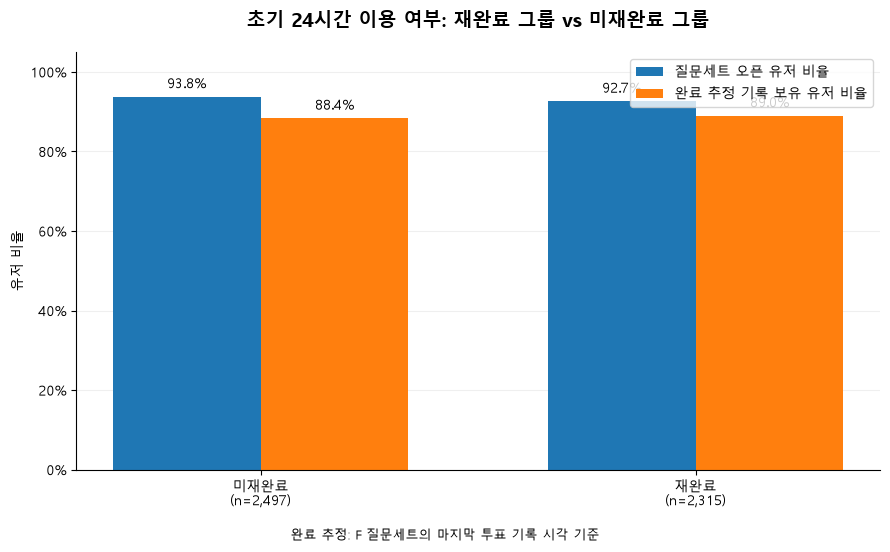

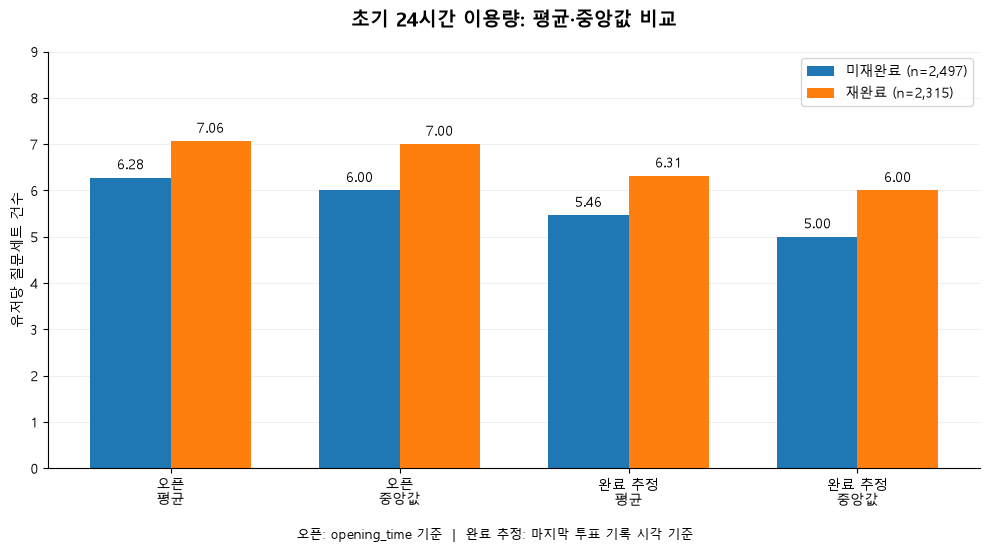

그래프 저장 완료:
- initial_24h_group_rates.png
- initial_24h_group_counts.png


,users,open_rate,completed_rate,open_mean,open_median,completed_mean,completed_median
return_group,,,,,,,
미재완료,2497,0.938,0.884,6.276,6.0,5.465,5.0
재완료,2315,0.927,0.890,7.065,7.0,6.314,6.0


In [125]:
# [19단계] 초기 24시간 행동: 재완료 vs 미재완료 시각화
# - 기준 시각: analysis_start_at (현재 학교 40명 기준)
# - 대상: 첫 완료 시각을 추정할 수 있는 4,812명
# - 기존 데이터프레임 수정 없음 / BigQuery 조회 없음
# - 그래프 2개를 PNG로 저장


# ------------------------------------------------------------
# 1. 한글 폰트 설정 (Windows)
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 2. 시각화용 그룹별 지표 집계
# ------------------------------------------------------------
group_order = ["미재완료", "재완료"]

viz_summary = (
    group_24h.groupby("return_group")
    .agg(
        users=("user_id", "nunique"),

        # 초기 24시간 내 질문세트 오픈 여부
        open_rate=("opened_any_24h", "mean"),

        # 초기 24시간 내 완료 추정 기록 보유 여부
        completed_rate=(
            "estimated_completed_sets_24h",
            lambda x: (x > 0).mean()
        ),

        # 질문세트 오픈 건수
        open_mean=("opened_sets_24h", "mean"),
        open_median=("opened_sets_24h", "median"),

        # 완료 추정 건수
        completed_mean=("estimated_completed_sets_24h", "mean"),
        completed_median=("estimated_completed_sets_24h", "median"),
    )
    .reindex(group_order)
)

assert viz_summary["users"].sum() == 4812, "그룹별 유저 수를 확인해 주세요."

# ------------------------------------------------------------
# 3. 그래프 ① 초기 24시간 이용 비율
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(group_order))
width = 0.34

open_rates = viz_summary["open_rate"].to_numpy() * 100
completed_rates = viz_summary["completed_rate"].to_numpy() * 100

bars_open = ax.bar(
    x - width / 2,
    open_rates,
    width,
    label="질문세트 오픈 유저 비율",
)

bars_completed = ax.bar(
    x + width / 2,
    completed_rates,
    width,
    label="완료 추정 기록 보유 유저 비율",
)

ax.bar_label(bars_open, fmt="%.1f%%", padding=4, fontsize=10)
ax.bar_label(bars_completed, fmt="%.1f%%", padding=4, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([
    f"{group}\n(n={int(viz_summary.loc[group, 'users']):,})"
    for group in group_order
])

ax.set_ylim(0, 105)  # 비율 차이를 과장하지 않도록 0부터 표시
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_ylabel("유저 비율")
ax.set_title(
    "초기 24시간 이용 여부: 재완료 그룹 vs 미재완료 그룹",
    fontsize=14,
    fontweight="bold",
    pad=18
)
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

fig.text(
    0.5, 0.01,
    "완료 추정: F 질문세트의 마지막 투표 기록 시각 기준",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(
    "initial_24h_group_rates.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 4. 그래프 ② 초기 24시간 이용 건수: 평균과 중앙값
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))

metrics = [
    "오픈\n평균",
    "오픈\n중앙값",
    "완료 추정\n평균",
    "완료 추정\n중앙값"
]

metric_columns = [
    "open_mean",
    "open_median",
    "completed_mean",
    "completed_median"
]

x = np.arange(len(metrics))
width = 0.35

for i, group in enumerate(group_order):
    values = viz_summary.loc[group, metric_columns].astype(float).to_numpy()

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=f"{group} (n={int(viz_summary.loc[group, 'users']):,})"
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.2f}" for value in values],
        padding=4,
        fontsize=10
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 9)
ax.set_ylabel("유저당 질문세트 건수")
ax.set_title(
    "초기 24시간 이용량: 평균·중앙값 비교",
    fontsize=14,
    fontweight="bold",
    pad=18
)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

fig.text(
    0.5, 0.01,
    "오픈: opening_time 기준  |  완료 추정: 마지막 투표 기록 시각 기준",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(
    "initial_24h_group_counts.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("그래프 저장 완료:")
print("- initial_24h_group_rates.png")
print("- initial_24h_group_counts.png")

display(viz_summary.round(3))

## 확인 결과.

첫 24시간 질문세트 이용 건수는 재완료 그룹에서 평균과 중앙값 모두 다소 높았으나, 이 차이만으로 이후 재완료의 원인을 설명할 수는 없다.

# 초기 24시간 ping 수신 차이 비교

In [126]:
# [20단계] 초기 24시간 받은 Ping 수·고유 발신자 수 그룹 비교
# - 받은 Ping: chosen_user_id가 해당 유저인 투표 기록
# - 발신자: 투표 기록의 user_id
# - 기간: analysis_start_at 이상 ~ 24시간 미만
# - 기존 데이터프레임 수정 없음

# 1. 그룹 비교 대상 4,812명의 ID와 분석 시작 시각 준비
ping_base = group_24h[
    ["user_id", "return_group", "analysis_start_at"]
].copy()

assert ping_base["user_id"].is_unique
assert ping_base["analysis_start_at"].notna().all()

ping_base["analysis_start_at"] = pd.to_datetime(
    ping_base["analysis_start_at"], utc=True
)

# BigQuery에 유저별 시작 시각을 전달할 배열
user_ids = ping_base["user_id"].astype(int).tolist()
start_times = (
    ping_base["analysis_start_at"]
    .dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")
    .tolist()
)

# 2. 유저별 초기 24시간에 받은 투표 기록 집계
query = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(start_time) AS start_at
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS pos
    JOIN UNNEST(@start_times) AS start_time WITH OFFSET AS pos2
        ON pos = pos2
)

SELECT
    w.user_id,
    COUNT(r.chosen_user_id) AS received_pings_24h,
    COUNT(DISTINCT r.user_id) AS unique_senders_24h
FROM user_windows AS w
LEFT JOIN `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS r
    ON r.chosen_user_id = w.user_id
   AND r.created_at >= w.start_at
   AND r.created_at < TIMESTAMP_ADD(w.start_at, INTERVAL 24 HOUR)
GROUP BY w.user_id
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("user_ids", "INT64", user_ids),
        bigquery.ArrayQueryParameter("start_times", "STRING", start_times),
    ]
)

ping_counts = client.query(
    query, job_config=job_config
).to_dataframe()

# 3. 받은 기록이 없는 유저도 0건으로 유지
ping_24h = ping_base.merge(
    ping_counts,
    on="user_id",
    how="left",
    validate="one_to_one"
)

for col in ["received_pings_24h", "unique_senders_24h"]:
    ping_24h[col] = ping_24h[col].fillna(0).astype(int)

ping_24h["received_any_ping_24h"] = (
    ping_24h["received_pings_24h"] > 0
)

# 4. 재완료·미재완료 그룹 비교
ping_summary = (
    ping_24h.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        received_users=("received_any_ping_24h", "sum"),
        mean_received_pings=("received_pings_24h", "mean"),
        median_received_pings=("received_pings_24h", "median"),
        mean_unique_senders=("unique_senders_24h", "mean"),
        median_unique_senders=("unique_senders_24h", "median"),
    )
    .reset_index()
)

ping_summary["received_rate_pct"] = (
    ping_summary["received_users"]
    / ping_summary["users"] * 100
).round(2)

print("그룹 비교 유저:", len(ping_24h))
print("고유 유저:", ping_24h["user_id"].nunique())
print("전체 받은 Ping 기록:", ping_24h["received_pings_24h"].sum())
display(ping_summary.round(2))

그룹 비교 유저: 4812
고유 유저: 4812
전체 받은 Ping 기록: 161527


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,return_group,users,received_users,mean_received_pings,median_received_pings,mean_unique_senders,median_unique_senders,received_rate_pct
0,미재완료,2497,2348,34.67,26.0,12.82,11.0,94.03
1,재완료,2315,2153,32.38,24.0,11.82,10.0,93.0


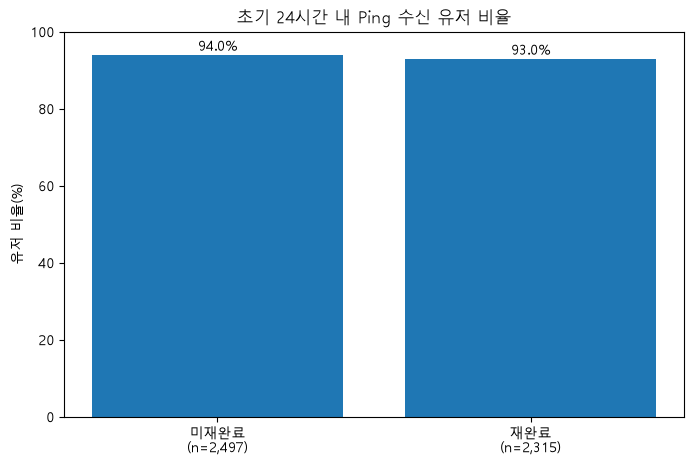

In [127]:
import matplotlib.pyplot as plt

# 예시: 네가 이미 만든 요약 데이터프레임 이름에 맞게 수정
plot_df = ping_summary.copy()

# 그룹 순서 고정
group_order = ['미재완료', '재완료']
plot_df['return_group'] = pd.Categorical(plot_df['return_group'], categories=group_order, ordered=True)
plot_df = plot_df.sort_values('return_group')

# x축 라벨
labels = [
    f"{row['return_group']}\n(n={row['users']:,})"
    for _, row in plot_df.iterrows()
]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, plot_df['received_rate_pct'])

plt.title('초기 24시간 내 Ping 수신 유저 비율')
plt.ylabel('유저 비율(%)')
plt.ylim(0, 100)

# 값 라벨
for bar, value in zip(bars, plot_df['received_rate_pct']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{value:.1f}%',
        ha='center'
    )

plt.show()

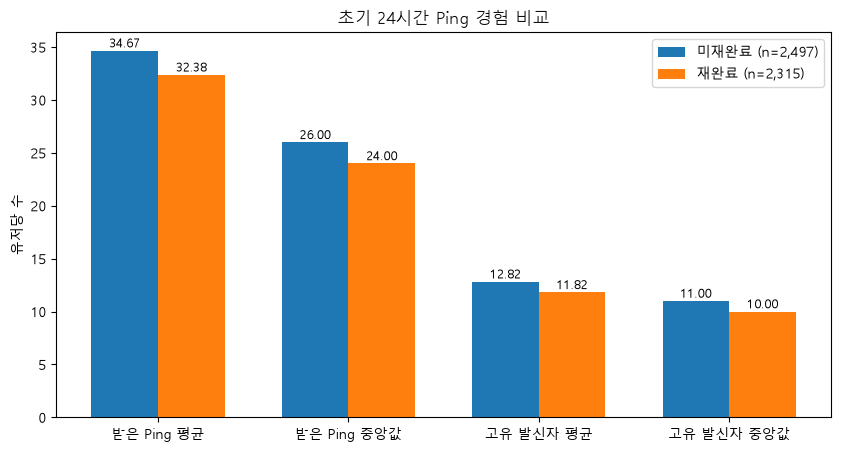

In [128]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = ping_summary.copy()
group_order = ['미재완료', '재완료']
plot_df['return_group'] = pd.Categorical(plot_df['return_group'], categories=group_order, ordered=True)
plot_df = plot_df.sort_values('return_group').reset_index(drop=True)

metrics = [
    ('mean_received_pings', '받은 Ping 평균'),
    ('median_received_pings', '받은 Ping 중앙값'),
    ('mean_unique_senders', '고유 발신자 평균'),
    ('median_unique_senders', '고유 발신자 중앙값')
]

x = np.arange(len(metrics))
width = 0.35

group1 = plot_df.loc[plot_df['return_group'] == '미재완료', [m[0] for m in metrics]].values.flatten()
group2 = plot_df.loc[plot_df['return_group'] == '재완료', [m[0] for m in metrics]].values.flatten()

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, group1, width, label=f"미재완료 (n={int(plot_df.loc[0, 'users']):,})")
bars2 = plt.bar(x + width/2, group2, width, label=f"재완료 (n={int(plot_df.loc[1, 'users']):,})")

plt.title('초기 24시간 Ping 경험 비교')
plt.ylabel('유저당 수')
plt.xticks(x, [m[1] for m in metrics])
plt.legend()

# 값 라벨
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.3,
            f'{height:.2f}',
            ha='center',
            fontsize=9
        )

plt.show()

### 확인 결과
초기 24시간 기준으로 두 그룹 모두 Ping을 받은 유저 비율은 매우 높았고 큰 차이는 없었다.
또한, 초기 24시간 기준으로 오히려 받은 ping 수는 미재완료 그룹에서 높게나왔다.
보다 명확한 차이는 초기 2주 기준으로 다시 검증할 예정이다.

# 1주차 > 2주차 받은 ping의 차이가 있는지 비교

In [129]:
# [21단계] 첫 완료 이후 1주차 vs 2주차 받은 Ping 변화 비교
# - 대상: 기존 재완료 / 미재완료 그룹 4,812명
# - 1주차: 첫 완료일 D+0~6 (첫 완료 추정 시각 이후 기록만 포함)
# - 2주차: D+7~13
# - 기존 df, cohort_df, group_24h 등은 수정하지 않음

# ============================================================
# 1. 그룹 정보와 첫 완료 추정 시각 연결
# ============================================================
ping_2w_base = (
    group_comparison[["user_id", "return_group"]]
    .merge(
        retention_users[["user_id", "first_finished_at"]],
        on="user_id",
        how="inner",
        validate="one_to_one"
    )
    .copy()
)

ping_2w_base["first_finished_at"] = pd.to_datetime(
    ping_2w_base["first_finished_at"],
    utc=True
)

assert len(ping_2w_base) == 4812, "분석 대상 유저 수를 확인해 주세요."
assert ping_2w_base["user_id"].is_unique
assert ping_2w_base["first_finished_at"].notna().all()

user_ids = ping_2w_base["user_id"].astype(int).tolist()

first_finish_times = (
    ping_2w_base["first_finished_at"]
    .dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")
    .tolist()
)

# ============================================================
# 2. BigQuery에서 유저별·주차별 Ping 집계
#    받은 기록이 0건인 유저도 두 주 모두 결과에 남도록 구성
# ============================================================
query = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(first_finish_time) AS first_finished_at,
        DATE(TIMESTAMP(first_finish_time)) AS first_finish_date
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@first_finish_times) AS first_finish_time
         WITH OFFSET AS idx2
      ON idx = idx2
),

user_weeks AS (
    SELECT
        w.*,
        week_no
    FROM user_windows AS w
    CROSS JOIN UNNEST([1, 2]) AS week_no
)

SELECT
    w.user_id,
    w.week_no,

    COUNT(r.chosen_user_id) AS received_pings,

    COUNT(DISTINCT r.user_id) AS unique_senders,

    COUNT(DISTINCT DATE(r.created_at)) AS received_days

FROM user_weeks AS w

LEFT JOIN `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS r
    ON r.chosen_user_id = w.user_id

   -- 첫 완료 추정 시각 이전 기록은 제외
   AND r.created_at >= w.first_finished_at

   -- 첫 완료일 기준 D+0~13까지만 포함
   AND r.created_at < TIMESTAMP(
       DATE_ADD(w.first_finish_date, INTERVAL 14 DAY)
   )

   -- 첫째 주 D+0~6 / 둘째 주 D+7~13
   AND DATE_DIFF(
       DATE(r.created_at),
       w.first_finish_date,
       DAY
   ) BETWEEN (w.week_no - 1) * 7
           AND w.week_no * 7 - 1

GROUP BY
    w.user_id,
    w.week_no

ORDER BY
    w.user_id,
    w.week_no
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("user_ids", "INT64", user_ids),
        bigquery.ArrayQueryParameter(
            "first_finish_times",
            "STRING",
            first_finish_times
        ),
    ]
)

ping_weekly_raw = client.query(
    query,
    job_config=job_config
).to_dataframe()

# ============================================================
# 3. 유저별로 첫째 주 / 둘째 주를 나란히 배치
# ============================================================
ping_weekly_wide = (
    ping_weekly_raw
    .pivot(
        index="user_id",
        columns="week_no",
        values=[
            "received_pings",
            "unique_senders",
            "received_days"
        ]
    )
)

ping_weekly_wide.columns = [
    f"{metric}_w{week}"
    for metric, week in ping_weekly_wide.columns
]

ping_weekly_wide = ping_weekly_wide.reset_index()

ping_2w_users = ping_2w_base.merge(
    ping_weekly_wide,
    on="user_id",
    how="left",
    validate="one_to_one"
)

count_cols = [
    "received_pings_w1",
    "received_pings_w2",
    "unique_senders_w1",
    "unique_senders_w2",
    "received_days_w1",
    "received_days_w2",
]

ping_2w_users[count_cols] = (
    ping_2w_users[count_cols]
    .fillna(0)
    .astype(int)
)

# ============================================================
# 4. 유저별 변화 지표
# ============================================================

# 첫째 주 대비 둘째 주 받은 Ping 건수 변화
ping_2w_users["ping_change"] = (
    ping_2w_users["received_pings_w2"]
    - ping_2w_users["received_pings_w1"]
)

# 7일당 일평균 (두 주 모두 동일한 7일 기준)
ping_2w_users["daily_avg_w1"] = (
    ping_2w_users["received_pings_w1"] / 7
)

ping_2w_users["daily_avg_w2"] = (
    ping_2w_users["received_pings_w2"] / 7
)

# 첫째 주 0건인 유저는 증감률의 분모가 0이므로 계산하지 않음
ping_2w_users["ping_change_rate_pct"] = np.where(
    ping_2w_users["received_pings_w1"] > 0,
    ping_2w_users["ping_change"]
    / ping_2w_users["received_pings_w1"]
    * 100,
    np.nan
)

# ============================================================
# 5. 재완료 / 미재완료 그룹별 요약
# ============================================================
ping_2w_summary = (
    ping_2w_users
    .groupby("return_group")
    .agg(
        users=("user_id", "size"),

        mean_ping_w1=("received_pings_w1", "mean"),
        mean_ping_w2=("received_pings_w2", "mean"),

        median_ping_w1=("received_pings_w1", "median"),
        median_ping_w2=("received_pings_w2", "median"),

        mean_daily_w1=("daily_avg_w1", "mean"),
        mean_daily_w2=("daily_avg_w2", "mean"),

        mean_unique_senders_w1=("unique_senders_w1", "mean"),
        mean_unique_senders_w2=("unique_senders_w2", "mean"),

        mean_received_days_w1=("received_days_w1", "mean"),
        mean_received_days_w2=("received_days_w2", "mean"),

        mean_ping_change=("ping_change", "mean"),

        # 첫째 주보다 둘째 주 받은 Ping이 줄어든 유저 수
        decreased_users=(
            "ping_change",
            lambda x: (x < 0).sum()
        ),

        # 첫째 주 0건인 유저는 증감률 해석 대상에서 제외
        w1_zero_users=(
            "received_pings_w1",
            lambda x: (x == 0).sum()
        )
    )
    .reset_index()
)

ping_2w_summary["decreased_rate_pct"] = (
    ping_2w_summary["decreased_users"]
    / ping_2w_summary["users"]
    * 100
)

# ============================================================
# 6. 결과 검증
# ============================================================
print("전체 분석 유저:", len(ping_2w_users))
print("고유 유저:", ping_2w_users["user_id"].nunique())
print("유저별·주차별 집계 행 수:", len(ping_weekly_raw))

assert len(ping_2w_users) == 4812
assert len(ping_weekly_raw) == 4812 * 2

display(ping_2w_summary.round(2))

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


전체 분석 유저: 4812
고유 유저: 4812
유저별·주차별 집계 행 수: 9624


,return_group,users,mean_ping_w1,mean_ping_w2,median_ping_w1,median_ping_w2,mean_daily_w1,mean_daily_w2,mean_unique_senders_w1,mean_unique_senders_w2,mean_received_days_w1,mean_received_days_w2,mean_ping_change,decreased_users,w1_zero_users,decreased_rate_pct
0,미재완료,2497,141.79,29.59,118.0,21.0,20.26,4.23,26.69,11.03,6.55,5.23,-112.20,2439,38,97.68
1,재완료,2315,157.89,46.45,132.0,35.0,22.56,6.64,28.38,14.89,6.73,6.00,-111.44,2248,8,97.11


In [130]:
# [22단계] 유저별 1주차 대비 2주차 Ping 유지 비율 비교
# 기존 데이터프레임 수정 없음 / BigQuery 조회 없음

ping_change_check = ping_2w_users.copy()

# 1주차에 Ping을 받은 유저만 비율 계산 가능
# 1주차 0건인 유저는 제외하되, 제외 인원은 따로 표시
valid = ping_change_check["received_pings_w1"] > 0

ping_change_check["ping_retained_ratio"] = np.where(
    valid,
    ping_change_check["received_pings_w2"]
    / ping_change_check["received_pings_w1"],
    np.nan
)

# Ping이 50% 이상 줄었다면 True
ping_change_check["dropped_50pct"] = (
    valid & (ping_change_check["ping_retained_ratio"] <= 0.5)
)

ping_ratio_summary = (
    ping_change_check.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        w1_zero_users=("received_pings_w1", lambda x: (x == 0).sum()),
        median_retained_ratio=("ping_retained_ratio", "median"),
        mean_retained_ratio=("ping_retained_ratio", "mean"),
        dropped_50pct_users=("dropped_50pct", "sum"),
    )
    .reset_index()
)

# 50% 이상 감소 비율의 분모는 '1주차에 Ping을 받은 유저'
ping_ratio_summary["valid_users"] = (
    ping_ratio_summary["users"] - ping_ratio_summary["w1_zero_users"]
)

ping_ratio_summary["dropped_50pct_rate"] = (
    ping_ratio_summary["dropped_50pct_users"]
    / ping_ratio_summary["valid_users"] * 100
)

print("유저별 Ping 유지 비율 비교")
display(ping_ratio_summary.round(2))

유저별 Ping 유지 비율 비교


,return_group,users,w1_zero_users,median_retained_ratio,mean_retained_ratio,dropped_50pct_users,valid_users,dropped_50pct_rate
0,미재완료,2497,38,0.19,0.23,2301,2459,93.57
1,재완료,2315,8,0.27,0.34,1914,2307,82.96


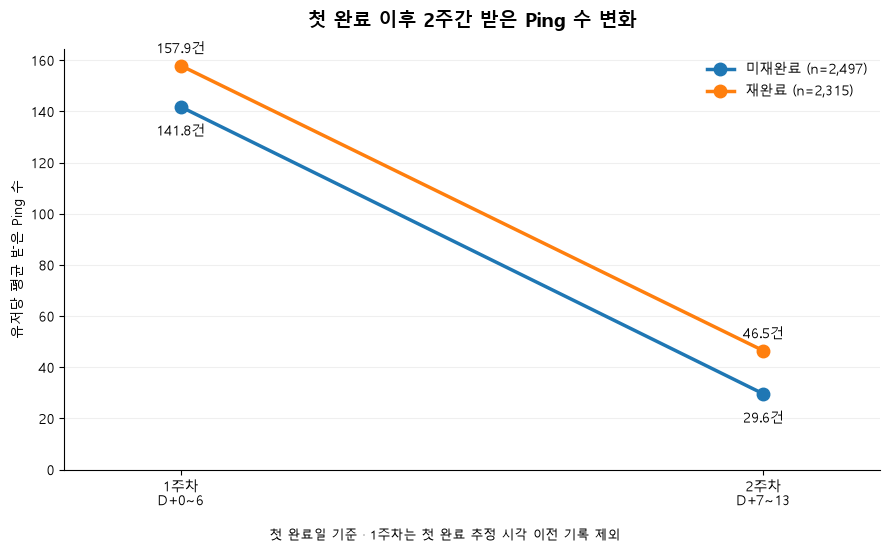

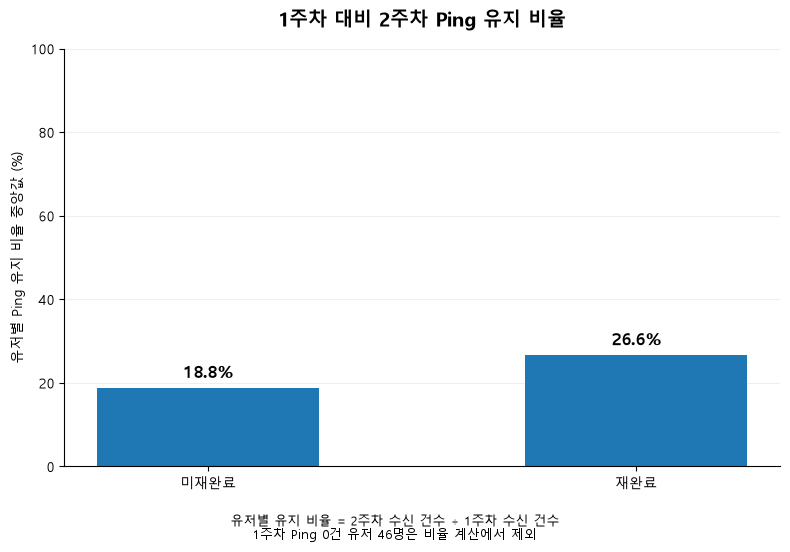

그래프 2개 저장 완료!
- ping_weekly_mean_comparison.png
- ping_weekly_retention_ratio.png


In [131]:
# [23단계] 첫 완료 이후 1~2주차 Ping 경험 시각화
# 대상: 재완료/미재완료 그룹 4,812명
# 기존 데이터프레임 수정 없음 / BigQuery 추가 조회 없음

# ------------------------------------------------------------
# 1. 시각화 설정 및 그룹별 지표 계산
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

group_order = ["미재완료", "재완료"]

plot_summary = (
    ping_2w_users
    .groupby("return_group")
    .agg(
        users=("user_id", "size"),
        mean_ping_w1=("received_pings_w1", "mean"),
        mean_ping_w2=("received_pings_w2", "mean"),
        median_ping_ratio=("ping_change_rate_pct", "median"),
    )
    .reindex(group_order)
)

# 유지 비율 = 둘째 주 Ping / 첫째 주 Ping
# 첫째 주 0건인 유저는 유지 비율을 계산할 수 없어 제외
ratio_source = ping_2w_users.loc[
    ping_2w_users["received_pings_w1"] > 0
].copy()

ratio_source["ping_retained_pct"] = (
    ratio_source["received_pings_w2"]
    / ratio_source["received_pings_w1"]
    * 100
)

ratio_summary = (
    ratio_source
    .groupby("return_group")["ping_retained_pct"]
    .median()
    .reindex(group_order)
)

# ------------------------------------------------------------
# 2. 그래프 ① 첫째 주 → 둘째 주 평균 받은 Ping 수
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.array([1, 2])

for group in group_order:
    values = plot_summary.loc[
        group, ["mean_ping_w1", "mean_ping_w2"]
    ].to_numpy(dtype=float)

    ax.plot(
        x,
        values,
        marker="o",
        markersize=9,
        linewidth=2.5,
        label=f"{group} (n={int(plot_summary.loc[group, 'users']):,})"
    )

    # 점마다 실제 평균값 표시
    offset = 7 if group == "재완료" else -12

    for week, value in zip(x, values):
        ax.annotate(
            f"{value:.1f}건",
            (week, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom" if offset > 0 else "top",
            fontsize=10
        )

ax.set_xticks([1, 2], ["1주차\nD+0~6", "2주차\nD+7~13"])
ax.set_xlim(0.8, 2.2)
ax.set_ylim(bottom=0)
ax.set_ylabel("유저당 평균 받은 Ping 수")
ax.set_title(
    "첫 완료 이후 2주간 받은 Ping 수 변화",
    fontsize=14,
    fontweight="bold",
    pad=16
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5, 0.01,
    "첫 완료일 기준 · 1주차는 첫 완료 추정 시각 이전 기록 제외",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("ping_weekly_mean_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3. 그래프 ② 유저별 Ping 유지 비율 중앙값
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))

values = ratio_summary.to_numpy(dtype=float)
bars = ax.bar(group_order, values, width=0.52)

ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in values],
    padding=5,
    fontsize=12,
    fontweight="bold"
)

ax.set_ylim(0, 100)
ax.set_ylabel("유저별 Ping 유지 비율 중앙값 (%)")
ax.set_title(
    "1주차 대비 2주차 Ping 유지 비율",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5, 0.01,
    "유저별 유지 비율 = 2주차 수신 건수 ÷ 1주차 수신 건수\n"
    "1주차 Ping 0건 유저 46명은 비율 계산에서 제외",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig("ping_weekly_retention_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

print("그래프 2개 저장 완료!")
print("- ping_weekly_mean_comparison.png")
print("- ping_weekly_retention_ratio.png")

### 확인 결과.
- 그룹별 유저당 평균 받은 ping 수를 비교해본 결과. 재완료 그룹의 ping 수가 소폭 더 높다는 것을 확인함.
- 또한, 1주차 평균 ping 수가 2주차에 들어서면서 상당한 감소가 이루어짐.
- 재완료 그룹의 2주차 ping 유지 비율이 더 높게 나타남.

# 친구 수 비교 분석 

In [132]:
# [24단계] 재완료 / 미재완료 그룹의 친구 관계 규모 비교
# - 첫 완료 시점까지의 누적 고유 친구 형성 추정 수
# - 첫 완료일 D+13 종료까지의 누적 고유 친구 형성 추정 수
# - 기존 데이터프레임 수정 없음
#
# 주의: status='A'의 updated_at을 수락 시각으로 추정함.
# 친구 삭제·재추가 이력 및 과거 실제 친구 목록은 완전히 복원할 수 없음.

# 1. 기존 그룹과 첫 완료 추정 시각 연결
friend_base = (
    group_comparison[["user_id", "return_group"]]
    .merge(
        retention_users[["user_id", "first_finished_at"]],
        on="user_id",
        how="inner",
        validate="one_to_one"
    )
    .copy()
)

friend_base["first_finished_at"] = pd.to_datetime(
    friend_base["first_finished_at"], utc=True
)

assert len(friend_base) == 4812
assert friend_base["user_id"].is_unique
assert friend_base["first_finished_at"].notna().all()

user_ids = friend_base["user_id"].astype(int).tolist()

finish_times = (
    friend_base["first_finished_at"]
    .dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")
    .tolist()
)

# 2. 수락 요청을 고유한 양방향 친구 관계로 정규화
#    같은 두 유저 사이에 수락 요청이 여러 건 있으면
#    가장 이른 updated_at을 '최초 형성 추정 시각'으로 사용
query = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(finish_time) AS first_finished_at,
        TIMESTAMP(
            DATE_ADD(DATE(TIMESTAMP(finish_time)), INTERVAL 14 DAY)
        ) AS end_of_d13
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@finish_times) AS finish_time WITH OFFSET AS idx2
        ON idx = idx2
),

accepted_pairs AS (
    SELECT
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b,
        MIN(updated_at) AS estimated_first_accepted_at
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
      AND send_user_id IS NOT NULL
      AND receive_user_id IS NOT NULL
      AND send_user_id != receive_user_id
      AND updated_at IS NOT NULL
      AND (
          send_user_id IN UNNEST(@user_ids)
          OR receive_user_id IN UNNEST(@user_ids)
      )
    GROUP BY user_a, user_b
),

friend_events AS (
    SELECT
        user_a AS user_id,
        user_b AS friend_id,
        estimated_first_accepted_at
    FROM accepted_pairs

    UNION ALL

    SELECT
        user_b AS user_id,
        user_a AS friend_id,
        estimated_first_accepted_at
    FROM accepted_pairs
)

SELECT
    w.user_id,

    COUNTIF(
        f.estimated_first_accepted_at < w.first_finished_at
    ) AS friends_at_first_finish_est,

    COUNTIF(
        f.estimated_first_accepted_at < w.end_of_d13
    ) AS friends_by_d13_est

FROM user_windows AS w
LEFT JOIN friend_events AS f
    ON w.user_id = f.user_id

GROUP BY w.user_id
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("user_ids", "INT64", user_ids),
        bigquery.ArrayQueryParameter("finish_times", "STRING", finish_times),
    ]
)

friend_counts = client.query(
    query,
    job_config=job_config
).to_dataframe()

# 3. 두 그룹에 친구 수 연결
friend_2w_users = friend_base.merge(
    friend_counts,
    on="user_id",
    how="left",
    validate="one_to_one"
)

friend_cols = [
    "friends_at_first_finish_est",
    "friends_by_d13_est",
]

friend_2w_users[friend_cols] = (
    friend_2w_users[friend_cols].fillna(0).astype(int)
)

friend_2w_users["new_friends_first_2w_est"] = (
    friend_2w_users["friends_by_d13_est"]
    - friend_2w_users["friends_at_first_finish_est"]
)

# 4. 그룹별 평균과 중앙값 비교
friend_2w_summary = (
    friend_2w_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        mean_friends_first=(
            "friends_at_first_finish_est", "mean"
        ),
        median_friends_first=(
            "friends_at_first_finish_est", "median"
        ),
        mean_friends_d13=(
            "friends_by_d13_est", "mean"
        ),
        median_friends_d13=(
            "friends_by_d13_est", "median"
        ),
        mean_new_friends=(
            "new_friends_first_2w_est", "mean"
        ),
        median_new_friends=(
            "new_friends_first_2w_est", "median"
        ),
    )
    .reset_index()
)

# 5. 결과 확인
print("분석 유저:", len(friend_2w_users))
print("고유 유저:", friend_2w_users["user_id"].nunique())
print(
    "친구 형성 추정 수가 감소한 유저:",
    int((friend_2w_users["new_friends_first_2w_est"] < 0).sum())
)

display(friend_2w_summary.round(2))

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


분석 유저: 4812
고유 유저: 4812
친구 형성 추정 수가 감소한 유저: 0


,return_group,users,mean_friends_first,median_friends_first,mean_friends_d13,median_friends_d13,mean_new_friends,median_new_friends
0,미재완료,2497,4.49,2.0,41.61,35.0,37.12,31.0
1,재완료,2315,4.01,2.0,46.82,43.0,42.82,39.0


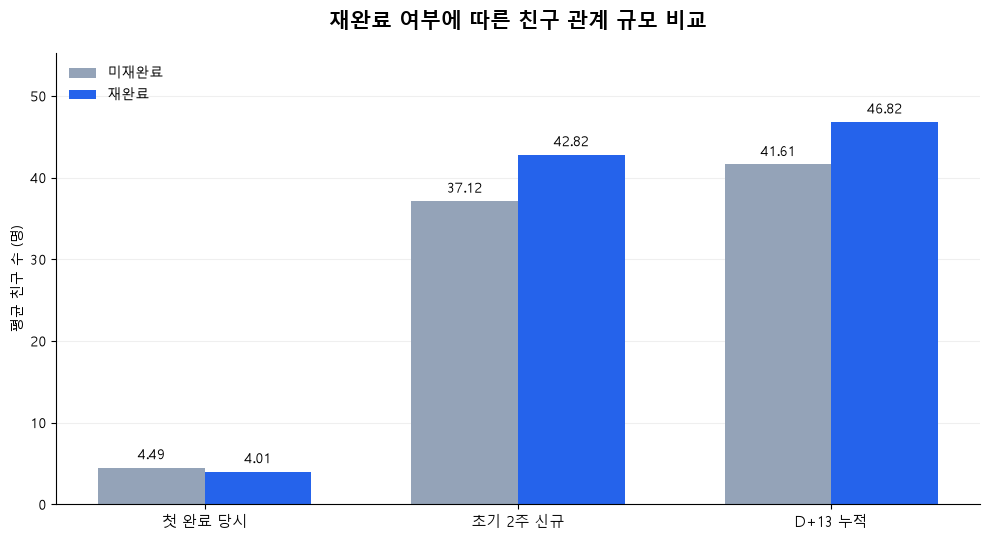

In [150]:

# [24단계] 재완료 여부에 따른 평균 친구 수 비교
# 기존 friend_2w_summary 재사용

metrics = [
    "mean_friends_first",
    "mean_new_friends",
    "mean_friends_d13"
]
labels = ["첫 완료 당시", "초기 2주 신규", "D+13 누적"]
groups = ["미재완료", "재완료"]

values = (
    friend_2w_summary
    .set_index("return_group")
    .loc[groups, metrics]
)

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, group in enumerate(groups):
    bars = ax.bar(
        x + (i - 0.5) * width,
        values.loc[group].to_numpy(),
        width,
        label=group,
        color=["#94A3B8", "#2563EB"][i]
    )
    ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("평균 친구 수 (명)")
ax.set_title(
    "재완료 여부에 따른 친구 관계 규모 비교",
    fontsize=15,
    fontweight="bold",
    pad=18
)
ax.legend(frameon=False)
ax.set_ylim(0, values.to_numpy().max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 확인 결과.
첫 질문 완료 행동 당시의 각 그룹별 평균 친구 수는 거의 차이가 없으나, 초기 2주 평균 신규 친구 수 부터 재완료 그룹의 친구 수가 높게 나타남. 따라서 최종적으로 D+13(첫 완료 당시 친구 수 + 초기 2주 신규 친구 수)도 결과 적으로 재완료 그룹에서 더 높게 나타남.

# (보류 필요)친구관계에 따른 ping 경험 비교

In [133]:
# [25단계] 친구 관계 규모별 Ping 경험 비교
# 기존 friend_2w_users, ping_2w_users 수정 없음 / BigQuery 조회 없음

# 1. 유저별 친구 수와 Ping 지표 연결
friend_ping = friend_2w_users[
    ["user_id", "return_group", "friends_by_d13_est"]
].merge(
    ping_2w_users[
        ["user_id", "received_pings_w1", "received_pings_w2"]
    ],
    on="user_id",
    how="inner",
    validate="one_to_one"
)

assert len(friend_ping) == 4812

# 2. 친구 형성 추정 수 구간 설정
# 구간별 유저 수가 지나치게 적은지는 결과에서 확인
friend_ping["friend_range"] = pd.cut(
    friend_ping["friends_by_d13_est"],
    bins=[-1, 9, 29, 49, np.inf],
    labels=["0~9명", "10~29명", "30~49명", "50명 이상"]
)

# 3. 첫째 주 Ping이 0건인 유저의 유지 비율은 결측 처리
friend_ping["ping_retained_pct"] = np.where(
    friend_ping["received_pings_w1"] > 0,
    friend_ping["received_pings_w2"]
    / friend_ping["received_pings_w1"] * 100,
    np.nan
)

# 4. 같은 친구 수 구간에서 재완료/미재완료 비교
friend_ping_summary = (
    friend_ping
    .groupby(
        ["friend_range", "return_group"],
        observed=True
    )
    .agg(
        users=("user_id", "size"),
        mean_friends=("friends_by_d13_est", "mean"),
        mean_ping_w2=("received_pings_w2", "mean"),
        median_ping_w2=("received_pings_w2", "median"),
        median_ping_retained_pct=("ping_retained_pct", "median"),
        ratio_valid_users=("ping_retained_pct", "count")
    )
    .reset_index()
)

display(friend_ping_summary.round(2))

,friend_range,return_group,users,mean_friends,mean_ping_w2,median_ping_w2,median_ping_retained_pct,ratio_valid_users
0,0~9명,미재완료,200,5.44,12.56,5.0,20.00,170
1,0~9명,재완료,103,5.81,22.33,13.0,35.92,96
2,10~29명,미재완료,829,19.87,16.68,11.0,18.68,822
3,10~29명,재완료,596,20.75,27.45,17.0,28.03,595
4,30~49명,미재완료,664,39.00,28.42,21.0,17.95,663
5,30~49명,재완료,681,38.94,40.83,31.0,26.27,681
6,50명 이상,미재완료,804,75.19,48.08,40.0,19.09,804
7,50명 이상,재완료,935,73.69,65.33,53.0,25.39,935


In [134]:
# [26단계] 첫 완료 시점 친구 수가 비슷한 유저끼리 2주차 Ping 비교
# 기존 데이터프레임 수정 없음 / BigQuery 추가 조회 없음

# 1. 첫 완료 당시 친구 수와 주차별 Ping 연결
friend_first_ping = (
    friend_2w_users[
        ["user_id", "return_group", "friends_at_first_finish_est"]
    ]
    .merge(
        ping_2w_users[
            ["user_id", "received_pings_w1", "received_pings_w2"]
        ],
        on="user_id",
        how="inner",
        validate="one_to_one"
    )
)

assert len(friend_first_ping) == 4812

# 2. 첫 완료 시점 친구 수 구간
# 첫 완료 당시 중앙값이 두 그룹 모두 2명이었으므로 작은 구간부터 구분
friend_first_ping["initial_friend_range"] = pd.cut(
    friend_first_ping["friends_at_first_finish_est"],
    bins=[-1, 0, 3, 9, np.inf],
    labels=["0명", "1~3명", "4~9명", "10명 이상"]
)

# 3. 유저별 Ping 유지 비율
# 첫째 주 0건인 유저는 비율 계산에서 제외
friend_first_ping["ping_retained_pct"] = np.where(
    friend_first_ping["received_pings_w1"] > 0,
    friend_first_ping["received_pings_w2"]
    / friend_first_ping["received_pings_w1"] * 100,
    np.nan
)

# 4. 첫 완료 당시 친구 수 구간별 그룹 비교
initial_friend_ping_summary = (
    friend_first_ping
    .groupby(
        ["initial_friend_range", "return_group"],
        observed=True
    )
    .agg(
        users=("user_id", "size"),
        mean_initial_friends=("friends_at_first_finish_est", "mean"),
        mean_ping_w1=("received_pings_w1", "mean"),
        mean_ping_w2=("received_pings_w2", "mean"),
        median_ping_w2=("received_pings_w2", "median"),
        median_ping_retained_pct=("ping_retained_pct", "median"),
        ratio_valid_users=("ping_retained_pct", "count")
    )
    .reset_index()
)

display(initial_friend_ping_summary.round(2))

,initial_friend_range,return_group,users,mean_initial_friends,mean_ping_w1,mean_ping_w2,median_ping_w2,median_ping_retained_pct,ratio_valid_users
0,0명,미재완료,753,0.00,117.05,25.61,17.0,20.00,733
1,0명,재완료,752,0.00,143.14,42.76,33.0,28.18,748
2,1~3명,미재완료,860,1.68,150.88,30.84,22.0,18.26,851
3,1~3명,재완료,809,1.70,163.51,46.89,35.0,25.81,806
4,4~9명,미재완료,505,6.05,154.95,31.55,23.0,17.74,500
5,4~9명,재완료,445,5.84,154.26,46.39,34.0,25.74,445
6,10명 이상,미재완료,379,17.69,152.74,32.02,22.0,18.26,375
7,10명 이상,재완료,309,17.15,184.31,54.40,38.0,25.11,308


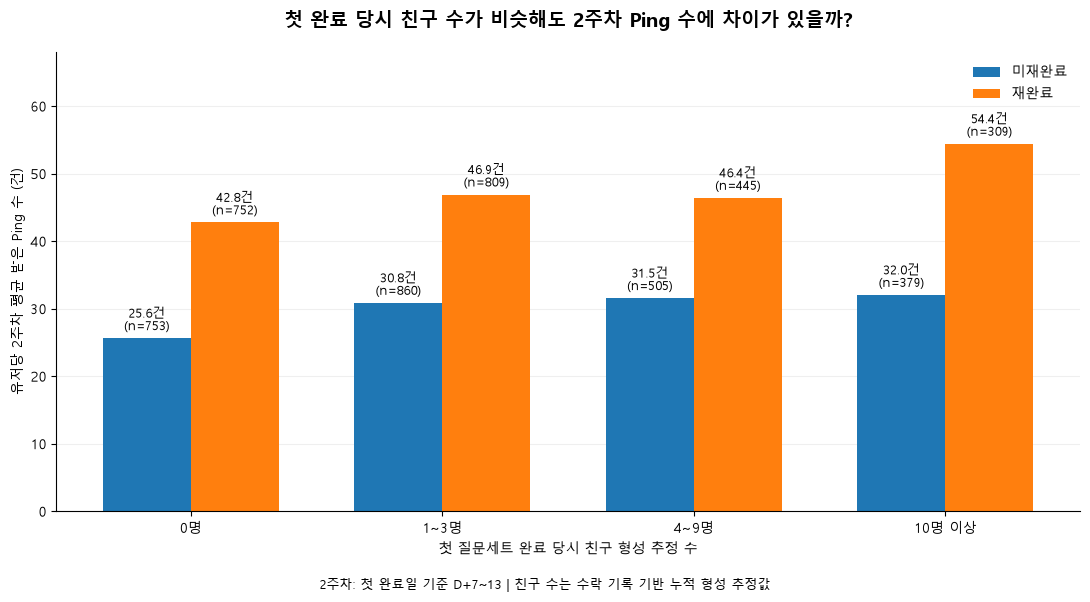

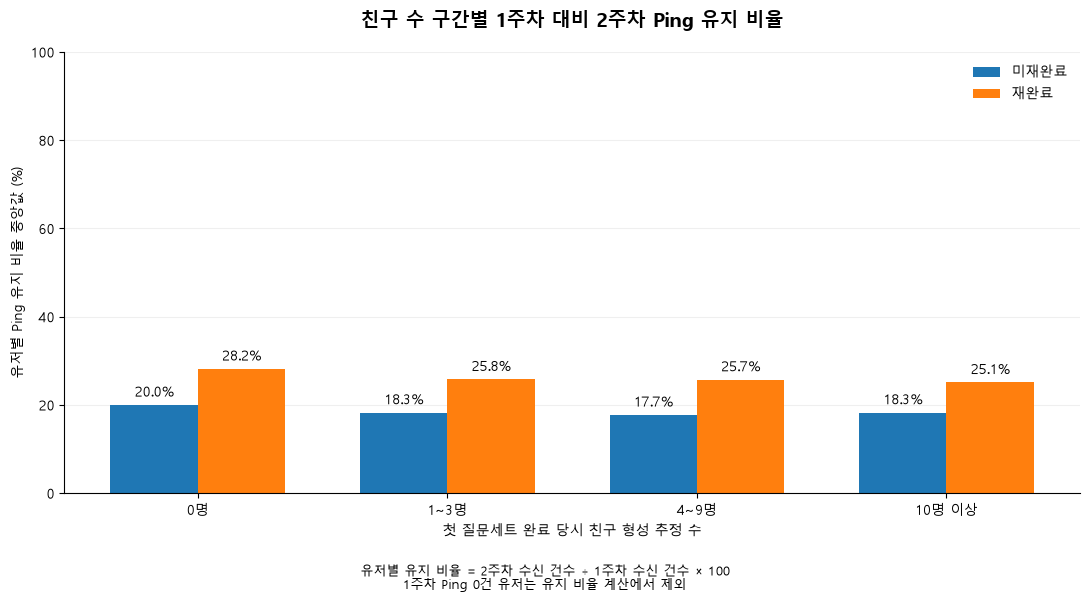

시각화 완료!
- friend_group_ping_week2.png
- friend_group_ping_retained_ratio.png


In [135]:
# [27단계] 첫 완료 당시 친구 수별 Ping 경험 시각화
# - 분석 대상: 첫 완료 추정 시각이 있는 4,812명
# - 친구 수: 첫 완료 시점까지 형성된 고유 친구 수의 추정값
# - Ping: 첫 완료일 기준 D+7~13에 받은 투표 기록
# - 기존 데이터프레임 수정 없음 / BigQuery 추가 조회 없음

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 1. 그래프용 데이터 준비
# ------------------------------------------------------------
friend_order = ["0명", "1~3명", "4~9명", "10명 이상"]
group_order = ["미재완료", "재완료"]

plot_df = initial_friend_ping_summary.copy()

# 각 구간의 값과 표본 수를 그룹별로 나란히 배치
ping_values = (
    plot_df.pivot(
        index="initial_friend_range",
        columns="return_group",
        values="mean_ping_w2"
    )
    .reindex(index=friend_order, columns=group_order)
)

ratio_values = (
    plot_df.pivot(
        index="initial_friend_range",
        columns="return_group",
        values="median_ping_retained_pct"
    )
    .reindex(index=friend_order, columns=group_order)
)

user_counts = (
    plot_df.pivot(
        index="initial_friend_range",
        columns="return_group",
        values="users"
    )
    .reindex(index=friend_order, columns=group_order)
)

assert not ping_values.isna().any().any(), "Ping 집계에 빠진 그룹이 있어요."
assert not ratio_values.isna().any().any(), "유지 비율 집계에 빠진 그룹이 있어요."

x = np.arange(len(friend_order))
width = 0.35

# ------------------------------------------------------------
# 2. 그래프 ① 친구 수 구간별 2주차 평균 받은 Ping 수
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

for i, group in enumerate(group_order):
    values = ping_values[group].to_numpy(dtype=float)

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=group
    )

    ax.bar_label(
        bars,
        labels=[
            f"{value:.1f}건\n(n={int(n):,})"
            for value, n in zip(values, user_counts[group])
        ],
        padding=4,
        fontsize=9
    )

ax.set_xticks(x, friend_order)
ax.set_xlabel("첫 질문세트 완료 당시 친구 형성 추정 수")
ax.set_ylabel("유저당 2주차 평균 받은 Ping 수 (건)")
ax.set_ylim(0, ping_values.to_numpy().max() * 1.25)
ax.set_title(
    "첫 완료 당시 친구 수가 비슷해도 2주차 Ping 수에 차이가 있을까?",
    fontsize=14,
    fontweight="bold",
    pad=18
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5, 0.01,
    "2주차: 첫 완료일 기준 D+7~13 | 친구 수는 수락 기록 기반 누적 형성 추정값",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("friend_group_ping_week2.png", dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3. 그래프 ② 친구 수 구간별 Ping 유지 비율 중앙값
#    유저별 유지 비율 = 2주차 Ping ÷ 1주차 Ping × 100
#    1주차 0건 유저는 비율 계산에서 제외
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

for i, group in enumerate(group_order):
    values = ratio_values[group].to_numpy(dtype=float)

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=group
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.1f}%" for value in values],
        padding=4,
        fontsize=10
    )

ax.set_xticks(x, friend_order)
ax.set_xlabel("첫 질문세트 완료 당시 친구 형성 추정 수")
ax.set_ylabel("유저별 Ping 유지 비율 중앙값 (%)")
ax.set_ylim(0, 100)
ax.set_title(
    "친구 수 구간별 1주차 대비 2주차 Ping 유지 비율",
    fontsize=14,
    fontweight="bold",
    pad=18
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5, 0.01,
    "유저별 유지 비율 = 2주차 수신 건수 ÷ 1주차 수신 건수 × 100\n"
    "1주차 Ping 0건 유저는 유지 비율 계산에서 제외",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig("friend_group_ping_retained_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

print("시각화 완료!")
print("- friend_group_ping_week2.png")
print("- friend_group_ping_retained_ratio.png")

### 확인 결과.

**친구 수 4~9명 구간의 비교**
첫째 주 평균 Ping은 미재완료 154.95건, 재완료 154.26건으로 비슷했지만, 둘째 주에는 각각 31.55건, 46.39건으로 차이가 나타났다.

**① 친구 수 구간을 나누어도 차이가 관찰됨**
첫 완료 당시 친구 수를 0명 / 1~3명 / 4~9명 / 10명 이상으로 나누었을 때, 네 구간 모두 재완료 그룹의 2주차 평균·중앙값 Ping 수가 높았다.

**② Ping을 받는 양뿐 아니라 유지 비율에서도 차이가 나타남**
유저별 Ping 유지 비율 중앙값 역시 네 친구 수 구간 모두 재완료 그룹에서 높았다. 즉, 둘째 주 Ping 수신의 차이가 특정 친구 수 구간 하나에서만 나타난 현상은 아니었다.

> 첫 완료 이후 두 그룹 모두 받은 Ping 수가 크게 감소했으나, 재완료 그룹은 둘째 주 수신량과 유저별 Ping 유지 비율이 상대적으로 높았다. 이 차이는 첫 완료 당시 친구 수가 비슷한 유저끼리 비교해도 관찰됐다. 따라서 향후 친구들의 실제 활동량과 관계 형성 변화를 확인해, 주변 네트워크의 활동이 Ping 수신 및 이후 재완료와 어떤 연관성을 보이는지 검증할 필요가 있다.

다음 분석 질문(친구의 활성도): 같은 발신자에게 반복해서 Ping을 받는 경험과 여러 발신자에게 받는 경험 중, 어떤 패턴이 이후 재완료 여부와 함께 나타나는가?

In [136]:
# [28단계] 첫 완료 당시 친구들의 2주차 투표 활성도 비교
# 목적: 재완료 그룹의 친구들이 실제로 더 활발하게 투표했는지 탐색
#
# 친구 관계: status='A' + 최초 updated_at 기반 추정
# 친구 집합: 내 첫 완료 추정 시각 이전에 관계가 형성된 친구
# 활동 기간: 내 첫 완료일 기준 D+7~13
# 기존 데이터프레임 수정 없음

# 1. 기존 그룹 및 첫 완료 시각 준비
friend_activity_base = friend_base[
    ["user_id", "return_group", "first_finished_at"]
].copy()

assert len(friend_activity_base) == 4812
assert friend_activity_base["user_id"].is_unique

user_ids = friend_activity_base["user_id"].astype(int).tolist()

finish_times = (
    pd.to_datetime(
        friend_activity_base["first_finished_at"], utc=True
    )
    .dt.strftime("%Y-%m-%dT%H:%M:%S.%fZ")
    .tolist()
)

# 2. 친구 관계를 복원하고, 친구들의 2주차 투표 활동 집계
query = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(finish_time) AS first_finished_at,
        TIMESTAMP_ADD(
            TIMESTAMP_TRUNC(TIMESTAMP(finish_time), DAY),
            INTERVAL 7 DAY
        ) AS week2_start,
        TIMESTAMP_ADD(
            TIMESTAMP_TRUNC(TIMESTAMP(finish_time), DAY),
            INTERVAL 14 DAY
        ) AS week2_end
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@finish_times) AS finish_time WITH OFFSET AS idx2
      ON idx = idx2
),

-- 양방향·중복 요청을 하나의 친구 관계로 정리
accepted_pairs AS (
    SELECT
        LEAST(send_user_id, receive_user_id) AS user_a,
        GREATEST(send_user_id, receive_user_id) AS user_b,
        MIN(updated_at) AS estimated_accepted_at
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest`
    WHERE status = 'A'
      AND send_user_id IS NOT NULL
      AND receive_user_id IS NOT NULL
      AND send_user_id != receive_user_id
      AND updated_at IS NOT NULL
      AND (
          send_user_id IN UNNEST(@user_ids)
          OR receive_user_id IN UNNEST(@user_ids)
      )
    GROUP BY user_a, user_b
),

friend_events AS (
    SELECT
        user_a AS user_id,
        user_b AS friend_id,
        estimated_accepted_at
    FROM accepted_pairs

    UNION ALL

    SELECT
        user_b AS user_id,
        user_a AS friend_id,
        estimated_accepted_at
    FROM accepted_pairs
),

-- 내 첫 완료 이전에 형성된 것으로 추정되는 친구만 선택
initial_friends AS (
    SELECT
        w.user_id,
        f.friend_id,
        w.week2_start,
        w.week2_end
    FROM user_windows AS w
    JOIN friend_events AS f
      ON w.user_id = f.user_id
     AND f.estimated_accepted_at < w.first_finished_at
),

-- 친구 1명당 2주차 투표 건수: 투표가 없으면 0건
friend_votes AS (
    SELECT
        f.user_id,
        f.friend_id,
        COUNT(r.user_id) AS vote_count_w2
    FROM initial_friends AS f
    LEFT JOIN `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS r
      ON r.user_id = f.friend_id
     AND r.created_at >= f.week2_start
     AND r.created_at < f.week2_end
    GROUP BY f.user_id, f.friend_id
),

-- 내 친구 수와 실제 투표한 친구 수를 유저 단위로 집계
user_activity AS (
    SELECT
        user_id,
        COUNT(*) AS initial_friends,
        COUNTIF(vote_count_w2 > 0) AS active_friends_w2,
        SUM(vote_count_w2) AS friend_votes_w2,
        AVG(vote_count_w2) AS avg_votes_per_friend_w2
    FROM friend_votes
    GROUP BY user_id
)

SELECT
    w.user_id,
    COALESCE(a.initial_friends, 0) AS initial_friends,
    COALESCE(a.active_friends_w2, 0) AS active_friends_w2,
    COALESCE(a.friend_votes_w2, 0) AS friend_votes_w2,
    a.avg_votes_per_friend_w2
FROM user_windows AS w
LEFT JOIN user_activity AS a
  ON w.user_id = a.user_id
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter("user_ids", "INT64", user_ids),
        bigquery.ArrayQueryParameter("finish_times", "STRING", finish_times),
    ]
)

friend_activity_counts = client.query(
    query, job_config=job_config
).to_dataframe()

# 3. 기존 그룹 연결
friend_activity_users = friend_activity_base.merge(
    friend_activity_counts,
    on="user_id",
    how="left",
    validate="one_to_one"
)

count_cols = [
    "initial_friends",
    "active_friends_w2",
    "friend_votes_w2",
]

friend_activity_users[count_cols] = (
    friend_activity_users[count_cols].fillna(0).astype(int)
)

# 친구가 0명인 유저는 친구 활성 비율을 계산할 수 없음
friend_activity_users["active_friend_rate"] = (
    friend_activity_users["active_friends_w2"]
    / friend_activity_users["initial_friends"].replace(0, float("nan"))
)

# 4. 그룹별 핵심 지표만 확인
friend_activity_summary = (
    friend_activity_users
    .groupby("return_group")
    .agg(
        users=("user_id", "size"),
        users_with_friends=(
            "initial_friends", lambda x: (x > 0).sum()
        ),
        mean_initial_friends=("initial_friends", "mean"),
        mean_active_friends_w2=("active_friends_w2", "mean"),
        median_active_friend_rate=("active_friend_rate", "median"),
        mean_active_friend_rate=("active_friend_rate", "mean"),
        mean_votes_per_friend_w2=("avg_votes_per_friend_w2", "mean"),
        median_votes_per_friend_w2=("avg_votes_per_friend_w2", "median"),
    )
    .reset_index()
)

for col in ["median_active_friend_rate", "mean_active_friend_rate"]:
    friend_activity_summary[col] *= 100

print("전체 분석 유저:", len(friend_activity_users))
print("고유 유저:", friend_activity_users["user_id"].nunique())
print(
    "첫 완료 당시 친구 0명:",
    int((friend_activity_users["initial_friends"] == 0).sum())
)

assert len(friend_activity_users) == 4812
assert friend_activity_users["user_id"].is_unique

display(friend_activity_summary.round(2))

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


전체 분석 유저: 4812
고유 유저: 4812
첫 완료 당시 친구 0명: 1505


,return_group,users,users_with_friends,mean_initial_friends,mean_active_friends_w2,median_active_friend_rate,mean_active_friend_rate,mean_votes_per_friend_w2,median_votes_per_friend_w2
0,미재완료,2497,1744,4.49,2.90,72.73,66.71,38.09,25.0
1,재완료,2315,1563,4.01,2.83,84.21,74.91,51.38,38.0


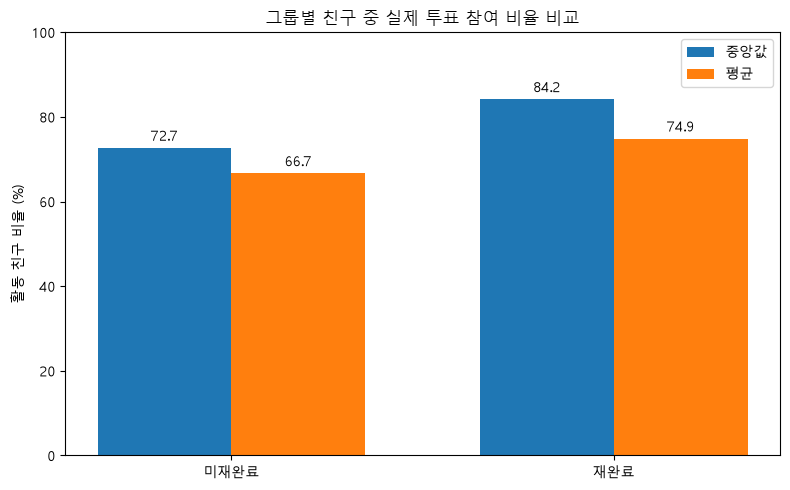

In [137]:
# 이미 요약 데이터프레임이 있으면 이 블록은 생략해도 됨
active_friend_summary = pd.DataFrame({
    "return_group": ["미재완료", "재완료"],
    "mean_initial_friends": [4.49, 4.01],
    "mean_active_friends_w2": [2.90, 2.83],
    "median_active_friend_rate": [72.73, 84.21],
    "mean_active_friend_rate": [66.71, 74.91],
    "mean_votes_per_friend_w2": [38.09, 51.38],
    "median_votes_per_friend_w2": [25.0, 38.0]
})

# x축 위치
x = np.arange(len(active_friend_summary))
width = 0.35

plt.figure(figsize=(8, 5))

# 중앙값 / 평균을 나란히 표시
bars1 = plt.bar(
    x - width/2,
    active_friend_summary["median_active_friend_rate"],
    width,
    label="중앙값"
)

bars2 = plt.bar(
    x + width/2,
    active_friend_summary["mean_active_friend_rate"],
    width,
    label="평균"
)

plt.xticks(x, active_friend_summary["return_group"])
plt.ylabel("활동 친구 비율 (%)")
plt.title("그룹별 친구 중 실제 투표 참여 비율 비교")
plt.ylim(0, 100)
plt.legend()

# 막대 위에 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

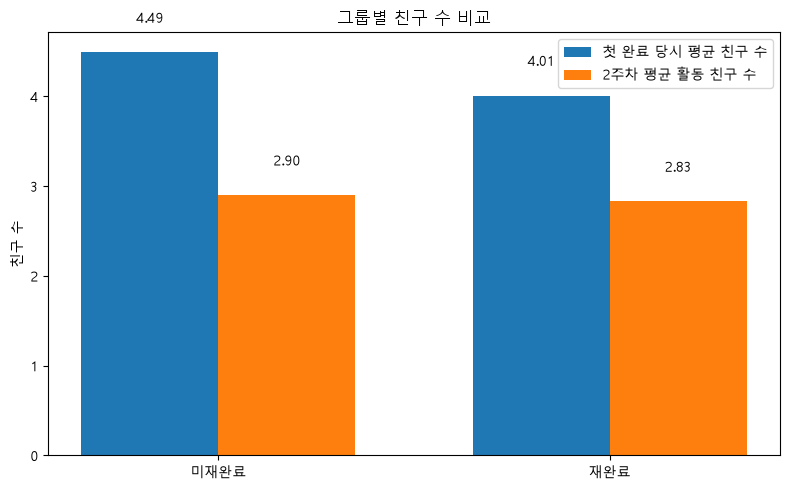

In [138]:
x = np.arange(len(active_friend_summary))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    active_friend_summary["mean_initial_friends"],
    width,
    label="첫 완료 당시 평균 친구 수"
)

bars2 = plt.bar(
    x + width/2,
    active_friend_summary["mean_active_friends_w2"],
    width,
    label="2주차 평균 활동 친구 수"
)

plt.xticks(x, active_friend_summary["return_group"])
plt.ylabel("친구 수")
plt.title("그룹별 친구 수 비교")
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.3,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

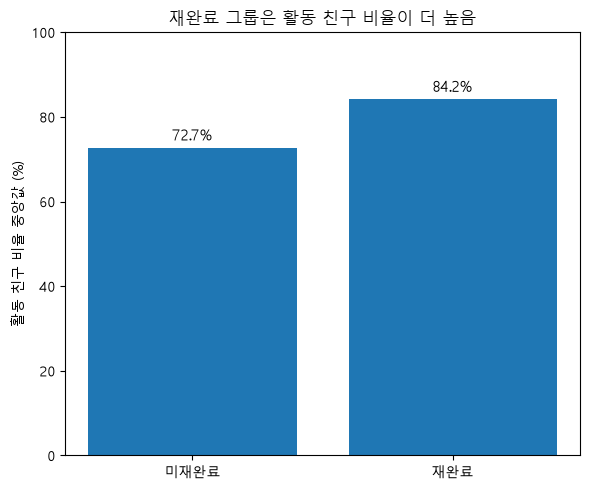

In [139]:
plt.figure(figsize=(6, 5))

bars = plt.bar(
    active_friend_summary["return_group"],
    active_friend_summary["median_active_friend_rate"]
)

plt.ylabel("활동 친구 비율 중앙값 (%)")
plt.title("재완료 그룹은 활동 친구 비율이 더 높음")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

> 첫 완료 당시 형성된 친구 수는 두 그룹에서 큰 차이가 없었으나, 재완료 그룹은 2주차 활동 친구 비율 중앙값(84.21% vs 72.73%)과 친구 1명당 투표 건수 중앙값(38건 vs 25건)이 높았다. 이는 재완료 그룹에서 관찰된 높은 2주차 Ping 수신 유지와 함께, 주변 관계자의 활동성이 이후 재완료와 연관될 가능성을 보여준다. 다만 친구의 투표가 실제로 해당 유저에게 Ping으로 전달됐는지와 인과관계는 확인되지 않았다.

In [142]:

# 30-1. 친구 후속 활동 분석용 기준 데이터 생성 및 검증

friend_followup_base = (
    group_comparison[
        ["user_id", "return_group", "returned_14_27", "active_days_14"]
    ]
    .merge(
        user_completion[["user_id", "first_finished_at"]],
        on="user_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        cohort_df[["user_id", "school_id"]],
        on="user_id",
        how="left",
        validate="one_to_one"
    )
    .copy()
)

# 첫 완료일의 자정을 기준으로 분석 기간 설정
friend_followup_base["first_finished_at"] = pd.to_datetime(
    friend_followup_base["first_finished_at"],
    utc=True,
    errors="raise"
)
friend_followup_base["d0_start"] = (
    friend_followup_base["first_finished_at"].dt.normalize()
)
friend_followup_base["d14_start"] = (
    friend_followup_base["d0_start"] + pd.Timedelta(days=14)
)
friend_followup_base["d28_start"] = (
    friend_followup_base["d0_start"] + pd.Timedelta(days=28)
)

# 1. 대상 수, 고유 ID, 필수값 확인
required_cols = [
    "user_id", "return_group", "returned_14_27",
    "active_days_14", "first_finished_at", "school_id"
]

assert len(friend_followup_base) == 4812, "분석 대상 수가 4,812명이 아닙니다."
assert friend_followup_base["user_id"].is_unique, "user_id 중복이 있습니다."
assert not friend_followup_base[required_cols].isna().any().any(), (
    "필수 컬럼에 결측값이 있습니다."
)

# 2. 그룹 이름과 재완료 0/1 라벨 일치 확인
expected_group = friend_followup_base["returned_14_27"].map({
    0: "미재완료",
    1: "재완료"
})
assert expected_group.notna().all(), "재완료 라벨에 0/1 외의 값이 있습니다."
assert friend_followup_base["return_group"].eq(expected_group).all(), (
    "그룹 이름과 재완료 라벨이 일치하지 않습니다."
)

# 3. 기존 일별 완료 기록으로 재완료 여부 교차 검증
followup_completed_ids = set(
    daily_active.loc[
        daily_active["day_offset"].between(14, 27),
        "user_id"
    ]
)

friend_followup_base["return_check_from_daily"] = (
    friend_followup_base["user_id"]
    .isin(followup_completed_ids)
    .astype(int)
)

mismatch_count = (
    friend_followup_base["returned_14_27"]
    != friend_followup_base["return_check_from_daily"]
).sum()

print(f"분석 대상: {len(friend_followup_base):,}명")
print(f"고유 학교 수: {friend_followup_base['school_id'].nunique():,}개")
print(f"기존 재완료 판정과 일별 기록 불일치: {mismatch_count:,}명")

assert mismatch_count == 0, "재완료 판정이 일별 기록과 다릅니다."

# 4. 그룹별 분석 대상과 관측에 필요한 날짜 확인
display(
    friend_followup_base.groupby("return_group").agg(
        users=("user_id", "nunique"),
        schools=("school_id", "nunique"),
        first_finish_min=("first_finished_at", "min"),
        first_finish_max=("first_finished_at", "max"),
        latest_required_end=("d28_start", "max")
    ).reset_index()
)

display(friend_followup_base.head(3))


분석 대상: 4,812명
고유 학교 수: 10개
기존 재완료 판정과 일별 기록 불일치: 0명


,return_group,users,schools,first_finish_min,first_finish_max,latest_required_end
0,미재완료,2497,10,2023-04-28 12:29:33+00:00,2024-03-19 12:57:17+00:00,2024-04-16 00:00:00+00:00
1,재완료,2315,10,2023-04-28 12:30:34+00:00,2023-06-20 00:59:39+00:00,2023-07-18 00:00:00+00:00


,user_id,return_group,returned_14_27,active_days_14,first_finished_at,school_id,d0_start,d14_start,d28_start,return_check_from_daily
0,1177676,재완료,1,13,2023-05-12 13:22:43+00:00,5491,2023-05-12 00:00:00+00:00,2023-05-26 00:00:00+00:00,2023-06-09 00:00:00+00:00,1
1,1550300,미재완료,0,11,2023-05-30 05:48:12+00:00,4516,2023-05-30 00:00:00+00:00,2023-06-13 00:00:00+00:00,2023-06-27 00:00:00+00:00,0
2,895699,재완료,1,3,2023-05-06 08:58:32+00:00,352,2023-05-06 00:00:00+00:00,2023-05-20 00:00:00+00:00,2023-06-03 00:00:00+00:00,1


In [143]:

# 30-2. 그룹별 첫 완료 시기 및 투표 데이터 관측기간 점검

record_times = pd.to_datetime(
    records["created_at"],
    utc=True,
    errors="raise"
)

record_min = record_times.min()
record_max = record_times.max()

# 유저별 후속 2주 관측에 필요한 종료 시점이
# 전체 투표 기록의 마지막 시각보다 늦은지 확인
coverage_check = friend_followup_base.assign(
    after_record_max=friend_followup_base["d28_start"] > record_max,
    first_finish_month=(
        friend_followup_base["first_finished_at"].dt.strftime("%Y-%m")
    )
)

print("투표 기록 최초 시각:", record_min)
print("투표 기록 최종 시각:", record_max)
print(
    "후속기간 종료 경계가 투표 기록 최종 시각보다 늦은 유저:",
    f"{coverage_check['after_record_max'].sum():,}명"
)

print("\n[그룹별 관측기간 점검]")
display(
    coverage_check.groupby("return_group").agg(
        users=("user_id", "nunique"),
        first_finish_min=("first_finished_at", "min"),
        first_finish_max=("first_finished_at", "max"),
        latest_required_end=("d28_start", "max"),
        users_after_record_max=("after_record_max", "sum")
    ).reset_index()
)

print("\n[첫 완료 월별 그룹 분포]")
display(
    coverage_check.pivot_table(
        index="first_finish_month",
        columns="return_group",
        values="user_id",
        aggfunc="nunique",
        fill_value=0
    )
)


투표 기록 최초 시각: 2023-04-28 12:27:49+00:00
투표 기록 최종 시각: 2024-05-08 01:36:18+00:00
후속기간 종료 경계가 투표 기록 최종 시각보다 늦은 유저: 0명

[그룹별 관측기간 점검]


,return_group,users,first_finish_min,first_finish_max,latest_required_end,users_after_record_max
0,미재완료,2497,2023-04-28 12:29:33+00:00,2024-03-19 12:57:17+00:00,2024-04-16 00:00:00+00:00,0
1,재완료,2315,2023-04-28 12:30:34+00:00,2023-06-20 00:59:39+00:00,2023-07-18 00:00:00+00:00,0



[첫 완료 월별 그룹 분포]


return_group,미재완료,재완료
first_finish_month,,
2023-04,163,174
2023-05,2298,2138
2023-06,30,3
2023-07,3,0
2023-09,1,0
2023-11,1,0
2024-03,1,0


In [144]:

# 30-3. 분석 대상과 연결된 친구 관계를 한 번만 조회

cohort_id_sql = ", ".join(
    map(str, friend_followup_base["user_id"].astype("int64").tolist())
)
latest_friend_cutoff = friend_followup_base["d14_start"].max().isoformat()

friend_followup_sql = f"""
WITH cohort_ids AS (
    SELECT user_id
    FROM UNNEST([{cohort_id_sql}]) AS user_id
),
cohort_friend_requests AS (
    SELECT
        c.user_id,
        IF(
            fr.send_user_id = c.user_id,
            fr.receive_user_id,
            fr.send_user_id
        ) AS friend_id,
        fr.updated_at
    FROM `sns-analysis-prj.sns_analysis.accounts_friendrequest` AS fr
    JOIN cohort_ids AS c
        ON c.user_id = fr.send_user_id
        OR c.user_id = fr.receive_user_id
    WHERE fr.status = 'A'
      AND fr.send_user_id IS NOT NULL
      AND fr.receive_user_id IS NOT NULL
      AND fr.updated_at IS NOT NULL
      AND fr.send_user_id != fr.receive_user_id
      AND fr.updated_at < TIMESTAMP('{latest_friend_cutoff}')
)
SELECT
    user_id,
    friend_id,
    MIN(updated_at) AS estimated_friend_at
FROM cohort_friend_requests
GROUP BY user_id, friend_id
"""

friend_followup_edges = client.query(
    friend_followup_sql
).to_dataframe()

# 원본 관계를 덮어쓰지 않고, 새 분석용 관계 목록만 검증
assert not friend_followup_edges[
    ["user_id", "friend_id", "estimated_friend_at"]
].isna().any().any(), "친구 관계 필수값에 결측이 있습니다."

assert not friend_followup_edges.duplicated(
    ["user_id", "friend_id"]
).any(), "유저-친구 쌍에 중복이 있습니다."

assert set(friend_followup_edges["user_id"]).issubset(
    set(friend_followup_base["user_id"])
), "분석 대상 외 유저가 포함되었습니다."

print(f"조회된 유저-친구 관계: {len(friend_followup_edges):,}건")
print(
    "친구 관계가 조회된 분석 유저:",
    f"{friend_followup_edges['user_id'].nunique():,}명"
)
print(
    "친구 관계 형성 추정시각 범위:",
    friend_followup_edges["estimated_friend_at"].min(),
    "~",
    friend_followup_edges["estimated_friend_at"].max()
)
print("조회에 적용한 시각 상한:", latest_friend_cutoff)

display(friend_followup_edges.head(3))


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


조회된 유저-친구 관계: 219,966건
친구 관계가 조회된 분석 유저: 4,795명
친구 관계 형성 추정시각 범위: 2023-04-24 04:23:46+00:00 ~ 2024-03-17 08:25:52+00:00
조회에 적용한 시각 상한: 2024-04-02T00:00:00+00:00


,user_id,friend_id,estimated_friend_at
0,876941,876324,2023-05-05 05:14:03+00:00
1,893324,874473,2023-05-06 05:43:28+00:00
2,1347116,1237036,2023-05-17 11:57:19+00:00


In [145]:

# 30-4. 초기 2주 친구 목록 확정 및 기존 친구 수 집계 대조

friend_followup_initial = friend_followup_edges.merge(
    friend_followup_base[
        ["user_id", "first_finished_at", "d14_start"]
    ],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

friend_followup_initial["estimated_friend_at"] = pd.to_datetime(
    friend_followup_initial["estimated_friend_at"],
    utc=True,
    errors="raise"
)

# 유저별 D+14 시작 전까지 형성된 친구만 포함
friend_followup_initial = friend_followup_initial.loc[
    friend_followup_initial["estimated_friend_at"]
    < friend_followup_initial["d14_start"]
].copy()

# 첫 완료 당시 친구 / 첫 완료 이후 새로 형성된 친구 구분
friend_followup_initial["is_new_friend"] = (
    friend_followup_initial["estimated_friend_at"]
    >= friend_followup_initial["first_finished_at"]
)

# 초기 친구 수를 유저별로 집계하고 기존 24단계 결과와 비교
friend_count_check = (
    friend_followup_initial.groupby("user_id")
    .agg(
        friends_by_d13_check=("friend_id", "nunique"),
        new_friends_check=("is_new_friend", "sum")
    )
    .reindex(friend_followup_base["user_id"], fill_value=0)
    .rename_axis("user_id")
    .reset_index()
    .merge(
        friend_2w_users[
            [
                "user_id",
                "friends_by_d13_est",
                "new_friends_first_2w_est"
            ]
        ],
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

friend_count_check["d13_mismatch"] = (
    friend_count_check["friends_by_d13_check"]
    != friend_count_check["friends_by_d13_est"]
)
friend_count_check["new_friend_mismatch"] = (
    friend_count_check["new_friends_check"]
    != friend_count_check["new_friends_first_2w_est"]
)

print(f"초기 2주 유저-친구 관계: {len(friend_followup_initial):,}건")
print(
    "초기 친구 0명:",
    f"{(friend_count_check['friends_by_d13_check'] == 0).sum():,}명"
)
print("D+13 친구 수 불일치:", friend_count_check["d13_mismatch"].sum(), "명")
print("신규 친구 수 불일치:", friend_count_check["new_friend_mismatch"].sum(), "명")

display(
    friend_count_check.loc[
        friend_count_check["d13_mismatch"]
        | friend_count_check["new_friend_mismatch"]
    ].head(10)
)


초기 2주 유저-친구 관계: 212,295건
초기 친구 0명: 20명
D+13 친구 수 불일치: 0 명
신규 친구 수 불일치: 0 명


,user_id,friends_by_d13_check,new_friends_check,friends_by_d13_est,new_friends_first_2w_est,d13_mismatch,new_friend_mismatch


In [146]:

# 30-5. 초기 친구가 현재 보유한 투표 데이터에 포함되는지 점검
# 기존 데이터프레임 수정 및 BigQuery 조회 없음

initial_friend_ids = friend_followup_initial["friend_id"].drop_duplicates()
record_user_ids = pd.Index(records["user_id"].dropna().unique())
cohort_user_ids = pd.Index(cohort_df["user_id"].dropna().unique())

friend_coverage_check = friend_followup_initial[
    ["user_id", "friend_id"]
].merge(
    friend_followup_base[["user_id", "return_group"]],
    on="user_id",
    how="left",
    validate="many_to_one"
)

friend_coverage_check["in_records"] = (
    friend_coverage_check["friend_id"].isin(record_user_ids)
)
friend_coverage_check["in_cohort"] = (
    friend_coverage_check["friend_id"].isin(cohort_user_ids)
)

print(f"초기 친구 고유 ID: {len(initial_friend_ids):,}명")
print(f"기존 records의 고유 투표 유저: {len(record_user_ids):,}명")
print(
    "초기 친구 중 기존 records에 등장한 친구:",
    f"{initial_friend_ids.isin(record_user_ids).sum():,}명"
)
print(
    "초기 친구 중 10개 학교 코호트에 속한 친구:",
    f"{initial_friend_ids.isin(cohort_user_ids).sum():,}명"
)

print("\n[그룹별 초기 친구 관계의 기존 데이터 포함 여부]")
display(
    friend_coverage_check.groupby("return_group").agg(
        friend_relationships=("friend_id", "size"),
        relationships_in_records=("in_records", "sum"),
        relationships_in_cohort=("in_cohort", "sum")
    ).assign(
        records_coverage_pct=lambda x: (
            x["relationships_in_records"] / x["friend_relationships"] * 100
        ).round(2),
        cohort_coverage_pct=lambda x: (
            x["relationships_in_cohort"] / x["friend_relationships"] * 100
        ).round(2)
    ).reset_index()
)


초기 친구 고유 ID: 14,781명
기존 records의 고유 투표 유저: 4,849명
초기 친구 중 기존 records에 등장한 친구: 4,784명
초기 친구 중 10개 학교 코호트에 속한 친구: 4,917명

[그룹별 초기 친구 관계의 기존 데이터 포함 여부]


,return_group,friend_relationships,relationships_in_records,relationships_in_cohort,records_coverage_pct,cohort_coverage_pct
0,미재완료,103903,88154,88662,84.84,85.33
1,재완료,108392,90622,91175,83.61,84.12


## 30. 초기 친구의 후속 활동 지속률 분석 — 보류

### 1. 분석 목적

첫 질문세트 완료를 기준으로 **초기 2주(D+0~13)에 형성된 친구들이 다음 2주(D+14~27)에도 활동을 이어가는지** 확인하고, 이를 재완료 그룹과 미재완료 그룹 간 비교하고자 했다.

이를 통해 주변 친구의 활동 지속성과 본인의 질문세트 재완료 사이에 연관성이 있는지 탐색하려 했다.

### 2. 분석 대상 및 데이터 검증

- **분석 대상:** 10개 학교의 유저 4,812명
  - 재완료: 2,315명
  - 미재완료: 2,497명
- **재완료 기준:** 첫 완료일로부터 D+14~27에 질문세트를 다시 완료했는지 여부
- **초기 친구 관계:** 유저별 D+14 시작 이전에 형성된 것으로 추정되는 친구 관계 212,295건
- **초기 친구가 0명인 유저:** 20명

기존 분석의 D+13 누적 친구 수 및 초기 2주 신규 친구 수와 재집계 결과를 비교한 결과, **두 지표 모두 불일치 유저가 0명**으로 확인되었다.

또한 전체 투표 기록의 최종 시각은 2024-05-08이며, 분석 대상 4,812명 모두 D+28 시작 시각이 이보다 앞선다. 다만 전체 기록의 날짜 범위만으로 개별 친구의 활동 기록이 완전하게 수집되었다고 보장할 수는 없다.

### 3. 초기 친구의 투표 기록 포함 여부

| 구분 | 결과 |
|---|---:|
| 초기 친구 고유 유저 수 | 14,781명 |
| 기존 `records`에 투표 이력이 있는 초기 친구 | 4,784명 |
| 기존 `records`에 투표 이력이 확인되지 않는 초기 친구 | 9,997명 |
| 초기 친구 중 10개 학교 코호트에 포함된 친구 | 4,917명 |

초기 친구 관계 건수를 기준으로 기존 `records`와 연결되는 비율은 미재완료 그룹 **84.84%**, 재완료 그룹 **83.61%**였다.

*고유 친구 수 기준의 포함 현황과 친구 관계 건수 기준의 포함 비율은 집계 단위가 다르므로 구분하여 해석해야 한다.*

### 4. 분석 보류 사유

현재 보유한 `records`에는 초기 친구 14,781명 중 4,784명의 투표 이력만 확인된다. **투표 이력이 확인되지 않는 친구를 실제 비활동 유저라고 단정할 수 없다.** 분석 대상인 10개 학교 외부 친구의 투표 기록이 수집 범위에서 누락되었을 가능성이 있기 때문이다.

따라서 현재 데이터만으로 다음 2주에 투표한 친구 수를 집계하면, **실제 활동하지 않은 친구와 활동했지만 기록이 관측되지 않은 친구를 구별할 수 없다.** 이 상태에서 활동 지속률을 산출하면 비율이 왜곡될 수 있으며, 그룹 간 차이 역시 실제 친구 활동의 차이인지 데이터 관측 범위의 차이인지 판단하기 어렵다.

또한 기존 `records`에 한 번이라도 등장한 친구라고 해도, 해당 친구의 D+14~27 투표 기록이 완전하게 수집되었다는 뜻은 아니다.

### 5. 결론 및 향후 과제

**초기 친구 관계 목록의 구성과 기존 친구 수 집계의 일치 여부까지 검증했으나, 친구별 후속 활동을 충분히 관측할 수 있는지 확인되지 않아 활동 지속률 비교는 진행하지 않았다.**

향후 친구 전체의 투표 기록 수집 범위와 관측기간을 확인할 수 있다면, 초기 2주에 활동한 친구 중 다음 2주에도 활동한 친구의 비율을 산출하고 그룹별 차이를 다시 분석할 수 있다.

*본 단계에서는 친구 활동 지속률이나 그에 따른 재완료 효과에 대한 분석 결과를 도출하지 않았다.*

In [147]:

# 30-6. 투표 원본의 발신자·수신자 코호트 포함 여부 확인

cohort_ids_sql = ", ".join(
    map(str, cohort_df["user_id"].dropna().astype("int64").unique())
)

vote_scope_sql = f"""
WITH cohort_ids AS (
    SELECT user_id
    FROM UNNEST([{cohort_ids_sql}]) AS user_id
),
classified AS (
    SELECT
        r.user_id,
        r.chosen_user_id,
        CASE
            WHEN r.user_id IS NULL THEN '발신자 ID 결측'
            WHEN r.chosen_user_id IS NULL THEN '수신자 ID 결측'
            WHEN sender.user_id IS NOT NULL
             AND receiver.user_id IS NOT NULL THEN '발신자·수신자 모두 목록 내'
            WHEN sender.user_id IS NOT NULL THEN '발신자만 목록 내'
            WHEN receiver.user_id IS NOT NULL THEN '수신자만 목록 내'
            ELSE '발신자·수신자 모두 목록 밖'
        END AS scope_type
    FROM `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS r
    LEFT JOIN cohort_ids AS sender
        ON r.user_id = sender.user_id
    LEFT JOIN cohort_ids AS receiver
        ON r.chosen_user_id = receiver.user_id
)
SELECT
    scope_type,
    COUNT(*) AS vote_records,
    COUNT(DISTINCT user_id) AS unique_senders,
    COUNT(DISTINCT chosen_user_id) AS unique_receivers
FROM classified
GROUP BY scope_type
ORDER BY vote_records DESC
"""

vote_scope_summary = client.query(vote_scope_sql).to_dataframe()

display(vote_scope_summary)
print(
    "원본 투표 기록 총건수:",
    f"{vote_scope_summary['vote_records'].sum():,}건"
)


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,scope_type,vote_records,unique_senders,unique_receivers
0,발신자·수신자 모두 목록 내,1051824,4834,5010
1,발신자만 목록 내,165734,3862,10416


원본 투표 기록 총건수: 1,217,558건


## 투표 기록 테이블의 한계
- 원본  투표 기록 총 건수 1,217,558건은 모두 발신자가 10개 학교에 해당하는 유저.

> 즉, 외부 학교 유저가 10개 학교에 해당하는 표본 5090명의 유저들을 선택한 기록은 존재하지 않는다. 따라서, 받은 ping수의 차이 또한 표본인 유저들이 투표한 기록만 존재하는 것으로 외부 학교 유저들이 표본 유저들을 투표한 경우 기록이 존재하지 않기 때문에 과소 집계를 원인으로 왜곡된 결과를 초래할 수 있다.

# 신고 관련 비교 분석

In [148]:
friend_followup_base

,user_id,return_group,returned_14_27,active_days_14,first_finished_at,school_id,d0_start,d14_start,d28_start,return_check_from_daily
0,1177676,재완료,1,13,2023-05-12 13:22:43+00:00,5491,2023-05-12 00:00:00+00:00,2023-05-26 00:00:00+00:00,2023-06-09 00:00:00+00:00,1
1,1550300,미재완료,0,11,2023-05-30 05:48:12+00:00,4516,2023-05-30 00:00:00+00:00,2023-06-13 00:00:00+00:00,2023-06-27 00:00:00+00:00,0
2,895699,재완료,1,3,2023-05-06 08:58:32+00:00,352,2023-05-06 00:00:00+00:00,2023-05-20 00:00:00+00:00,2023-06-03 00:00:00+00:00,1
3,994302,재완료,1,10,2023-05-08 07:27:10+00:00,4516,2023-05-08 00:00:00+00:00,2023-05-22 00:00:00+00:00,2023-06-05 00:00:00+00:00,1
4,1365450,재완료,1,9,2023-05-18 05:09:47+00:00,5372,2023-05-18 00:00:00+00:00,2023-06-01 00:00:00+00:00,2023-06-15 00:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...,...
4807,1165253,재완료,1,2,2023-05-12 11:25:20+00:00,1478,2023-05-12 00:00:00+00:00,2023-05-26 00:00:00+00:00,2023-06-09 00:00:00+00:00,1
4808,921963,미재완료,0,5,2023-05-08 10:58:50+00:00,1478,2023-05-08 00:00:00+00:00,2023-05-22 00:00:00+00:00,2023-06-05 00:00:00+00:00,0
4809,871350,재완료,1,8,2023-05-02 23:07:39+00:00,4516,2023-05-02 00:00:00+00:00,2023-05-16 00:00:00+00:00,2023-05-30 00:00:00+00:00,1
4810,907442,미재완료,0,4,2023-05-06 11:24:15+00:00,352,2023-05-06 00:00:00+00:00,2023-05-20 00:00:00+00:00,2023-06-03 00:00:00+00:00,0


In [ ]:

# 31-1. 초기 2주(D+0~13) 질문 신고 횟수 비교
# 기존 데이터프레임 수정 없음 / 라이브러리 재import 없음

report_user_ids = ", ".join(
    map(str, friend_followup_base["user_id"].astype("int64"))
)
report_start = friend_followup_base["d0_start"].min().isoformat()
report_end = friend_followup_base["d14_start"].max().isoformat()

# 전체 신고 원본 대신 필요한 유저·기간의 일별 건수만 조회
report_daily_sql = f"""
SELECT
    user_id,
    DATE(created_at, 'UTC') AS report_date,
    COUNT(*) AS report_count
FROM `sns-analysis-prj.sns_analysis.polls_questionreport`
WHERE user_id IN ({report_user_ids})
  AND created_at >= TIMESTAMP('{report_start}')
  AND created_at < TIMESTAMP('{report_end}')
GROUP BY user_id, report_date
"""

report_daily = client.query(report_daily_sql).to_dataframe()

# 각 유저의 첫 완료일을 기준으로 초기 2주 신고만 선택
report_daily["report_date"] = pd.to_datetime(
    report_daily["report_date"], utc=True
)

report_in_window = report_daily.merge(
    friend_followup_base[["user_id", "d0_start", "d14_start"]],
    on="user_id",
    how="inner",
    validate="many_to_one"
)

report_in_window = report_in_window.loc[
    (report_in_window["report_date"] >= report_in_window["d0_start"])
    & (report_in_window["report_date"] < report_in_window["d14_start"])
]

# 유저별 집계: 신고하지 않은 유저도 0건으로 포함
report_14_users = friend_followup_base[
    ["user_id", "return_group"]
].merge(
    report_in_window.groupby("user_id", as_index=False)["report_count"].sum(),
    on="user_id",
    how="left",
    validate="one_to_one"
)

report_14_users["report_count"] = (
    report_14_users["report_count"].fillna(0).astype(int)
)

report_14_summary = (
    report_14_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        reporters=("report_count", lambda x: (x > 0).sum()),
        total_reports=("report_count", "sum"),
        mean_reports=("report_count", "mean"),
        median_reports=("report_count", "median"),
        max_reports=("report_count", "max")
    )
    .assign(
        reporter_rate_pct=lambda x: (
            x["reporters"] / x["users"] * 100
        ).round(2)
    )
    .reset_index()
)

assert len(report_14_users) == 4812
assert report_14_users["user_id"].is_unique

print(f"초기 2주 신고 총건수: {report_14_users['report_count'].sum():,}건")
print(f"신고 경험 유저: {(report_14_users['report_count'] > 0).sum():,}명")
display(report_14_summary)


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


초기 2주 신고 총건수: 354건
신고 경험 유저: 210명


,return_group,users,reporters,total_reports,mean_reports,median_reports,max_reports,reporter_rate_pct
0,미재완료,2497,93,171,0.068482,0.0,20,3.72
1,재완료,2315,117,183,0.079050,0.0,10,5.05


## 확인 결과.

초기에는 질문 신고 경험이 재완료와 부정적인 관계를 보일 것으로 예상했으나, 실제로는 재완료 그룹에서 신고 경험자 비율이 소폭 높게 나타났다. 다만 그룹 간 질문 이용량이 달라 신고 기회의 차이가 반영되었을 수 있으므로, 이를 질문 품질이나 불쾌한 경험의 영향으로 직접 해석하기는 어렵다.

# 초기 친구들이 같은 학교 친구들이 많을까?

In [151]:

# 32-1. 초기 친구의 학교 정보 조회
# 기존 데이터프레임 수정 없음 / 친구 관계 재조회 없음

friend_ids = (
    friend_followup_initial["friend_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

school_sql = """
SELECT
    u.id AS friend_id,
    u.group_id AS friend_group_id,
    g.school_id AS friend_school_id
FROM `sns-analysis-prj.sns_analysis.accounts_user` AS u
LEFT JOIN `sns-analysis-prj.sns_analysis.accounts_group` AS g
    ON u.group_id = g.id
WHERE u.id IN UNNEST(@friend_ids)
"""

school_job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "friend_ids", "INT64", friend_ids
        )
    ]
)

friend_school_map = client.query(
    school_sql,
    job_config=school_job_config
).to_dataframe()

# 조회 결과 검증
assert friend_school_map["friend_id"].is_unique, (
    "친구 ID가 중복되어 있습니다. 학교 정보 연결 구조를 확인해야 합니다."
)

print(f"조회 대상 친구: {len(friend_ids):,}명")
print(f"유저 정보가 조회된 친구: {len(friend_school_map):,}명")
print(
    "학교 정보가 확인된 친구:",
    f"{friend_school_map['friend_school_id'].notna().sum():,}명"
)
print(
    "학교 정보가 없는 친구:",
    f"{friend_school_map['friend_school_id'].isna().sum():,}명"
)
print(
    "유저 정보 자체가 조회되지 않은 친구:",
    f"{len(set(friend_ids) - set(friend_school_map['friend_id'])):,}명"
)

display(friend_school_map.head(5))


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


조회 대상 친구: 14,781명
유저 정보가 조회된 친구: 14,781명
학교 정보가 확인된 친구: 14,781명
학교 정보가 없는 친구: 0명
유저 정보 자체가 조회되지 않은 친구: 0명


,friend_id,friend_group_id,friend_school_id
0,925257,18945,1464
1,1419464,58721,4425
2,865295,2273,2529
3,869468,1036,300
4,877875,10680,500


In [152]:

# 32-2. 초기 2주 친구의 학교 소속 비교
# 기존 데이터프레임 수정 없음 / BigQuery 조회 없음

# 1. 친구 목록에 본인과 친구의 학교 정보 연결
friend_school_edges = (
    friend_followup_initial[["user_id", "friend_id"]]
    .merge(
        friend_followup_base[["user_id", "school_id", "return_group"]],
        on="user_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        friend_school_map[["friend_id", "friend_school_id"]],
        on="friend_id",
        how="left",
        validate="many_to_one"
    )
)

assert friend_school_edges[
    ["school_id", "friend_school_id", "return_group"]
].notna().all().all(), "학교 또는 그룹 정보에 결측이 있습니다."

friend_school_edges["same_school"] = (
    friend_school_edges["school_id"]
    == friend_school_edges["friend_school_id"]
)

# 2. 유저별 친구 수 집계
friend_school_users = (
    friend_school_edges.groupby("user_id")
    .agg(
        same_school_friends=("same_school", "sum"),
        total_friends=("friend_id", "nunique")
    )
    .reset_index()
)

friend_school_users["other_school_friends"] = (
    friend_school_users["total_friends"]
    - friend_school_users["same_school_friends"]
)

# 친구가 0명인 유저도 분석 대상에 포함
friend_school_users = (
    friend_followup_base[["user_id", "return_group"]]
    .merge(
        friend_school_users,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

count_cols = [
    "same_school_friends",
    "other_school_friends",
    "total_friends"
]

friend_school_users[count_cols] = (
    friend_school_users[count_cols].fillna(0).astype(int)
)

# 친구가 없는 유저의 비율은 0%가 아니라 결측으로 유지
friend_school_users["same_school_pct"] = (
    friend_school_users["same_school_friends"]
    .div(friend_school_users["total_friends"].replace(0, float("nan")))
    * 100
)

# 3. 기존 D+13 친구 수와 대조
friend_count_reference = friend_2w_users.set_index("user_id")[
    "friends_by_d13_est"
]

mismatch = (
    friend_school_users["total_friends"].to_numpy()
    != friend_school_users["user_id"]
       .map(friend_count_reference)
       .to_numpy()
).sum()

assert len(friend_school_users) == 4812
assert friend_school_users["user_id"].is_unique

print("D+13 기존 친구 수 집계와 불일치:", mismatch, "명")
print(
    "친구가 0명인 유저:",
    (friend_school_users["total_friends"] == 0).sum(), "명"
)

# 4. 그룹별 결과
friend_school_summary = (
    friend_school_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        mean_same_school=("same_school_friends", "mean"),
        median_same_school=("same_school_friends", "median"),
        mean_other_school=("other_school_friends", "mean"),
        median_other_school=("other_school_friends", "median"),
        mean_same_school_pct=("same_school_pct", "mean"),
        median_same_school_pct=("same_school_pct", "median")
    )
    .reset_index()
)

display(friend_school_summary.round(2))


D+13 기존 친구 수 집계와 불일치: 0 명
친구가 0명인 유저: 20 명


,return_group,users,mean_same_school,median_same_school,mean_other_school,median_other_school,mean_same_school_pct,median_same_school_pct
0,미재완료,2497,35.41,29.0,6.20,3.0,86.05,92.31
1,재완료,2315,39.26,34.0,7.57,4.0,84.59,90.51


### 확인결과

초기 친구의 학교 소속과 재완료 비교

첫 질문세트 완료일 기준 초기 2주(D+0~13) 종료 시점의 친구 관계를 같은 학교와 다른 학교로 구분하였다. 기존 D+13 친구 수 집계와 비교한 결과, 불일치 유저는 0명이었다.

두 그룹 모두 같은 학교 친구가 대부분이었다. 재완료 그룹은 미재완료 그룹보다 같은 학교 친구가 평균 **3.85명**, 다른 학교 친구가 평균 **1.37명** 더 많았다.

반면 유저별 같은 학교 친구 비율의 평균은 재완료 그룹 **84.59%**, 미재완료 그룹 **86.05%**로 재완료 그룹에서 **1.46%p 낮게 관찰**되었다.

**재완료 그룹은 같은 학교와 다른 학교 양쪽에서 친구 관계 규모가 더 컸으며, 친구 구성에서 다른 학교 친구가 차지하는 비율도 소폭 높았다.**

다만 친구 관계 형성 시각은 추정치이며, 학교 소속만으로 실제 친밀도나 만남의 빈도를 판단할 수 없다. 본 결과는 그룹 간 친구 관계의 규모와 구성 차이를 보여주는 관찰 결과로 해석한다.

# 각 그룹별 차단 / 피차단 횟수 및 비율 비교

In [153]:

# ============================================================
# [33단계] 초기 2주 차단 / 피차단 행동 비교
# ============================================================
# 분석 목적
# - 재완료 그룹과 미재완료 그룹의 차단 경험에 차이가 있는지 확인
# - '다른 사람을 차단한 행동'과 '다른 사람에게 차단당한 경험'을 구분
#
# 분석 대상: 첫 질문세트 완료 시각이 확인된 4,812명
# 분석 기간: 각 유저의 첫 완료일 기준 D+0~13 (초기 2주)
#
# 주의
# - 실제 친구 사이였는지는 확인하지 않으므로 '유저 간 차단'으로 해석
# - 차단당했다는 사실을 본인이 인지했는지는 확인할 수 없음
# - 그룹 간 차이는 인과관계를 의미하지 않음
# - 기존 데이터프레임은 수정하지 않음
# ============================================================


# 1. 기존 분석 대상에서 유저 ID와 개인별 분석 기간 가져오기
# 각 유저의 첫 완료일이 다르므로, 유저마다 다른 날짜 범위를 적용해야 함

block_ids = friend_followup_base["user_id"].astype(int).tolist()

block_starts = (
    friend_followup_base["d0_start"]
    .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    .tolist()
)

block_ends = (
    friend_followup_base["d14_start"]
    .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    .tolist()
)


# 2. BigQuery에서 유저별 차단 / 피차단 건수 집계
#
# accounts_blockrecord 컬럼 의미
# - user_id       : 다른 사람을 차단한 유저
# - block_user_id : 차단당한 유저
# - created_at    : 차단 기록 생성 시각
#
# user_windows:
#   각 분석 대상 유저의 초기 2주 시작·종료 시각을 연결
#
# block_counts:
#   user_id가 본인이면 '차단한 건수'
#   block_user_id가 본인이면 '차단당한 건수'
#
# 원본 전체를 가져오지 않고 유저별 집계 결과만 가져옴

block_sql = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(start_time) AS start_at,
        TIMESTAMP(end_time) AS end_at
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@start_times) AS start_time WITH OFFSET AS idx2
        ON idx = idx2
    JOIN UNNEST(@end_times) AS end_time WITH OFFSET AS idx3
        ON idx = idx3
),

block_counts AS (
    SELECT
        w.user_id,

        -- 본인이 다른 유저를 차단한 횟수
        COUNTIF(b.user_id = w.user_id) AS blocked_count,

        -- 본인이 다른 유저에게 차단당한 횟수
        COUNTIF(b.block_user_id = w.user_id) AS was_blocked_count

    FROM user_windows AS w

    LEFT JOIN `sns-analysis-prj.sns_analysis.accounts_blockrecord` AS b
        ON (
            b.user_id = w.user_id
            OR b.block_user_id = w.user_id
        )

        -- 해당 유저의 초기 2주에 발생한 차단 기록만 포함
        AND b.created_at >= w.start_at
        AND b.created_at < w.end_at

    GROUP BY w.user_id
)

SELECT *
FROM block_counts
"""


# 3. BigQuery 쿼리에 유저 ID와 개인별 날짜 범위 전달
# 세 배열은 friend_followup_base의 동일한 행 순서를 사용하므로
# OFFSET을 기준으로 정확하게 연결됨

block_job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "user_ids", "INT64", block_ids
        ),
        bigquery.ArrayQueryParameter(
            "start_times", "STRING", block_starts
        ),
        bigquery.ArrayQueryParameter(
            "end_times", "STRING", block_ends
        ),
    ]
)

block_counts = client.query(
    block_sql,
    job_config=block_job_config
).to_dataframe()


# 4. 분석 대상 4,812명 전체에 차단 건수 연결
# 차단 기록이 없는 유저도 분석에서 제외하지 않고 0건으로 처리

block_14_users = (
    friend_followup_base[["user_id", "return_group"]]
    .merge(
        block_counts,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

for col in ["blocked_count", "was_blocked_count"]:
    block_14_users[col] = (
        block_14_users[col]
        .fillna(0)
        .astype(int)
    )


# 5. 차단 경험 여부를 True / False로 구분
# 횟수와 별개로 한 번이라도 경험한 유저의 비율을 계산하기 위함

block_14_users["has_blocked"] = (
    block_14_users["blocked_count"] > 0
)

block_14_users["has_been_blocked"] = (
    block_14_users["was_blocked_count"] > 0
)


# 6. 집계 결과가 분석 대상 전체를 유지하는지 검증

assert len(block_14_users) == 4812
assert block_14_users["user_id"].is_unique

assert (block_14_users["blocked_count"] >= 0).all()
assert (block_14_users["was_blocked_count"] >= 0).all()


# 7. 재완료 / 미재완료 그룹별 비교
#
# users                 : 그룹 전체 유저 수
# users_who_blocked     : 한 번 이상 다른 사람을 차단한 유저 수
# users_blocked_by_others: 한 번 이상 차단당한 유저 수
# mean_blocks           : 유저당 평균 차단 건수 (0건 유저 포함)
# mean_times_blocked    : 유저당 평균 피차단 건수 (0건 유저 포함)
#
# 비율 계산 시 분모는 각 그룹의 전체 유저 수

block_14_summary = (
    block_14_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        users_who_blocked=("has_blocked", "sum"),
        users_blocked_by_others=("has_been_blocked", "sum"),
        mean_blocks=("blocked_count", "mean"),
        mean_times_blocked=("was_blocked_count", "mean"),
    )
    .assign(
        blocked_others_pct=lambda x: (
            x["users_who_blocked"] / x["users"] * 100
        ).round(2),

        was_blocked_pct=lambda x: (
            x["users_blocked_by_others"] / x["users"] * 100
        ).round(2)
    )
    .reset_index()
)


# 8. 결과 확인
# 차단 건수와 피차단 건수는 동일한 전체 건수를 뜻하지 않음
# 분석 대상 밖의 유저와 발생한 차단 기록도 포함될 수 있기 때문

print(
    "초기 2주 차단 건수:",
    f"{block_14_users['blocked_count'].sum():,}건"
)

print(
    "초기 2주 피차단 건수:",
    f"{block_14_users['was_blocked_count'].sum():,}건"
)

display(block_14_summary.round(3))


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


초기 2주 차단 건수: 123건
초기 2주 피차단 건수: 111건


,return_group,users,users_who_blocked,users_blocked_by_others,mean_blocks,mean_times_blocked,blocked_others_pct,was_blocked_pct
0,미재완료,2497,24,43,0.022,0.020,0.96,1.72
1,재완료,2315,47,51,0.030,0.026,2.03,2.2


### 33. 초기 2주 차단·피차단 행동 비교

첫 질문세트 완료일 기준 초기 2주(D+0~13)의 유저 간 차단 기록을 재완료·미재완료 그룹별로 비교하였다.

재완료 그룹의 **차단 경험자 비율은 2.03%**로 미재완료 그룹(0.96%)보다 1.07%p 높았다. **피차단 경험자 비율도 재완료 그룹이 2.20%**로 미재완료 그룹(1.72%)보다 0.48%p 높게 관찰되었다.

차단 경험자 수가 적고 그룹별 초기 이용량도 다르므로, 이 결과만으로 차단 경험이 재완료에 미치는 영향을 판단할 수는 없다. 또한 피차단 기록이 있다고 해서 해당 유저가 차단 사실을 인지하거나 불쾌감을 느꼈다고 단정할 수 없다.

**해석:** 차단·피차단 경험이 미재완료 그룹에서 더 많을 것이라는 초기 예상과 달리, 두 경험 모두 재완료 그룹에서 소폭 더 많이 관찰되었다.

# 내가 신고한 질문으로 또 ping을 받은 경우 비교

In [154]:

# ============================================================
# [34-1단계] 신고한 질문으로 다시 선택받은 경험 비교
# ============================================================
# 분석 질문
# - 초기 2주에 본인이 신고한 질문으로, 신고 이후 다시 선택받았는가?
# - 이 경험이 재완료 / 미재완료 그룹에서 다르게 관찰되는가?
#
# 분석 기간: 유저별 첫 완료일 기준 D+0~13
# 신고한 사람: polls_questionreport.user_id
# 선택받은 사람: accounts_userquestionrecord.chosen_user_id
# 질문 연결 기준: question_id
#
# 주의
# - 같은 질문을 여러 번 신고한 경우 최초 신고 시각을 사용
# - 신고 이후의 투표만 집계하며, 실제 알림 수신·열람은 확인하지 않음
# - 현재 투표 원본에서 관측되는 선택 기록만 포함
# - 기존 데이터프레임 수정 및 라이브러리 재import 없음
# ============================================================

# 1. 기존 분석 대상의 ID와 개인별 초기 2주 기간 준비
report_ping_ids = friend_followup_base["user_id"].astype(int).tolist()

report_ping_starts = (
    friend_followup_base["d0_start"]
    .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    .tolist()
)

report_ping_ends = (
    friend_followup_base["d14_start"]
    .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    .tolist()
)


# 2. BigQuery에서 신고 질문과 이후 선택 기록 연결
#
# user_windows: 분석 대상 유저마다 서로 다른 D+0~13 기간 설정
# first_reports: 유저·질문별 최초 신고 시각 확보
# received_after_report: 신고 이후 같은 질문으로 본인이 선택받은 기록 집계
#
# COUNT(*)는 관측된 재선택 기록 수,
# COUNT(DISTINCT question_id)는 재선택이 발생한 신고 질문 종류 수

report_ping_sql = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(start_time) AS start_at,
        TIMESTAMP(end_time) AS end_at
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@start_times) AS start_time WITH OFFSET AS idx2
        ON idx = idx2
    JOIN UNNEST(@end_times) AS end_time WITH OFFSET AS idx3
        ON idx = idx3
),

first_reports AS (
    SELECT
        w.user_id,
        r.question_id,
        MIN(r.created_at) AS first_report_at
    FROM user_windows AS w
    JOIN `sns-analysis-prj.sns_analysis.polls_questionreport` AS r
        ON r.user_id = w.user_id
       AND r.created_at >= w.start_at
       AND r.created_at < w.end_at
    WHERE r.question_id IS NOT NULL
    GROUP BY w.user_id, r.question_id
),

received_after_report AS (
    SELECT
        fr.user_id,
        COUNT(*) AS received_after_report_count,
        COUNT(DISTINCT fr.question_id) AS received_reported_questions
    FROM first_reports AS fr
    JOIN user_windows AS w
        ON fr.user_id = w.user_id
    JOIN `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS v
        ON v.chosen_user_id = fr.user_id
       AND v.question_id = fr.question_id
       AND v.created_at > fr.first_report_at
       AND v.created_at < w.end_at
    GROUP BY fr.user_id
)

SELECT
    w.user_id,
    COUNT(fr.question_id) AS reported_question_count,
    COALESCE(MAX(ra.received_after_report_count), 0)
        AS received_after_report_count,
    COALESCE(MAX(ra.received_reported_questions), 0)
        AS received_reported_questions
FROM user_windows AS w
LEFT JOIN first_reports AS fr
    ON w.user_id = fr.user_id
LEFT JOIN received_after_report AS ra
    ON w.user_id = ra.user_id
GROUP BY w.user_id
"""


# 3. 원본 전체를 내려받지 않고 유저별 집계 결과만 가져오기
report_ping_job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "user_ids", "INT64", report_ping_ids
        ),
        bigquery.ArrayQueryParameter(
            "start_times", "STRING", report_ping_starts
        ),
        bigquery.ArrayQueryParameter(
            "end_times", "STRING", report_ping_ends
        ),
    ]
)

report_ping_counts = client.query(
    report_ping_sql,
    job_config=report_ping_job_config
).to_dataframe()


# 4. 기존 신고 분석 결과와 연결
# 전체 4,812명을 유지하고, 경험이 없는 유저도 0건으로 포함
report_ping_users = (
    report_14_users[
        ["user_id", "return_group", "report_count"]
    ]
    .merge(
        report_ping_counts,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

count_cols = [
    "reported_question_count",
    "received_after_report_count",
    "received_reported_questions"
]

report_ping_users[count_cols] = (
    report_ping_users[count_cols].fillna(0).astype(int)
)

report_ping_users["has_received_after_report"] = (
    report_ping_users["received_after_report_count"] > 0
)


# 5. 대상 수 및 집계 논리 검증
assert len(report_ping_users) == 4812
assert report_ping_users["user_id"].is_unique

# 신고 기록이 없는 사람이 신고한 질문으로 재선택받을 수는 없음
assert not (
    (report_ping_users["report_count"] == 0)
    & report_ping_users["has_received_after_report"]
).any()


# 6. 그룹별 비교
# 전체 유저 중 경험자 비율과 신고자 중 경험자 비율을 모두 확인
report_ping_summary = (
    report_ping_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        reporters=("report_count", lambda x: (x > 0).sum()),
        experienced_users=("has_received_after_report", "sum"),
        mean_received_count=("received_after_report_count", "mean"),
        total_received_count=("received_after_report_count", "sum")
    )
    .assign(
        experienced_pct=lambda x: (
            x["experienced_users"] / x["users"] * 100
        ).round(2),
        experienced_among_reporters_pct=lambda x: (
            x["experienced_users"] / x["reporters"] * 100
        ).round(2)
    )
    .reset_index()
)

print(
    "신고 이후 동일 질문으로 재선택된 경험자:",
    f"{report_ping_users['has_received_after_report'].sum():,}명"
)
print(
    "신고 이후 동일 질문으로 관측된 재선택 기록:",
    f"{report_ping_users['received_after_report_count'].sum():,}건"
)

display(report_ping_summary.round(3))


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


신고 이후 동일 질문으로 재선택된 경험자: 53명
신고 이후 동일 질문으로 관측된 재선택 기록: 96건


,return_group,users,reporters,experienced_users,mean_received_count,total_received_count,experienced_pct,experienced_among_reporters_pct
0,미재완료,2497,93,27,0.019,48,1.08,29.03
1,재완료,2315,117,26,0.021,48,1.12,22.22


### 34. 신고한 질문으로 다시 선택받은 경험과 재완료 비교

초기 2주(D+0~13)에 질문을 신고한 유저를 대상으로, **신고 이후 동일 질문으로 다시 선택받은 기록**이 있는지 확인하였다.

신고자 중 재선택 경험자 비율은 미재완료 그룹 **29.03%(27/93명)**, 재완료 그룹 **22.22%(26/117명)**로, 미재완료 그룹에서 **6.81%p 높게 관찰**되었다. 반면 전체 그룹을 기준으로 한 경험자 비율은 각각 1.08%, 1.12%로 거의 비슷했다.

이는 단순 신고 경험과 신고 후 동일 질문으로 다시 선택받은 경험을 구분해 살펴볼 필요가 있음을 보여준다. 다만 전체 경험자가 53명으로 적고, 투표 기록의 관측 범위에도 한계가 있어 **해당 경험이 미재완료의 원인이라고 판단할 수는 없다.**

*본 결과는 초기 2주 동안 관측된 신고·투표 기록의 기술적 비교이며, 통계적 유의성은 검증하지 않았다.*

# 전체 신고 기준 신고된 질문을 받은 횟수 및 비율 비교
- 주의 : 재완료 그룹은 이용량이 많아서 질문 받은 횟수도 많을 수 있으나 탐색해보기로 함.

In [155]:

# ============================================================
# [35-1단계] 수신 당시 이미 신고된 질문으로 받은 Ping 비교
# ============================================================
# 분석 목적
# - 누가 신고했는지와 관계없이 질문별 '최초 신고 시각'을 확인
# - 각 유저가 Ping을 받은 시각보다 먼저 신고된 질문인지 판별
# - 재완료 / 미재완료 그룹의 건수, 경험자 비율, 수신량 대비 비율 비교
#
# 분석 대상: 기존 4,812명
# 분석 기간: 각 유저의 첫 완료일 기준 D+0~13
#
# 주의
# - 질문이 '신고된 적 있음'을 뜻하며, 질문의 품질을 확정하지 않음
# - Ping은 현재 원본 투표 기록에서 관측된 선택 기록 기준
# - 유저별 전체 관측 Ping이 0건이면 비율은 결측(NA) 처리
# - 기존 데이터프레임 수정 / 라이브러리 재import 없음
# ============================================================

# 1. 유저별 초기 2주 분석 기간 준비
question_ping_ids = friend_followup_base["user_id"].astype(int).tolist()

question_ping_starts = (
    friend_followup_base["d0_start"]
    .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    .tolist()
)

question_ping_ends = (
    friend_followup_base["d14_start"]
    .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    .tolist()
)

# 2. 질문별 최초 신고 시각과 Ping 수신 시각 비교
#
# first_question_reports:
#   전체 신고자의 기록에서 질문별 최초 신고 시각 계산
#
# received_votes:
#   분석 대상 유저가 초기 2주에 선택받은 기록만 추출
#   투표한 사람(user_id)은 10개 학교로 추가 제한하지 않음
#   단, 원본에 없는 외부 발신자 기록을 복원할 수는 없음
#
# 최종 집계:
#   first_report_at <= received_at 이면
#   수신 당시 신고 이력이 있었던 질문으로 분류

reported_question_ping_sql = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(start_time) AS start_at,
        TIMESTAMP(end_time) AS end_at
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@start_times) AS start_time WITH OFFSET AS idx2
        ON idx = idx2
    JOIN UNNEST(@end_times) AS end_time WITH OFFSET AS idx3
        ON idx = idx3
),

first_question_reports AS (
    SELECT
        question_id,
        MIN(created_at) AS first_report_at
    FROM `sns-analysis-prj.sns_analysis.polls_questionreport`
    WHERE question_id IS NOT NULL
    GROUP BY question_id
),

received_votes AS (
    SELECT
        w.user_id,
        v.question_id,
        v.created_at AS received_at
    FROM user_windows AS w
    JOIN `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS v
        ON v.chosen_user_id = w.user_id
       AND v.created_at >= w.start_at
       AND v.created_at < w.end_at
)

SELECT
    w.user_id,

    -- 초기 2주에 관측된 전체 Ping 수
    COUNT(v.received_at) AS total_received_pings,

    -- Ping을 받을 당시 이미 신고 이력이 있던 질문의 Ping 수
    COUNTIF(
        fr.first_report_at <= v.received_at
    ) AS reported_question_pings

FROM user_windows AS w
LEFT JOIN received_votes AS v
    ON w.user_id = v.user_id
LEFT JOIN first_question_reports AS fr
    ON v.question_id = fr.question_id

GROUP BY w.user_id
"""

question_ping_job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter(
            "user_ids", "INT64", question_ping_ids
        ),
        bigquery.ArrayQueryParameter(
            "start_times", "STRING", question_ping_starts
        ),
        bigquery.ArrayQueryParameter(
            "end_times", "STRING", question_ping_ends
        ),
    ]
)

question_ping_counts = client.query(
    reported_question_ping_sql,
    job_config=question_ping_job_config
).to_dataframe()

# 3. 기존 그룹에 연결: Ping 0건 유저도 분석 대상에 포함
question_ping_users = (
    friend_followup_base[["user_id", "return_group"]]
    .merge(
        question_ping_counts,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

for col in ["total_received_pings", "reported_question_pings"]:
    question_ping_users[col] = (
        question_ping_users[col].fillna(0).astype(int)
    )

# 4. 유저별 경험 여부와 수신량 대비 비율 계산
question_ping_users["has_reported_question_ping"] = (
    question_ping_users["reported_question_pings"] > 0
)

question_ping_users["reported_question_ping_pct"] = (
    question_ping_users["reported_question_pings"]
    .div(question_ping_users["total_received_pings"].replace(0, float("nan")))
    * 100
)

# 5. 집계 검증
assert len(question_ping_users) == 4812
assert question_ping_users["user_id"].is_unique
assert (
    question_ping_users["reported_question_pings"]
    <= question_ping_users["total_received_pings"]
).all()

# 6. 그룹별 비교
question_ping_summary = (
    question_ping_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        experienced_users=("has_reported_question_ping", "sum"),
        total_pings=("total_received_pings", "sum"),
        reported_question_pings=("reported_question_pings", "sum"),
        mean_reported_pings=("reported_question_pings", "mean"),
        mean_reported_ping_pct=("reported_question_ping_pct", "mean")
    )
    .assign(
        experienced_pct=lambda x: (
            x["experienced_users"] / x["users"] * 100
        ).round(2),
        pooled_reported_ping_pct=lambda x: (
            x["reported_question_pings"] / x["total_pings"] * 100
        ).round(2)
    )
    .reset_index()
)

print(
    "수신 당시 신고 이력이 있던 질문으로 Ping을 받은 유저:",
    f"{question_ping_users['has_reported_question_ping'].sum():,}명"
)
print(
    "해당 Ping 총건수:",
    f"{question_ping_users['reported_question_pings'].sum():,}건"
)
print(
    "관측 Ping 0건 유저:",
    f"{(question_ping_users['total_received_pings'] == 0).sum():,}명"
)

display(question_ping_summary.round(2))


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


수신 당시 신고 이력이 있던 질문으로 Ping을 받은 유저: 4,770명
해당 Ping 총건수: 836,371건
관측 Ping 0건 유저: 35명


,return_group,users,experienced_users,total_pings,reported_question_pings,mean_reported_pings,mean_reported_ping_pct,experienced_pct,pooled_reported_ping_pct
0,미재완료,2497,2463,434414,397339,159.13,91.07,98.64,91.47
1,재완료,2315,2307,478274,439032,189.65,91.68,99.65,91.80


## 35. 확인 결과
초기 2주에 관측된 Ping 중 수신 당시 신고 이력이 있는 질문의 비율은 미재완료 그룹 91.07%, 재완료 그룹 91.68%로 유사했다. 재완료 그룹의 평균 수신 건수는 더 많았으나, 현재의 단순 신고 여부 기준에서는 그룹을 구분하는 차이가 크지 않았다.

또한, 신고 이력이 있는 질문으로 한 번 이상 선택 받은 유저의 비율은 미재완료 그룹에서 약 98.64%, 재완료 그룹에서 99.65%로 거의 대부분의 유저들이 신고이력이 있는 질문을 받은 경험이 존재한다.

# 질문 신고 데이터의 긍정평가 내용 제외 작업

In [156]:

# ============================================================
# [신고 분석 재검토 - 1] 초기 2주 신고 사유 확인
# ============================================================
# 목적
# - 기존 31단계 신고 354건에 어떤 사유가 포함됐는지 확인
# - 긍정적 평가가 몇 건인지 파악한 후 제외 기준 결정
#
# 분석 대상: 기존 4,812명
# 분석 기간: 유저별 첫 완료일 기준 D+0~13
# 기존 데이터프레임 수정 없음 / 라이브러리 재import 없음
# ============================================================

report_reason_sql = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(start_time) AS start_at,
        TIMESTAMP(end_time) AS end_at
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@start_times) AS start_time WITH OFFSET AS idx2
        ON idx = idx2
    JOIN UNNEST(@end_times) AS end_time WITH OFFSET AS idx3
        ON idx = idx3
)

SELECT
    COALESCE(r.reason, '(사유 없음)') AS reason,
    COUNT(*) AS report_count,
    COUNT(DISTINCT r.user_id) AS reporters
FROM user_windows AS w
JOIN `sns-analysis-prj.sns_analysis.polls_questionreport` AS r
    ON r.user_id = w.user_id
   AND r.created_at >= w.start_at
   AND r.created_at < w.end_at
GROUP BY reason
ORDER BY report_count DESC
"""

# 35단계에서 사용한 유저 ID 및 개인별 날짜 범위 재사용
report_reason_audit = client.query(
    report_reason_sql,
    job_config=report_ping_job_config
).to_dataframe()

print(
    "초기 2주 전체 신고·평가 건수:",
    f"{report_reason_audit['report_count'].sum():,}건"
)

print("\n[초기 2주 사유별 현황]")
display(report_reason_audit)


초기 2주 전체 신고·평가 건수: 354건

[초기 2주 사유별 현황]


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,reason,report_count,reporters
0,그냥 싫어,156,87
1,어떻게 이런 생각을? 이 질문 최고!,57,46
2,나랑 맞지 않는 질문인 것 같음,39,25
3,불쾌한 질문 내용,32,28
4,기타,29,26
5,자꾸 같은 내용의 질문 반복,17,11
6,이 질문은 재미없어요,9,8
7,불쾌한 내용이 포함되어 있음,8,8
8,한 친구가 질문을 반복적으로 보냄,5,4
9,선정적이거나 자극적인 질문,1,1


### 신고관련 비교 분석 보완

In [157]:

# ============================================================
# [신고 분석 보정 1] 긍정적 평가 제외 후 질문 신고 횟수 비교
# ============================================================
# 목적
# - '어떻게 이런 생각을? 이 질문 최고!'를 제외하고 신고 건수 재집계
# - 재완료 / 미재완료 그룹의 평균 신고 건수와 신고 경험자 비율 비교
#
# 분석 대상: 4,812명
# 분석 기간: 유저별 첫 완료일 기준 D+0~13
#
# 주의
# - 기존 31단계 결과는 덮어쓰지 않음
# - 신고 0건 유저도 평균과 비율의 분모에 포함
# - 기존 라이브러리 재import 없음
# ============================================================

# 1. 기존 분석에서 사용한 유저별 기간을 그대로 적용
#    긍정적 평가 사유만 제외하고 유저별 신고 건수 집계

negative_report_sql = """
WITH user_windows AS (
    SELECT
        user_id,
        TIMESTAMP(start_time) AS start_at,
        TIMESTAMP(end_time) AS end_at
    FROM UNNEST(@user_ids) AS user_id WITH OFFSET AS idx
    JOIN UNNEST(@start_times) AS start_time WITH OFFSET AS idx2
        ON idx = idx2
    JOIN UNNEST(@end_times) AS end_time WITH OFFSET AS idx3
        ON idx = idx3
)

SELECT
    w.user_id,
    COUNT(r.user_id) AS negative_report_count
FROM user_windows AS w
LEFT JOIN `sns-analysis-prj.sns_analysis.polls_questionreport` AS r
    ON r.user_id = w.user_id
   AND r.created_at >= w.start_at
   AND r.created_at < w.end_at
   AND (
       r.reason IS NULL
       OR r.reason != '어떻게 이런 생각을? 이 질문 최고!'
   )
GROUP BY w.user_id
"""

# 2. 기존 쿼리 파라미터 재사용
#    원본 신고 데이터를 내려받지 않고 유저별 건수만 가져옴

negative_report_counts = client.query(
    negative_report_sql,
    job_config=report_ping_job_config
).to_dataframe()

# 3. 전체 분석 대상에 연결
#    신고 기록이 없는 유저도 0건으로 유지

negative_report_users = (
    friend_followup_base[["user_id", "return_group"]]
    .merge(
        negative_report_counts,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

negative_report_users["negative_report_count"] = (
    negative_report_users["negative_report_count"]
    .fillna(0)
    .astype(int)
)

# 4. 신고 경험 여부와 그룹별 결과 계산

negative_report_users["has_negative_report"] = (
    negative_report_users["negative_report_count"] > 0
)

negative_report_summary = (
    negative_report_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        reporters=("has_negative_report", "sum"),
        total_reports=("negative_report_count", "sum"),
        mean_reports=("negative_report_count", "mean"),
        median_reports=("negative_report_count", "median"),
        max_reports=("negative_report_count", "max")
    )
    .assign(
        reporter_rate_pct=lambda x: (
            x["reporters"] / x["users"] * 100
        ).round(2)
    )
    .reset_index()
)

# 5. 기존 31단계와 총건수 비교
#    사유별 점검 결과: 354건 - 긍정적 평가 57건 = 297건

assert len(negative_report_users) == 4812
assert negative_report_users["user_id"].is_unique
assert negative_report_users["negative_report_count"].sum() == 297, (
    "예상한 신고 건수 297건과 다릅니다. 사유 필터를 확인하세요."
)

print("기존 신고·평가 건수:", f"{report_14_users['report_count'].sum():,}건")
print("긍정적 평가 제외 후 건수:", f"{negative_report_users['negative_report_count'].sum():,}건")
print("긍정적 평가 제외 건수:", 354 - negative_report_users["negative_report_count"].sum())

display(negative_report_summary.round(3))


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


기존 신고·평가 건수: 354건
긍정적 평가 제외 후 건수: 297건
긍정적 평가 제외 건수: 57


,return_group,users,reporters,total_reports,mean_reports,median_reports,max_reports,reporter_rate_pct
0,미재완료,2497,80,150,0.060,0.0,20,3.2
1,재완료,2315,95,147,0.063,0.0,10,4.1


## 신고한 질문으로 또 선택받는 경험 보정

In [158]:

# ============================================================
# [신고 분석 보정 2] 신고 이후 동일 질문으로 재선택된 경험
# ============================================================
# 목적
# - 기존 34단계에서 긍정적 평가 사유만 제외
# - 본인이 신고한 질문으로 신고 이후 다시 선택받은 경험 비교
#
# 기간: 유저별 D+0~13
# 기존 34단계 결과와 데이터프레임은 수정하지 않음
# ============================================================

# 1. 기존 34단계 SQL의 신고 기록 부분에만 제외 조건 추가
#    최초 신고 시각도 '긍정적 평가를 제외한 신고' 기준으로 다시 계산됨

original_filter = "WHERE r.question_id IS NOT NULL"

assert report_ping_sql.count(original_filter) == 1, (
    "기존 34단계 SQL 구조가 예상과 다릅니다."
)

negative_report_ping_sql = report_ping_sql.replace(
    original_filter,
    """WHERE r.question_id IS NOT NULL
      AND (
          r.reason IS NULL
          OR r.reason != '어떻게 이런 생각을? 이 질문 최고!'
      )"""
)

# 2. 기존 쿼리 파라미터 재사용
#    원본 전체가 아닌 유저별 집계 결과만 가져옴

negative_report_ping_counts = client.query(
    negative_report_ping_sql,
    job_config=report_ping_job_config
).to_dataframe()

# 3. 보정된 신고 건수와 재선택 기록 연결
#    신고하지 않은 유저도 0건으로 포함

negative_report_ping_users = (
    negative_report_users[
        ["user_id", "return_group", "negative_report_count"]
    ]
    .merge(
        negative_report_ping_counts[
            [
                "user_id",
                "received_after_report_count"
            ]
        ],
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

negative_report_ping_users["received_after_report_count"] = (
    negative_report_ping_users["received_after_report_count"]
    .fillna(0)
    .astype(int)
)

# 4. 신고 이후 같은 질문으로 다시 선택받은 경험 여부

negative_report_ping_users["has_received_after_report"] = (
    negative_report_ping_users["received_after_report_count"] > 0
)

# 5. 분석 대상 및 집계 논리 검증

assert len(negative_report_ping_users) == 4812
assert negative_report_ping_users["user_id"].is_unique

assert not (
    (negative_report_ping_users["negative_report_count"] == 0)
    & negative_report_ping_users["has_received_after_report"]
).any()

# 6. 그룹별 경험자 비율 비교
#    전체 유저 기준과 실제 신고자 기준을 모두 확인

negative_report_ping_summary = (
    negative_report_ping_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        reporters=(
            "negative_report_count",
            lambda x: (x > 0).sum()
        ),
        experienced_users=("has_received_after_report", "sum"),
        total_received_count=("received_after_report_count", "sum")
    )
    .assign(
        experienced_pct=lambda x: (
            x["experienced_users"] / x["users"] * 100
        ).round(2),
        experienced_among_reporters_pct=lambda x: (
            x["experienced_users"] / x["reporters"] * 100
        ).round(2)
    )
    .reset_index()
)

print(
    "긍정적 평가 제외 후 재선택 경험자:",
    f"{negative_report_ping_users['has_received_after_report'].sum():,}명"
)

print(
    "긍정적 평가 제외 후 재선택 기록:",
    f"{negative_report_ping_users['received_after_report_count'].sum():,}건"
)

display(negative_report_ping_summary)


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


긍정적 평가 제외 후 재선택 경험자: 43명
긍정적 평가 제외 후 재선택 기록: 61건


,return_group,users,reporters,experienced_users,total_received_count,experienced_pct,experienced_among_reporters_pct
0,미재완료,2497,80,23,34,0.92,28.75
1,재완료,2315,95,20,27,0.86,21.05


## 신고 이력이 있는 질문으로 받은 Ping 보정

In [159]:

# ============================================================
# [신고 분석 보정 3] 신고 이력이 있는 질문으로 받은 Ping 비교
# ============================================================
# 목적
# - 누가 신고했든, Ping 수신 당시 해당 질문에 신고 이력이 있었는지 확인
# - '어떻게 이런 생각을? 이 질문 최고!'라는 긍정 평가만 제외
# - 재완료 / 미재완료 그룹의 수신 건수와 수신 비율 비교
#
# 분석 기간: 유저별 첫 완료일 기준 D+0~13
#
# 주의
# - 신고 이력은 질문의 불쾌감이나 품질을 직접 입증하지 않음
# - Ping은 현재 투표 원본에서 관측된 선택 기록 기준
# - 기존 35단계 변수 및 데이터프레임을 덮어쓰지 않음
# - BigQuery에서 유저별 집계만 가져옴
# ============================================================

# 1. 기존 35단계 SQL의 질문 신고 조건만 변경
#    긍정 평가를 제외한 신고 중 가장 이른 시각을
#    질문별 '최초 신고 시각'으로 사용

original_condition = "WHERE question_id IS NOT NULL"

assert reported_question_ping_sql.count(original_condition) == 1, (
    "기존 35단계 SQL 구조가 예상과 다릅니다."
)

negative_question_ping_sql = reported_question_ping_sql.replace(
    original_condition,
    """WHERE question_id IS NOT NULL
      AND (
          reason IS NULL
          OR reason != '어떻게 이런 생각을? 이 질문 최고!'
      )"""
)

# 2. 기존 유저별 분석 기간 파라미터를 재사용해 집계
negative_question_ping_counts = client.query(
    negative_question_ping_sql,
    job_config=question_ping_job_config
).to_dataframe()

# 3. 전체 4,812명에 연결하고, 수신 기록이 없는 유저는 0건 처리
negative_question_ping_users = (
    friend_followup_base[["user_id", "return_group"]]
    .merge(
        negative_question_ping_counts,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

count_cols = ["total_received_pings", "reported_question_pings"]

negative_question_ping_users[count_cols] = (
    negative_question_ping_users[count_cols]
    .fillna(0)
    .astype(int)
)

# 4. 유저별 신고 질문 Ping 경험 여부와 수신량 대비 비율
#    Ping 자체가 0건이면 비율은 0%가 아닌 결측으로 유지
negative_question_ping_users["has_reported_question_ping"] = (
    negative_question_ping_users["reported_question_pings"] > 0
)

negative_question_ping_users["reported_question_ping_pct"] = (
    negative_question_ping_users["reported_question_pings"]
    .div(
        negative_question_ping_users["total_received_pings"]
        .replace(0, float("nan"))
    )
    * 100
)

# 5. 검증: 분석 대상 및 전체 Ping 수는 기존 결과와 동일해야 함
assert len(negative_question_ping_users) == 4812
assert negative_question_ping_users["user_id"].is_unique

assert (
    negative_question_ping_users["reported_question_pings"]
    <= negative_question_ping_users["total_received_pings"]
).all()

old_ping_counts = question_ping_users.set_index("user_id")
new_ping_counts = negative_question_ping_users.set_index("user_id")

assert new_ping_counts["total_received_pings"].equals(
    old_ping_counts["total_received_pings"]
), "전체 Ping 수가 기존 35단계와 다릅니다."

assert (
    new_ping_counts["reported_question_pings"]
    <= old_ping_counts["reported_question_pings"]
).all(), "긍정 평가 제외 후 신고 질문 Ping이 오히려 증가했습니다."

# 6. 그룹별 비교
#    experienced_pct: 그룹 전체 유저 중 경험자 비율
#    mean_reported_ping_pct: 유저별 수신 비율의 평균
#    pooled_reported_ping_pct: 그룹 전체 Ping 건수 기준 비율

negative_question_ping_summary = (
    negative_question_ping_users.groupby("return_group")
    .agg(
        users=("user_id", "size"),
        experienced_users=("has_reported_question_ping", "sum"),
        total_pings=("total_received_pings", "sum"),
        reported_question_pings=("reported_question_pings", "sum"),
        mean_reported_pings=("reported_question_pings", "mean"),
        mean_reported_ping_pct=("reported_question_ping_pct", "mean")
    )
    .assign(
        experienced_pct=lambda x: (
            x["experienced_users"] / x["users"] * 100
        ).round(2),
        pooled_reported_ping_pct=lambda x: (
            x["reported_question_pings"] / x["total_pings"] * 100
        ).round(2)
    )
    .reset_index()
)

print(
    "긍정 평가 제외 후 신고 질문 Ping 경험자:",
    f"{negative_question_ping_users['has_reported_question_ping'].sum():,}명"
)
print(
    "긍정 평가 제외 후 해당 Ping:",
    f"{negative_question_ping_users['reported_question_pings'].sum():,}건"
)

display(negative_question_ping_summary.round(2))


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


긍정 평가 제외 후 신고 질문 Ping 경험자: 4,770명
긍정 평가 제외 후 해당 Ping: 806,048건


,return_group,users,experienced_users,total_pings,reported_question_pings,mean_reported_pings,mean_reported_ping_pct,experienced_pct,pooled_reported_ping_pct
0,미재완료,2497,2463,434414,382237,153.08,87.55,98.64,87.99
1,재완료,2315,2307,478274,423811,183.07,88.28,99.65,88.61


### 질문 신고 관련 분석 종합

긍정적 평가 사유인 ‘어떻게 이런 생각을? 이 질문 최고!’를 제외하고 초기 2주(D+0~13)의 질문 신고 행동과 관련 경험을 재분석하였다.

재완료 그룹의 질문 신고 경험자 비율은 4.10%로 미재완료 그룹(3.20%)보다 높았다. 반면 **실제 신고자 중 본인이 신고한 질문으로 이후 다시 선택받은 경험자 비율**은 미재완료 그룹 28.75%, 재완료 그룹 21.05%로 미재완료 그룹에서 더 높게 관찰되었다.

한편 누가 신고했는지와 무관하게, 수신 당시 이미 신고 이력이 있던 질문으로 받은 Ping의 비율은 두 그룹 모두 약 88%로 유사했다.

**단순 신고 경험이나 신고 이력 질문의 수신 비율보다, 본인이 신고한 질문으로 다시 선택받는 경험에서 그룹 간 차이가 관찰되었다.** 다만 해당 경험자는 총 43명으로 적고, 투표 기록의 관측 범위에도 한계가 있다. 따라서 이 경험이 미재완료에 영향을 미쳤는지는 현재 결과만으로 판단할 수 없다.

# 초기 질문 이용량이 비슷한 유저끼리 비교해도, 여러 사람에게 Ping을 받은 유저의 이후 재완료율이 다를까?

In [ ]:

# ============================================================
# [36-1단계] Ping 수신량·발신자 다양성 분석 준비
# ============================================================
# 목적
# - 기존 데이터프레임에서 재사용할 수 있는 Ping 지표 확인
# - D+0~6의 전체 수신량과 고유 발신자 수가 있는지 점검
#
# 주의
# - 데이터 조회·재집계 없음
# - 기존 데이터프레임 수정 없음
# - 라이브러리 재import 없음
# ============================================================

for name, obj in sorted(globals().copy().items()):
    if not isinstance(obj, pd.DataFrame):
        continue

    # Ping 관련 변수만 확인해 불필요한 출력 줄이기
    if "ping" not in name.lower():
        continue

    print(f"\n[{name}] {len(obj):,}행")
    print("컬럼:", list(obj.columns))



[friend_first_ping] 4,812행
컬럼: ['user_id', 'return_group', 'friends_at_first_finish_est', 'received_pings_w1', 'received_pings_w2', 'initial_friend_range', 'ping_retained_pct']

[friend_ping] 4,812행
컬럼: ['user_id', 'return_group', 'friends_by_d13_est', 'received_pings_w1', 'received_pings_w2', 'friend_range', 'ping_retained_pct']

[friend_ping_summary] 8행
컬럼: ['friend_range', 'return_group', 'users', 'mean_friends', 'mean_ping_w2', 'median_ping_w2', 'median_ping_retained_pct', 'ratio_valid_users']

[initial_friend_ping_summary] 8행
컬럼: ['initial_friend_range', 'return_group', 'users', 'mean_initial_friends', 'mean_ping_w1', 'mean_ping_w2', 'median_ping_w2', 'median_ping_retained_pct', 'ratio_valid_users']

[negative_question_ping_counts] 4,812행
컬럼: ['user_id', 'total_received_pings', 'reported_question_pings']

[negative_question_ping_summary] 2행
컬럼: ['return_group', 'users', 'experienced_users', 'total_pings', 'reported_question_pings', 'mean_reported_pings', 'mean_reported_ping_pct',

In [161]:

# ============================================================
# [36-2단계] 첫 주 Ping 수신량과 발신자 다양성 점검
# ============================================================
# 분석 목적
# - 첫 주에 받은 Ping 수와 고유 발신자 수의 분포 확인
# - 이후 수신량이 비슷한 유저끼리 발신자 다양성을 비교하기 위한 준비
#
# 기간: 첫 완료 추정시각부터 D+7 시작 전까지 (기존 W1 정의)
# 주의: 관측된 투표 기록 기준이며, 외부 발신자의 누락 가능성이 있음
# 기존 데이터프레임 수정 / BigQuery 조회 / 라이브러리 재import 없음
# ============================================================

# 1. 이미 계산한 첫 주 Ping 지표와 초기 활동일 연결
ping_diversity_base = ping_2w_users[
    ["user_id", "received_pings_w1", "unique_senders_w1"]
].merge(
    group_comparison[
        ["user_id", "return_group", "active_days_14", "returned_14_27"]
    ],
    on="user_id",
    how="inner",
    validate="one_to_one"
)

# 2. 분석 대상과 집계 논리 검증
assert len(ping_diversity_base) == 4812
assert ping_diversity_base["user_id"].is_unique

assert not ping_diversity_base[
    ["received_pings_w1", "unique_senders_w1", "active_days_14"]
].isna().any().any()

assert (
    ping_diversity_base["unique_senders_w1"]
    <= ping_diversity_base["received_pings_w1"]
).all(), "고유 발신자 수가 Ping 수보다 많은 유저가 있습니다."

# 3. Ping 0건 유저 수 확인
print("분석 유저:", f"{len(ping_diversity_base):,}명")
print(
    "첫 주 관측 Ping 0건 유저:",
    f"{(ping_diversity_base['received_pings_w1'] == 0).sum():,}명"
)

# 4. 그룹별 수신량·고유 발신자 수 분포 확인
#    평균뿐 아니라 중앙값과 사분위수를 함께 확인
display(
    ping_diversity_base.groupby("return_group")[
        ["received_pings_w1", "unique_senders_w1"]
    ].agg(["mean", "median", "min", "max"])
    .round(2)
)

print("\n[첫 주 Ping 수신량 분포]")
display(
    ping_diversity_base["received_pings_w1"]
    .quantile([0, 0.25, 0.5, 0.75, 0.9, 1.0])
    .to_frame("received_pings_w1")
)

print("\n[첫 주 고유 발신자 수 분포]")
display(
    ping_diversity_base["unique_senders_w1"]
    .quantile([0, 0.25, 0.5, 0.75, 0.9, 1.0])
    .to_frame("unique_senders_w1")
)


분석 유저: 4,812명
첫 주 관측 Ping 0건 유저: 46명


received_pings_w1                 unique_senders_w1             \
                          mean median min  max              mean median min   
return_group                                                                  
미재완료                    141.79  118.0   0  881             26.69   23.0   0   
재완료                     157.89  132.0   0  676             28.38   25.0   0   

                   
              max  
return_group       
미재완료          138  
재완료           118


[첫 주 Ping 수신량 분포]


,received_pings_w1
0.00,0.0
0.25,64.0
0.50,124.0
0.75,208.0
0.90,302.0
1.00,881.0



[첫 주 고유 발신자 수 분포]


,unique_senders_w1
0.00,0.0
0.25,14.0
0.50,24.0
0.75,37.0
0.90,52.0
1.00,138.0


In [162]:

# ============================================================
# [36-3단계] 비슷한 Ping 수신량 내 발신자 다양성 비교
# ============================================================
# 분석 질문
# - 첫 주에 받은 Ping 수가 비슷해도,
#   여러 사람에게 선택받은 유저의 이후 재완료율이 다른가?
#
# 기간
# - Ping: 첫 완료 추정시각 ~ D+7 시작 전 (기존 W1 정의)
# - 재완료: D+14~27 (기존 정의 유지)
#
# 주의
# - 현재 투표 기록에서 관측된 Ping과 발신자만 사용
# - Ping 0건인 유저는 다양성을 비교할 수 없어 별도 집계
# - 수신량 구간은 완전히 같은 Ping 건수를 뜻하지 않음
# - 그룹 간 차이는 인과관계를 뜻하지 않음
# - 기존 데이터프레임 수정 / 원격 조회 / 재import 없음
# ============================================================

# 1. 첫 주 Ping을 1건 이상 받은 유저만 다양성 비교 대상으로 설정
ping_diversity_compare = ping_diversity_base.loc[
    ping_diversity_base["received_pings_w1"] > 0,
    [
        "user_id",
        "received_pings_w1",
        "unique_senders_w1",
        "returned_14_27"
    ]
].copy()

# 2. 첫 주 Ping 수신량을 비슷한 인원 규모의 4개 구간으로 구분
#    같은 값이 많아 구간 경계가 중복되면 중복 경계를 제거
ping_diversity_compare["ping_volume_group"] = pd.qcut(
    ping_diversity_compare["received_pings_w1"],
    q=4,
    duplicates="drop"
)

# 3. 각 수신량 구간 안에서 고유 발신자 수의 중앙값 계산
#    해당 구간 중앙값 초과 = 발신자 상대적 많음
#    해당 구간 중앙값 이하 = 발신자 상대적 적음
ping_diversity_compare["sender_median_in_group"] = (
    ping_diversity_compare
    .groupby("ping_volume_group", observed=True)["unique_senders_w1"]
    .transform("median")
)

ping_diversity_compare["sender_diversity_group"] = (
    ping_diversity_compare["unique_senders_w1"]
    .gt(ping_diversity_compare["sender_median_in_group"])
    .map({
        True: "발신자 상대적 많음",
        False: "발신자 상대적 적음"
    })
)

# 4. 수신량 구간 × 발신자 수 그룹별 재완료율 계산
ping_diversity_result = (
    ping_diversity_compare
    .groupby(
        ["ping_volume_group", "sender_diversity_group"],
        observed=True
    )
    .agg(
        users=("user_id", "size"),
        min_pings=("received_pings_w1", "min"),
        max_pings=("received_pings_w1", "max"),
        mean_pings=("received_pings_w1", "mean"),
        mean_senders=("unique_senders_w1", "mean"),
        returned_users=("returned_14_27", "sum")
    )
    .assign(
        return_rate_pct=lambda x: (
            x["returned_users"] / x["users"] * 100
        ).round(2)
    )
    .reset_index()
)

# 5. 분석 대상 검증 및 결과 확인
assert (
    len(ping_diversity_compare)
    + (ping_diversity_base["received_pings_w1"] == 0).sum()
    == 4812
)

print(
    "발신자 다양성 비교 대상:",
    f"{len(ping_diversity_compare):,}명"
)
print(
    "별도 제외한 Ping 0건 유저:",
    f"{(ping_diversity_base['received_pings_w1'] == 0).sum():,}명"
)

display(ping_diversity_result.round(2))


발신자 다양성 비교 대상: 4,766명
별도 제외한 Ping 0건 유저: 46명


,ping_volume_group,sender_diversity_group,users,min_pings,max_pings,mean_pings,mean_senders,returned_users,return_rate_pct
0,"(0.999, 65.25]",발신자 상대적 많음,533,13,65,47.35,15.05,237,44.47
1,"(0.999, 65.25]",발신자 상대적 적음,659,1,65,22.73,6.17,284,43.1
2,"(65.25, 125.5]",발신자 상대적 많음,581,66,125,101.51,26.72,269,46.3
3,"(65.25, 125.5]",발신자 상대적 적음,610,66,125,90.69,15.70,299,49.02
4,"(125.5, 209.0]",발신자 상대적 많음,551,126,209,170.89,39.75,260,47.19
5,"(125.5, 209.0]",발신자 상대적 적음,646,126,209,157.13,24.53,325,50.31
6,"(209.0, 881.0]",발신자 상대적 많음,586,210,881,350.62,61.32,300,51.19
7,"(209.0, 881.0]",발신자 상대적 적음,600,210,686,273.20,35.81,333,55.5


In [163]:

# ============================================================
# [36-4단계] 좁은 Ping 수신량 구간에서 발신자 다양성 비교
# ============================================================
# 목적
# - 기존 4개 구간은 Ping 수신량 차이가 커서 비교가 어려웠음
# - 첫 주 Ping 수신량을 20건 단위로 좁혀 재완료율 비교
#
# 기준
# - Ping: 기존 W1 (첫 완료 추정시각 ~ D+7 시작 전)
# - 재완료: D+14~27
# - 각 발신자 집단에 최소 20명 이상 있는 구간만 표시
#
# 주의
# - 관측된 Ping 기준이며 외부 발신자 기록은 누락될 수 있음
# - 좁은 구간도 수신량을 완전히 동일하게 맞춘 것은 아님
# - 기존 데이터프레임 수정 / 원격 조회 / 재import 없음
# ============================================================

# 1. Ping을 1건 이상 받은 유저만 사용
ping_narrow_base = ping_diversity_base.loc[
    ping_diversity_base["received_pings_w1"] > 0,
    [
        "user_id",
        "received_pings_w1",
        "unique_senders_w1",
        "returned_14_27"
    ]
].copy()

# 2. Ping 수신량을 20건 단위로 구분
#    400건 이상은 표본이 적어질 수 있어 별도 구간으로 묶음
ping_narrow_base["ping_bin_start"] = (
    (ping_narrow_base["received_pings_w1"] - 1) // 20 * 20 + 1
).clip(upper=401)

ping_narrow_base["ping_range"] = (
    ping_narrow_base["ping_bin_start"].apply(
        lambda x: f"{x}~{x + 19}건" if x < 401 else "401건 이상"
    )
)

# 3. 각 수신량 구간의 고유 발신자 수 중앙값으로 두 집단 구분
ping_narrow_base["sender_median"] = (
    ping_narrow_base.groupby("ping_bin_start")["unique_senders_w1"]
    .transform("median")
)

ping_narrow_base["sender_group"] = (
    ping_narrow_base["unique_senders_w1"]
    .gt(ping_narrow_base["sender_median"])
    .map({
        True: "발신자 많음",
        False: "발신자 적음"
    })
)

# 4. 각 구간·집단별 수신량과 재완료율 계산
ping_narrow_summary = (
    ping_narrow_base.groupby(
        ["ping_bin_start", "ping_range", "sender_group"]
    )
    .agg(
        users=("user_id", "size"),
        mean_pings=("received_pings_w1", "mean"),
        mean_senders=("unique_senders_w1", "mean"),
        returned_users=("returned_14_27", "sum")
    )
    .reset_index()
)

ping_narrow_summary["return_rate_pct"] = (
    ping_narrow_summary["returned_users"]
    / ping_narrow_summary["users"] * 100
).round(2)

# 5. 두 집단 모두 20명 이상인 구간만 비교
valid_bins = (
    ping_narrow_summary
    .pivot(
        index="ping_bin_start",
        columns="sender_group",
        values="users"
    )
    .fillna(0)
)

valid_bins = valid_bins.index[
    (valid_bins["발신자 많음"] >= 20)
    & (valid_bins["발신자 적음"] >= 20)
]

print(f"전체 비교 대상: {len(ping_narrow_base):,}명")
print(f"비교 가능한 수신량 구간: {len(valid_bins)}개")

display(
    ping_narrow_summary.loc[
        ping_narrow_summary["ping_bin_start"].isin(valid_bins),
        [
            "ping_range",
            "sender_group",
            "users",
            "mean_pings",
            "mean_senders",
            "return_rate_pct"
        ]
    ].round(2)
)


전체 비교 대상: 4,766명
비교 가능한 수신량 구간: 20개


,ping_range,sender_group,users,mean_pings,mean_senders,return_rate_pct
0,1~20건,발신자 많음,140,15.66,7.62,41.43
1,1~20건,발신자 적음,214,7.60,2.92,35.98
2,21~40건,발신자 많음,147,32.27,13.35,46.94
3,21~40건,발신자 적음,206,28.88,7.66,46.12
4,41~60건,발신자 많음,192,51.83,17.39,46.88
5,41~60건,발신자 적음,202,49.61,10.18,48.51
6,61~80건,발신자 많음,171,71.69,22.26,38.6
7,61~80건,발신자 적음,209,69.65,13.44,44.5
8,81~100건,발신자 많음,174,91.13,25.37,47.7
9,81~100건,발신자 적음,225,90.03,15.63,50.67


## [36단계] Ping 수신량과 발신자 다양성에 따른 재완료율 비교

### 1. 분석 목적

초기 Ping 수신량이 비슷하더라도 **여러 유저에게 선택받는 경험**과 **상대적으로 적은 유저에게 반복해서 선택받는 경험** 사이에 이후 재완료율 차이가 있는지 탐색하였다.

### 2. 분석 방법

- **분석 대상:** 첫 질문세트 완료 시각을 추정할 수 있는 4,812명
- **초기 Ping 측정:** 첫 완료 추정시각부터 D+7 시작 전까지
- **재완료 측정:** 첫 완료일 기준 D+14~27에 질문세트를 다시 완료했는지 여부
- **분석 지표:** 초기 관측 Ping 수, 고유 Ping 발신자 수, 이후 재완료율

초기 Ping이 0건인 46명을 제외한 **4,766명**을 비교 대상으로 설정하였다.

먼저 Ping 수신량을 4개 구간으로 나누었으나, 같은 구간 안에서도 발신자 수가 많은 집단과 적은 집단의 평균 Ping 수에 차이가 있었다. 이에 수신량을 **20건 단위로 세분화**하고, 각 구간의 고유 발신자 수 중앙값을 기준으로 ‘발신자 많음’과 ‘발신자 적음’ 집단을 구분하였다. 두 집단 모두 20명 이상인 구간만 결과표에 표시하였다.

### 3. 주요 결과

| 첫 주 Ping 수신 구간 | 발신자 많음 재완료율 | 발신자 적음 재완료율 |
|---|---:|---:|
| 1~20건 | 41.43% | 35.98% |
| 81~100건 | 47.70% | 50.67% |
| 141~160건 | 43.97% | 54.32% |
| 281~300건 | 57.63% | 56.06% |

*전체 20개 비교 가능 구간 중 일부를 발췌한 표.*

20개 구간 중 **7개에서는 발신자가 많은 집단**, **13개에서는 발신자가 적은 집단**의 재완료율이 높았다. 구간에 따라 차이의 방향이 달랐으며, 발신자 수가 많아질수록 재완료율이 높아지는 일관된 패턴은 관찰되지 않았다.

### 4. 해석 및 한계

**관측된 Ping 수신량을 비슷하게 맞추어 비교했을 때, 발신자 다양성과 이후 재완료율 사이에 일관된 관계는 확인되지 않았다.**

다만 이번 결과만으로 같은 유저에게 반복해서 Ping을 받는 것이 더 중요하다거나, 발신자 다양성이 재완료와 무관하다고 결론 내릴 수는 없다.

- 현재 투표 기록은 10개 학교 유저가 보낸 투표를 중심으로 수집되어 있어, **학교 목록 밖 유저가 보낸 Ping은 누락되었을 가능성**이 있다.
- Ping 수신량을 20건 단위로 나누었지만, 구간 내 수신량을 완전히 동일하게 맞춘 것은 아니다. 특히 ‘401건 이상’ 구간은 수신량의 범위가 넓다.
- 학교별 이용 환경, 초기 질문 이용량, 친구 관계 규모 등의 차이를 함께 통제하지 않았다.
- 구간별 표본 수에 차이가 있으며, 통계적 유의성이나 인과관계는 검증하지 않았다.

### 5. 결론

**현재 관측 가능한 Ping 기록에서는 ‘여러 사람에게 Ping을 받는 경험’이 이후 재완료와 일관되게 높은 연관성을 보인다고 확인하기 어려웠다.** 향후 외부 학교 발신자의 기록까지 포함한 수신 데이터를 확보하거나, 초기 이용량 및 학교 환경을 고려한 추가 분석이 필요하다.